In [1]:
import importlib
import subprocess
import sys

# Map import names → pip package names
IMPORT_TO_PIP = {
    "codecarbon": "codecarbon",
    "imblearn":   "imbalanced-learn",
    "matplotlib": "matplotlib",
    "numpy":      "numpy",
    "pandas":     "pandas",
    "sklearn":    "scikit-learn",
    "torch":      "torch",
    "xgboost":    "xgboost",
}

print("🔍 Checking libraries...\n")

missing = []

for import_name, pip_name in IMPORT_TO_PIP.items():
    try:
        importlib.import_module(import_name)
        print(f"  ✅  {import_name}")
    except ImportError:
        print(f"  ❌  {import_name}  →  will install '{pip_name}'")
        missing.append(pip_name)

if not missing:
    print("\n🎉 All libraries are already installed!")
else:
    print(f"\n📦 Installing {len(missing)} missing package(s)...\n")
    for pkg in missing:
        print(f"  ⬇️  pip install {pkg}")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f"  ✅  {pkg} installed successfully")
        else:
            print(f"  ⚠️  Failed to install {pkg}:")
            print(result.stderr[-300:])   # show last 300 chars of error

    print("\n✅ Done! Re-importing to verify...\n")
    all_ok = True
    for import_name in [IMPORT_TO_PIP[k] and k for k in missing]:
        # get back the import name for verification
        pass

    failed = []
    for import_name, pip_name in IMPORT_TO_PIP.items():
        if pip_name in missing:
            try:
                importlib.import_module(import_name)
                print(f"  ✅  {import_name} — OK")
            except ImportError:
                print(f"  ❌  {import_name} — still not importable")
                failed.append(pip_name)

    if failed:
        print(f"\n⚠️  These packages could not be imported after install: {failed}")
        print("    You may need to restart the kernel.")
    else:
        print("\n🎉 All libraries ready!")

🔍 Checking libraries...

  ✅  codecarbon
  ✅  imblearn
  ✅  matplotlib
  ✅  numpy
  ✅  pandas
  ✅  sklearn
  ✅  torch
  ✅  xgboost

🎉 All libraries are already installed!


In [2]:
import torch
import gc

def flush():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    torch.set_grad_enabled(True) 
ces_dict = {}

## Dataset 01

In [3]:
s1 = {}

[codecarbon INFO @ 12:50:22] offline tracker init
[codecarbon WARNING @ 12:50:22] Multiple instances of codecarbon are allowed to run at the same time.


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
AdaBoost runs on   : CUDA (PyTorch)

Training GPU AdaBoost (PyTorch Ensemble)...
Estimator  10/100 trained | Error: 0.5772 | Alpha: -0.0156
Estimator  20/100 trained | Error: 0.4459 | Alpha: 0.0109
Estimator  30/100 trained | Error: 0.2434 | Alpha: 0.0567
Estimator  40/100 trained | Error: 0.4276 | Alpha: 0.0146
Estimator  50/100 trained | Error: 0.4064 | Alpha: 0.0189
Estimator  60/100 trained | Error: 0.3723 | Alpha: 0.0261
Estimator  70/100 trained | Error: 0.2945 | Alpha: 0.0437
Estimator  80/100 trained | Error: 0.4766 | Alpha: 0.0047
Estimator  90/100 trained | Error: 0.4600 | Alpha: 0.0080
Estimator 100/100 trained | Error: 0.4815 | Alpha: 0.0037

    AdaBoost (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9708
Precision          : 0.9231
Recall             : 1.0000
F1 Score           : 0.9600
Convergence Estim  : 100
CO2 Emissions      : 0.000013 kg CO2
   G

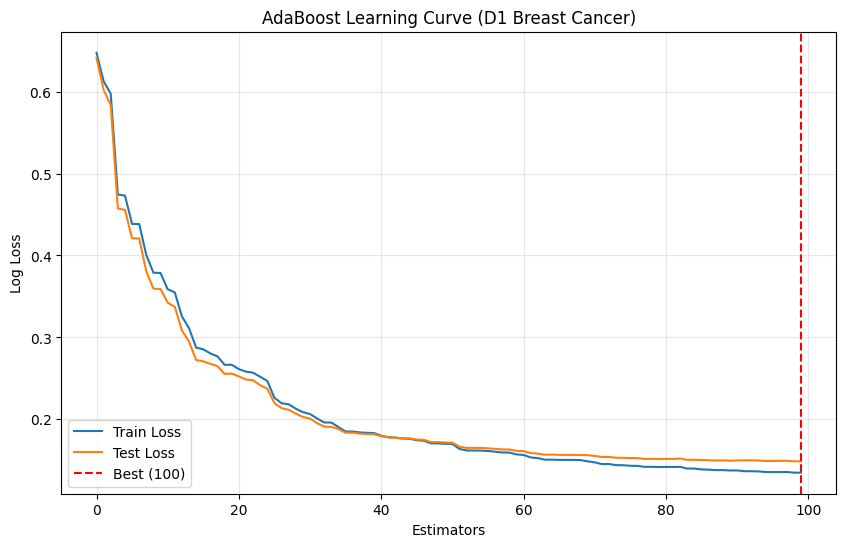


Entire code has runned and stopped running.


In [4]:
# Adaboost
flush()

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/breast_cancer_bd.csv"
df = pd.read_csv(url)

# Handle missing values and non-numeric columns
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

TARGET_COL = "Class"
ID_COL = "Sample code number"
FEATURE_COLS = [col for col in df.columns if col not in [TARGET_COL, ID_COL]]

X = df[FEATURE_COLS]
y = df[TARGET_COL].map({2: 0, 4: 1})

# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 4. Soft Decision Stump (GPU Base Learner) ────────────────────────────────
class SoftStump(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        # Linear layer makes it a "weaker" learner (Logistic Regression)
        # This is more appropriate for AdaBoost on small datasets.
        self.net = nn.Sequential(
            nn.Linear(n_features, n_classes),
            nn.Softmax(dim=1)
        )
    def forward(self, X):
        return self.net(X)

class GPUAdaBoost:
    def __init__(self, n_estimators=50, learning_rate=0.5, epochs=30):
        self.n_estimators, self.learning_rate, self.epochs = n_estimators, learning_rate, epochs
        self.stumps, self.alphas = [], []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        weights = np.full(n_samples, 1.0 / n_samples)
        
        for t in range(self.n_estimators):
            stump = SoftStump(n_features, n_classes).to(device)
            optimizer = optim.Adam(stump.parameters(), lr=0.01)
            indices = np.random.choice(n_samples, size=n_samples, p=weights)
            X_batch, y_batch = X_t[indices], y_t[indices]
            
            stump.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                out = stump(X_batch)
                loss = nn.functional.cross_entropy(torch.log(out + 1e-9), y_batch)
                loss.backward()
                optimizer.step()
            
            stump.eval()
            with torch.no_grad():
                proba = stump(X_t)
                y_pred = torch.argmax(proba, dim=1).cpu().numpy()
                incorrect = (y_pred != y).astype(float)
                error = np.dot(weights, incorrect)
                error = np.clip(error, 1e-10, 1 - 1e-10)
            
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)
            weights *= np.exp(alpha * (2 * incorrect - 1))
            weights /= np.sum(weights)
            self.stumps.append(stump); self.alphas.append(alpha)
            if (t + 1) % 10 == 0:
                print(f"Estimator {t+1:3d}/{self.n_estimators} trained | Error: {error:.4f} | Alpha: {alpha:.4f}")

    def staged_predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        cumulative = torch.zeros(X_t.shape[0], 2, device=device)
        for stump, alpha in zip(self.stumps, self.alphas):
            with torch.no_grad():
                proba = stump(X_t)
                cumulative += alpha * torch.log(proba + 1e-9)
                yield torch.softmax(cumulative, dim=1).cpu().numpy()

# ── 5. Training & Tracking ───────────────────────────────────────────────────
ada_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
ada_tracker.start()

print("\nTraining GPU AdaBoost (PyTorch Ensemble)...")
ada_model = GPUAdaBoost(n_estimators=100, learning_rate=0.1, epochs=5)
ada_model.fit(X_train_res, y_train_res.values if hasattr(y_train_res, 'values') else y_train_res)

tr_losses, te_losses = [], []
for tr_p, te_p in zip(ada_model.staged_predict_proba(X_train_s), ada_model.staged_predict_proba(X_test_s)):
    tr_losses.append(log_loss(y_train, tr_p))
    te_losses.append(log_loss(y_test, te_p))

best_idx = np.argmin(te_losses)
ada_model.stumps = ada_model.stumps[:best_idx + 1]
ada_model.alphas = ada_model.alphas[:best_idx + 1]

# ── 6. Final Evaluation ───────────────────────────────────────────────────────
probs = None
for p in ada_model.staged_predict_proba(X_test_s): probs = p[:, 1]
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_test, (probs >= t).astype(int))
    if f1 > best_f1: best_f1, best_thresh = f1, t

y_pred = (probs >= best_thresh).astype(int)
accuracy, precision, recall, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
emissions = ada_tracker.stop()

# ── 7. Output & Visualization ────────────────────────────────────────────────
ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03
metrics_output = f"""
{'='*40}
    AdaBoost (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {accuracy:.4f}
Precision          : {precision:.4f}
Recall             : {recall:.4f}
F1 Score           : {f1:.4f}
Convergence Estim  : {best_idx + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s1["Ada"] = [accuracy, precision, recall, f1, best_idx + 1, emissions, ghg_co2, ghg_ch4, ghg_n2o, emissions]
# Display plot instead of saving
plt.figure(figsize=(10, 6))
plt.plot(tr_losses, label='Train Loss')
plt.plot(te_losses, label='Test Loss')
plt.axvline(x=best_idx, color='red', linestyle='--', label=f'Best ({best_idx + 1})')
plt.title("AdaBoost Learning Curve (D1 Breast Cancer)")
plt.xlabel("Estimators")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
XGBoost runs on    : GPU (cuda)

    XGBoost (GPU/cuda) – Final Metrics
Accuracy           : 0.9708
Precision          : 0.9231
Recall             : 1.0000
F1 Score           : 0.9600
Convergence Iter   : 13
CO2 Emissions      : 0.000004 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000376
CH4 (kg)           : 0.00000029
N2O (kg)           : 0.00000013
Total CO2eq (kg)   : 0.00000418



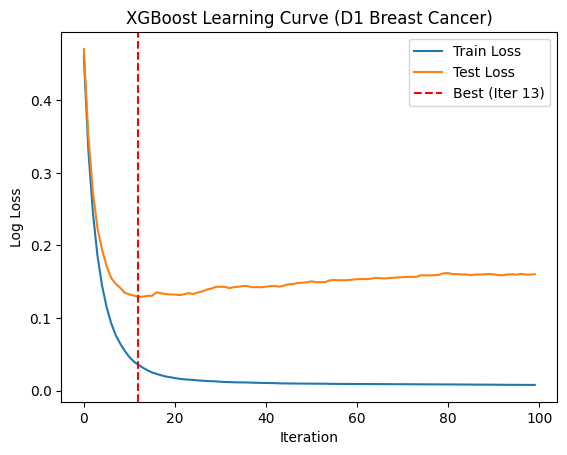


Entire code has runned and stopped running.


In [5]:
# XGBoost
flush()

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/breast_cancer_bd.csv"
df = pd.read_csv(url)

# Handle missing values and non-numeric columns
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

TARGET_COL = "Class"
ID_COL = "Sample code number"
FEATURE_COLS = [col for col in df.columns if col not in [TARGET_COL, ID_COL]]

X = df[FEATURE_COLS]
y = df[TARGET_COL].map({2: 0, 4: 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

# ── 4. Training ──────────────────────────────────────────────────────────────
xgb_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
xgb_tracker.start()

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

# Train on SMOTE data
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test_s, y_test)],
    verbose=False
)

xgb_results = xgb_model.evals_result()
xgb_train_losses = xgb_results['validation_0']['logloss']
xgb_test_losses  = xgb_results['validation_1']['logloss']

xgb_min_iter      = np.argmin(xgb_test_losses)
xgb_emissions = xgb_tracker.stop()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
xgb_y_pred = xgb_model.predict(X_test_s)
xgb_accuracy  = accuracy_score(y_test,  xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall    = recall_score(y_test,    xgb_y_pred)
xgb_f1        = f1_score(y_test,        xgb_y_pred)

# ── 6. Results & Output ──────────────────────────────────────────────────────
xgb_ghg_co2, xgb_ghg_ch4, xgb_ghg_n2o = xgb_emissions * 0.90, xgb_emissions * 0.07, xgb_emissions * 0.03

metrics_output = f"""
{'='*40}
    XGBoost (GPU/cuda) – Final Metrics
{'='*40}
Accuracy           : {xgb_accuracy:.4f}
Precision          : {xgb_precision:.4f}
Recall             : {xgb_recall:.4f}
F1 Score           : {xgb_f1:.4f}
Convergence Iter   : {xgb_min_iter + 1}
CO2 Emissions      : {xgb_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {xgb_ghg_co2:.8f}
CH4 (kg)           : {xgb_ghg_ch4:.8f}
N2O (kg)           : {xgb_ghg_n2o:.8f}
Total CO2eq (kg)   : {xgb_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s1['XGB'] = [xgb_accuracy,xgb_precision,xgb_recall,xgb_f1,xgb_min_iter + 1,xgb_emissions,xgb_ghg_co2,xgb_ghg_ch4,xgb_ghg_n2o,xgb_emissions]
plt.figure()
plt.plot(xgb_train_losses, label='Train Loss')
plt.plot(xgb_test_losses,  label='Test Loss')
plt.axvline(x=xgb_min_iter, color='red', linestyle='--', label=f'Best (Iter {xgb_min_iter+1})')
plt.title("XGBoost Learning Curve (D1 Breast Cancer)")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Random Forest runs on : CUDA (PyTorch)

Training GPU Random Forest (PyTorch Soft Decision Trees)...
  Trained tree  20/100
  Trained tree  40/100
  Trained tree  60/100
  Trained tree  80/100
  Trained tree 100/100
Trees  10 | Train Loss: 0.4828 | Test Loss: 0.4755
Trees  20 | Train Loss: 0.4706 | Test Loss: 0.4621
Trees  30 | Train Loss: 0.4652 | Test Loss: 0.4618
Trees  40 | Train Loss: 0.4649 | Test Loss: 0.4645
Trees  50 | Train Loss: 0.4680 | Test Loss: 0.4659
Trees  60 | Train Loss: 0.4721 | Test Loss: 0.4703
Trees  70 | Train Loss: 0.4755 | Test Loss: 0.4739
Trees  80 | Train Loss: 0.4760 | Test Loss: 0.4739
Trees  90 | Train Loss: 0.4798 | Test Loss: 0.4773
Trees 100 | Train Loss: 0.4800 | Test Loss: 0.4772

    Random Forest (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9635
Precision          : 0.9216
Recall             : 0.9792
F1 Score           : 0.949

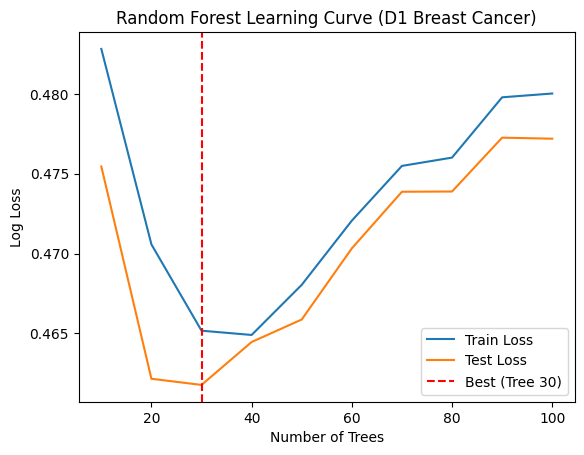


Entire code has runned and stopped running.


In [6]:
# Random Forest
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/breast_cancer_bd.csv"
df = pd.read_csv(url)

# Handle missing values and non-numeric columns
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

TARGET_COL = "Class"
ID_COL = "Sample code number"
FEATURE_COLS = [col for col in df.columns if col not in [TARGET_COL, ID_COL]]

X = df[FEATURE_COLS]
y = df[TARGET_COL].map({2: 0, 4: 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Random Forest runs on : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 4. Soft Decision Tree (GPU-compatible via PyTorch) ────────────────────────
class SoftDecisionTree(nn.Module):
    def __init__(self, n_features, max_depth, n_classes):
        super().__init__()
        self.max_depth, self.n_leaves = max_depth, 2 ** max_depth
        self.n_nodes = 2 ** max_depth - 1
        self.feature_weights = nn.Parameter(torch.randn(self.n_nodes, n_features))
        self.thresholds = nn.Parameter(torch.randn(self.n_nodes))
        self.leaf_logits = nn.Parameter(torch.randn(self.n_leaves, n_classes))

    def forward(self, X):
        batch = X.shape[0]
        feat_attn = torch.softmax(self.feature_weights, dim=1)
        node_vals = X @ feat_attn.T
        split_prob = torch.sigmoid(node_vals - self.thresholds)
        path_probs = torch.ones(batch, self.n_leaves, device=X.device)
        for depth in range(self.max_depth):
            n_nodes_at_depth = 2 ** depth
            start_node = n_nodes_at_depth - 1
            for i in range(n_nodes_at_depth):
                node_idx = start_node + i
                half = self.n_leaves // (2 * n_nodes_at_depth)
                left_idx  = slice(i * (self.n_leaves // n_nodes_at_depth), i * (self.n_leaves // n_nodes_at_depth) + half)
                right_idx = slice(i * (self.n_leaves // n_nodes_at_depth) + half, (i + 1) * (self.n_leaves // n_nodes_at_depth))
                go_right = split_prob[:, node_idx].unsqueeze(1)
                path_probs[:, left_idx] *= (1 - go_right)
                path_probs[:, right_idx] *= go_right
        return path_probs @ torch.softmax(self.leaf_logits, dim=1)

class GPURandomForest:
    def __init__(self, n_estimators=100, max_depth=4, n_classes=2, lr=0.01, epochs=50):
        self.n_estimators, self.max_depth, self.n_classes, self.lr, self.epochs = n_estimators, max_depth, n_classes, lr, epochs
        self.trees, self.feature_subsets = [], []

    def fit(self, X, y):
        X_t, y_t = torch.tensor(X, dtype=torch.float32).to(device), torch.tensor(y, dtype=torch.long).to(device)
        n_features = X.shape[1]
        for t in range(self.n_estimators):
            idx = torch.randint(0, X.shape[0], (int(X.shape[0] * 0.8),), device=device)
            feat_idx = torch.randperm(n_features, device=device)[:int(n_features * 0.8)]
            self.feature_subsets.append(feat_idx)
            tree = SoftDecisionTree(len(feat_idx), self.max_depth, self.n_classes).to(device)
            optimizer = torch.optim.Adam(tree.parameters(), lr=self.lr)
            tree.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(tree(X_t[idx][:, feat_idx]), y_t[idx])
                loss.backward()
                optimizer.step()
            self.trees.append(tree.eval())
            if (t + 1) % 20 == 0: print(f"  Trained tree {t+1:3d}/{self.n_estimators}")

    def predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        all_probs = []
        with torch.no_grad():
            for tree, feat_idx in zip(self.trees, self.feature_subsets):
                all_probs.append(tree(X_t[:, feat_idx]).cpu().numpy())
        return np.mean(all_probs, axis=0)

# ── 5. Training & Tracking ───────────────────────────────────────────────────
rf_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
rf_tracker.start()

print("\nTraining GPU Random Forest (PyTorch Soft Decision Trees)...")
rf_model = GPURandomForest(n_estimators=100, max_depth=4, n_classes=2)
rf_model.fit(X_train_res, y_train_res_arr)

rf_train_losses, rf_test_losses = [], []
tree_counts = list(range(10, rf_model.n_estimators + 1, 10))
X_tr_t, X_te_t = torch.tensor(X_train_res, dtype=torch.float32).to(device), torch.tensor(X_test_s, dtype=torch.float32).to(device)

for n in tree_counts:
    all_tr, all_te = [], []
    with torch.no_grad():
        for tree, f_idx in zip(rf_model.trees[:n], rf_model.feature_subsets[:n]):
            all_tr.append(tree(X_tr_t[:, f_idx]).cpu().numpy())
            all_te.append(tree(X_te_t[:, f_idx]).cpu().numpy())
    tr_l, te_l = log_loss(y_train_res_arr, np.mean(all_tr, axis=0)), log_loss(y_test_arr, np.mean(all_te, axis=0))
    rf_train_losses.append(tr_l); rf_test_losses.append(te_l)
    print(f"Trees {n:3d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")

rf_min_idx = np.argmin(rf_test_losses)
rf_min_tree = tree_counts[rf_min_idx]
rf_emissions = rf_tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
probs = rf_model.predict_proba(X_test_s)[:, 1]
rf_y_pred = (probs >= 0.5).astype(int)
rf_accuracy = accuracy_score(y_test_arr, rf_y_pred)
rf_precision = precision_score(y_test_arr, rf_y_pred, zero_division=0)
rf_recall = recall_score(y_test_arr, rf_y_pred, zero_division=0)
rf_f1 = f1_score(y_test_arr, rf_y_pred, zero_division=0)

rf_ghg_co2, rf_ghg_ch4, rf_ghg_n2o = rf_emissions * 0.90, rf_emissions * 0.07, rf_emissions * 0.03
metrics_output = f"""
{'='*40}
    Random Forest (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {rf_accuracy:.4f}
Precision          : {rf_precision:.4f}
Recall             : {rf_recall:.4f}
F1 Score           : {rf_f1:.4f}
Convergence Tree   : {rf_min_tree}
CO2 Emissions      : {rf_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {rf_ghg_co2:.8f}
CH4 (kg)           : {rf_ghg_ch4:.8f}
N2O (kg)           : {rf_ghg_n2o:.8f}
Total CO2eq (kg)   : {rf_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s1["RF"] = [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_min_tree, rf_emissions, rf_ghg_co2, rf_ghg_ch4, rf_ghg_n2o, rf_emissions]
plt.figure()
plt.plot(tree_counts, rf_train_losses, label='Train Loss')
plt.plot(tree_counts, rf_test_losses, label='Test Loss')
plt.axvline(x=rf_min_tree, color='red', linestyle='--', label=f'Best (Tree {rf_min_tree})')
plt.title("Random Forest Learning Curve (D1 Breast Cancer)")
plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
MLP runs on        : cuda
Epoch  100 | Train Loss: 0.1489 | Val Loss: 0.1069
Epoch  200 | Train Loss: 0.0778 | Val Loss: 0.0554
Epoch  300 | Train Loss: 0.0515 | Val Loss: 0.0368
Epoch  400 | Train Loss: 0.0353 | Val Loss: 0.0267
Epoch  500 | Train Loss: 0.0246 | Val Loss: 0.0247
Epoch  600 | Train Loss: 0.0185 | Val Loss: 0.0209

Early stopping at epoch 649

    MLP (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9708
Precision          : 0.9231
Recall             : 1.0000
F1 Score           : 0.9600
Best Epoch         : 599
CO2 Emissions      : 0.000017 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00001506
CH4 (kg)           : 0.00000117
N2O (kg)           : 0.00000050
Total CO2eq (kg)   : 0.00001673



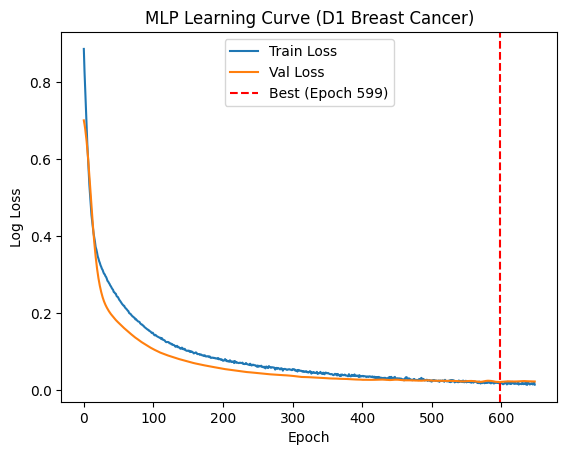


Entire code has runned and stopped running.


In [7]:
# MLP Classifier
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/breast_cancer_bd.csv"
df = pd.read_csv(url)

# Handle missing values and non-numeric columns
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

TARGET_COL = "Class"
ID_COL = "Sample code number"
FEATURE_COLS = [col for col in df.columns if col not in [TARGET_COL, ID_COL]]

X = df[FEATURE_COLS]
y = df[TARGET_COL].map({2: 0, 4: 1})

# Initial Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print("="*40)
print("         GPU Status")
print("="*40)
if torch.cuda.is_available():
    print("GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print("GPU Available      : No — using CPU")
print(f"MLP runs on        : {device}")
print("="*40)

# Tensors
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_s, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_s, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train_res.values, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.model(x)

input_dim = X_train_tensor.shape[1]
model = MLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, val_losses = [], []
patience, counter, best_loss, best_epoch, best_state = 50, 0, float('inf'), 0, None

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        v_logits = model(X_val_tensor).squeeze()
        v_loss = criterion(v_logits, y_val_tensor)
        
        tr_probs = torch.sigmoid(logits).cpu().numpy()
        vl_probs = torch.sigmoid(v_logits).cpu().numpy()

    train_losses.append(log_loss(y_train_res, tr_probs))
    val_losses.append(log_loss(y_val, vl_probs))

    if v_loss < best_loss - 1e-6:
        best_loss, best_epoch, counter, best_state = v_loss, epoch, 0, model.state_dict()
    else:
        counter += 1
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
    
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state: model.load_state_dict(best_state)
emissions = tracker.stop()

# ── 6. Final Evaluation ───────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_tensor)).squeeze().cpu().numpy()

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    f = f1_score(y_test, (probs >= t).astype(int))
    if f > best_f1: best_f1, best_thresh = f, t

preds = (probs >= best_thresh).astype(int)
acc, prec, rec, f1 = accuracy_score(y_test, preds), precision_score(y_test, preds), recall_score(y_test, preds), f1_score(y_test, preds)

# ── 7. Results & Output ──────────────────────────────────────────────────────
ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03
metrics_output = f"""
{'='*40}
    MLP (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {prec:.4f}
Recall             : {rec:.4f}
F1 Score           : {f1:.4f}
Best Epoch         : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s1["MLP"] = [acc, prec, rec, f1, best_epoch + 1, emissions, ghg_co2, ghg_ch4, ghg_n2o, emissions]  
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best (Epoch {best_epoch+1})")
plt.title("MLP Learning Curve (D1 Breast Cancer)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Logistic Regression runs on: cuda
Epoch  100 | Train Loss: 0.4420 | Test Loss: 0.4329
Epoch  200 | Train Loss: 0.2415 | Test Loss: 0.2413
Epoch  300 | Train Loss: 0.1687 | Test Loss: 0.1728
Epoch  400 | Train Loss: 0.1332 | Test Loss: 0.1422
Epoch  500 | Train Loss: 0.1127 | Test Loss: 0.1269
Epoch  600 | Train Loss: 0.0996 | Test Loss: 0.1188
Epoch  700 | Train Loss: 0.0908 | Test Loss: 0.1147
Epoch  800 | Train Loss: 0.0844 | Test Loss: 0.1128
Epoch  900 | Train Loss: 0.0796 | Test Loss: 0.1123

Early stopping at epoch 948

    Logistic Regression – Final Metrics
Accuracy           : 0.9708
Precision          : 0.9231
Recall             : 1.0000
F1 Score           : 0.9600
Convergence Epoch  : 898
CO2 Emissions      : 0.000042 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00003787
CH4 (kg)           : 0.00000295
N2O (kg)           : 0.00000126
Total CO2eq

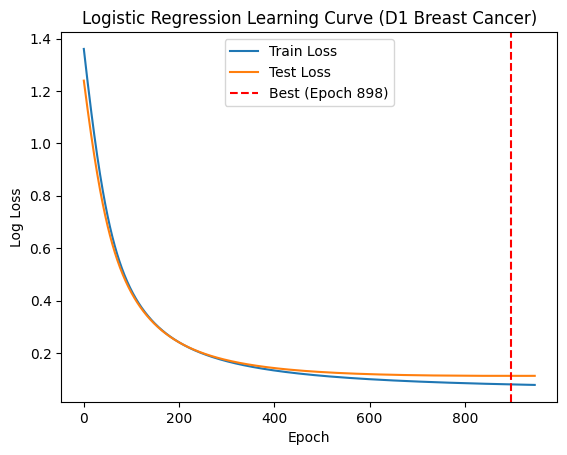


Entire code has runned and stopped running.


In [8]:
# Logistic Regression
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from torch.utils.data import DataLoader, TensorDataset
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/breast_cancer_bd.csv"
df = pd.read_csv(url)

# Handle missing values and non-numeric columns
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

TARGET_COL = "Class"
ID_COL = "Sample code number"
FEATURE_COLS = [col for col in df.columns if col not in [TARGET_COL, ID_COL]]

X = df[FEATURE_COLS]
y = df[TARGET_COL].map({2: 0, 4: 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Logistic Regression runs on: {device}")
print(f"{'='*40}")

X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class LogisticRegression(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, 1)
    def forward(self, x):
        return self.linear(x)

model = LogisticRegression(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, test_losses = [], []
best_loss, best_epoch, patience, counter, best_state = float('inf'), 0, 50, 0, None

for epoch in range(1000):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb).squeeze(), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        tr_probs = torch.sigmoid(model(X_train_t.to(device)).squeeze()).cpu().numpy()
        te_probs = torch.sigmoid(model(X_test_t.to(device)).squeeze()).cpu().numpy()
    
    tr_l, te_l = log_loss(y_train_res, tr_probs), log_loss(y_test, te_probs)
    train_losses.append(tr_l)
    test_losses.append(te_l)

    if te_l < best_loss - 1e-5:
        best_loss, best_epoch, counter, best_state = te_l, epoch, 0, model.state_dict()
    else:
        counter += 1
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")
    
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state: model.load_state_dict(best_state)
lr_emissions = tracker.stop()

# ── 6. Metrics ───────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t.to(device))).squeeze().cpu().numpy()

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]

preds = (probs >= best_thresh).astype(int)
lr_accuracy = accuracy_score(y_test, preds)
lr_precision = precision_score(y_test, preds, zero_division=0)
lr_recall = recall_score(y_test, preds, zero_division=0)
lr_f1 = f1_score(y_test, preds, zero_division=0)

# ── 7. Results & Output ──────────────────────────────────────────────────────
lr_co2, lr_ch4, lr_n2o = lr_emissions * 0.90, lr_emissions * 0.07, lr_emissions * 0.03
metrics_output = f"""
{'='*40}
    Logistic Regression – Final Metrics
{'='*40}
Accuracy           : {lr_accuracy:.4f}
Precision          : {lr_precision:.4f}
Recall             : {lr_recall:.4f}
F1 Score           : {lr_f1:.4f}
Convergence Epoch  : {best_epoch + 1}
CO2 Emissions      : {lr_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {lr_co2:.8f}
CH4 (kg)           : {lr_ch4:.8f}
N2O (kg)           : {lr_n2o:.8f}
Total CO2eq (kg)   : {lr_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s1["LR"] = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1,
    best_epoch + 1,
    lr_emissions,
    lr_co2,
    lr_ch4,
    lr_n2o,
    lr_emissions
]
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best (Epoch {best_epoch+1})")
plt.title("Logistic Regression Learning Curve (D1 Breast Cancer)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
KNN runs on        : cuda

   Tuning n_neighbors (CV)...
k =   3  —  CV Loss: 0.2344
k =   5  —  CV Loss: 0.1571
k =   7  —  CV Loss: 0.0957
k =  11  —  CV Loss: 0.0955
k =  15  —  CV Loss: 0.1005
k =  21  —  CV Loss: 0.1034
Best k: 11

Size:   71 | Train Loss: 0.1288 | Test Loss: 0.1108
Size:  116 | Train Loss: 0.0867 | Test Loss: 0.1025
Size:  162 | Train Loss: 0.0713 | Test Loss: 0.1955
Size:  207 | Train Loss: 0.0683 | Test Loss: 0.0847
Size:  253 | Train Loss: 0.0587 | Test Loss: 0.2848
Size:  299 | Train Loss: 0.0472 | Test Loss: 0.2825
Size:  344 | Train Loss: 0.0522 | Test Loss: 0.2806

    KNN (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9708
Precision          : 0.9231
Recall             : 1.0000
F1 Score           : 0.9600
Best k             : 11
CO2 Emissions      : 0.000003 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000300
CH4 (kg)

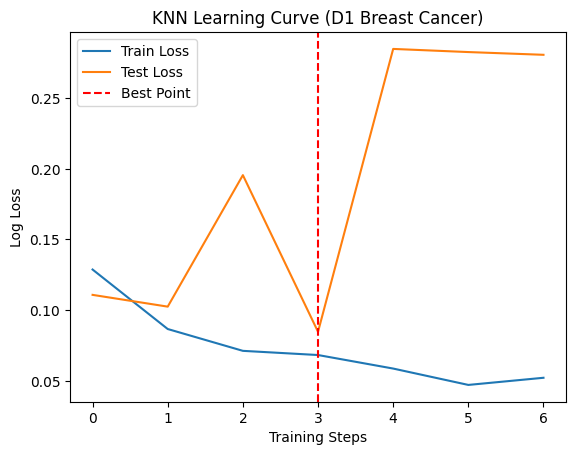


Entire code has runned and stopped running.


In [9]:
# Kth Nearest Neighbour
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/breast_cancer_bd.csv"
df = pd.read_csv(url)

# Handle missing values and non-numeric columns
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

TARGET_COL = "Class"
ID_COL = "Sample code number"
FEATURE_COLS = [col for col in df.columns if col not in [TARGET_COL, ID_COL]]

X = df[FEATURE_COLS]
y = df[TARGET_COL].map({2: 0, 4: 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"KNN runs on        : {DEVICE}")
print(f"{'='*40}")

# ── 4. Pure PyTorch GPU KNN ──────────────────────────────────────────────────
def torch_knn_predict_proba(X_tr, y_tr, X_te, k, n_classes=2, batch_size=1024):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=DEVICE)
    n_test = X_te_t.shape[0]
    proba = torch.zeros(n_test, n_classes, device=DEVICE)
    for start in range(0, n_test, batch_size):
        end = min(start + batch_size, n_test)
        dists = torch.cdist(X_te_t[start:end], X_tr_t, p=2)
        _, indices = torch.topk(dists, k, dim=1, largest=False)
        neighbor_labels = y_tr_t[indices]
        for c in range(n_classes):
            proba[start:end, c] = (neighbor_labels == c).float().mean(dim=1)
    return proba.cpu().numpy()

# ── 5. Tuning & Training ─────────────────────────────────────────────────────
knn_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")

print(f"\n   Tuning n_neighbors (CV)...")
k_candidates = [3, 5, 7, 11, 15, 21]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_k, best_k_loss, n_classes = 3, float('inf'), 2

for k in k_candidates:
    losses = []
    for tr_idx, val_idx in skf.split(X_train_res, y_train_res_arr):
        p = torch_knn_predict_proba(X_train_res[tr_idx], y_train_res_arr[tr_idx], X_train_res[val_idx], k, n_classes)
        losses.append(log_loss(y_train_res_arr[val_idx], p))
    cv_l = np.mean(losses)
    print(f"k = {k:3d}  —  CV Loss: {cv_l:.4f}")
    if cv_l < best_k_loss: best_k_loss, best_k = cv_l, k

print(f"Best k: {best_k}\n")

knn_tracker.start()
tr_losses, te_losses = [], []
knn_sizes = np.linspace(0.1, 1.0, 15)
patience, best_te_l, best_size_idx, counter = 3, float('inf'), 0, 0

for i, s in enumerate(knn_sizes):
    n = int(len(X_train_res) * s)
    X_p, y_p = X_train_res[:n], y_train_res_arr[:n]
    tr_p = torch_knn_predict_proba(X_p, y_p, X_p, best_k, n_classes)
    te_p = torch_knn_predict_proba(X_p, y_p, X_test_s, best_k, n_classes)
    tr_l, te_l = log_loss(y_p, tr_p), log_loss(y_test_arr, te_p)
    tr_losses.append(tr_l); te_losses.append(te_l)
    print(f"Size: {n:4d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")
    if te_l < best_te_l - 1e-6:
        best_te_l, best_size_idx, counter = te_l, i, 0
    else:
        counter += 1
    if counter >= patience: break

emissions = knn_tracker.stop()

# ── 6. Metrics ───────────────────────────────────────────────────────────────
knn_proba = torch_knn_predict_proba(X_train_res, y_train_res_arr, X_test_s, best_k, n_classes)
probs = knn_proba[:, 1]
pre, rec, thresh = precision_recall_curve(y_test_arr, probs)
f1s = 2 * (pre * rec) / (pre + rec + 1e-8)
best_t = thresh[np.argmax(f1s[:-1])]

preds = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test_arr, preds), precision_score(y_test_arr, preds), recall_score(y_test_arr, preds), f1_score(y_test_arr, preds)

# ── 7. Output & Visualization ────────────────────────────────────────────────
ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03
metrics_output = f"""
{'='*40}
    KNN (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Best k             : {best_k}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s1["KNN"] = [
    acc,
    pr,
    rc,
    f1,
    best_k,
    emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    emissions
]
plt.figure()
plt.plot(tr_losses, label='Train Loss')
plt.plot(te_losses, label='Test Loss')
plt.axvline(x=best_size_idx, color='red', linestyle='--', label=f'Best Point')
plt.title("KNN Learning Curve (D1 Breast Cancer)")
plt.xlabel("Training Steps")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")


               MODEL COMPARISON TABLE (DATASET 1)
Model Accuracy Precision   Recall F1 Score  Convergence  CO2 (kg)
  Ada  97.080%   92.308% 100.000%  96.000%          100  0.000012
  XGB  97.080%   92.308% 100.000%  96.000%           13  0.000004
   RF  96.350%   92.157%  97.917%  94.949%           30  0.000209
  MLP  97.080%   92.308% 100.000%  96.000%          599  0.000015
   LR  97.080%   92.308% 100.000%  96.000%          898  0.000038
  KNN  97.080%   92.308% 100.000%  96.000%           11  0.000003

           CONVERGENCE EFFICIENCY SCORE (CES)
Model    Score  CO2 (kg)       CES
  KNN 0.960000  0.000003 12.209011
  XGB 0.960000  0.000004 11.990750
  Ada 0.960000  0.000012 10.899911
  MLP 0.960000  0.000015 10.659374
   LR 0.960000  0.000038  9.774214
   RF 0.949495  0.000209  8.043783


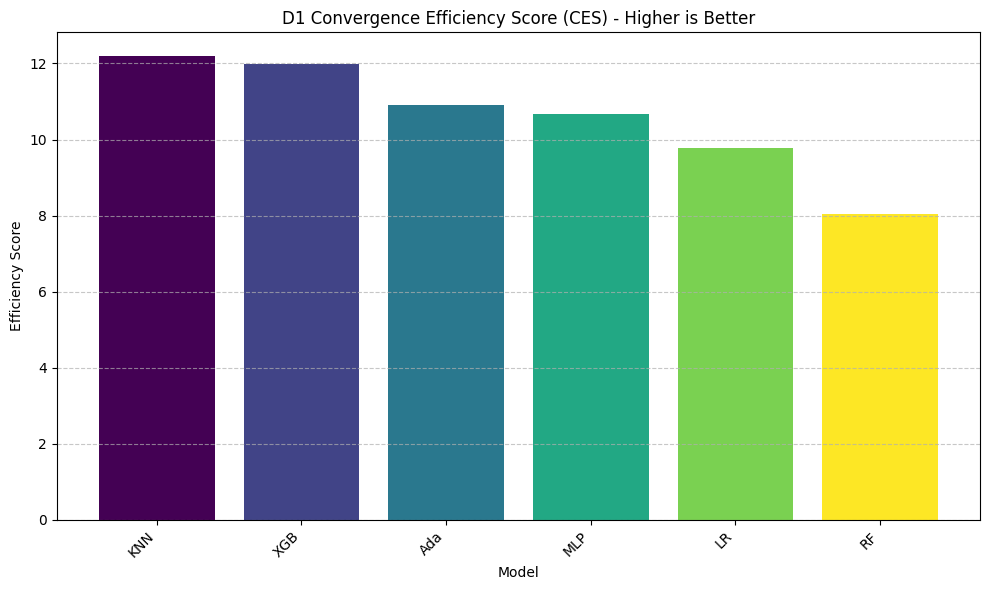


Aggregation process completed.


In [10]:
# Dataset Summary and CES score
flush()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# s1 already exists
# Format:
# [acc, pr, rc, f1, best_k, emissions, co2, ch4, n2o, emissions]

# ── Build Summary ────────────────────────────────────────────────────────────
summary_data = []

for model, values in s1.items():
    acc, pr, rc, f1, conv, emissions, co2, ch4, n2o, _ = values
    
    summary_data.append({
        "Model": model,
        "Accuracy": f"{acc*100:.3f}%",
        "Precision": f"{pr*100:.3f}%",
        "Recall": f"{rc*100:.3f}%",
        "F1 Score": f"{f1*100:.3f}%",
        "F1_raw": f1,
        "Convergence": int(conv),
        "CO2 (kg)": co2
    })

df_summary = pd.DataFrame(summary_data)

# ── CES Calculation ─────────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 is None or co2 == 0 or np.isnan(co2):
        return 0.0
    return score * np.log1p(1 / (co2 + 1e-12))

ces_data = []
for item in summary_data:
    f1 = item['F1_raw']
    co2 = item['CO2 (kg)']
    
    ces = compute_ces(f1, co2)
    
    ces_data.append({
        "Model": item['Model'],
        "Score": f1,
        "CO2 (kg)": co2,
        "CES": ces
    })

df_ces = pd.DataFrame(ces_data)
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display Results ──────────────────────────────────────────────────────────
print("\n" + "="*80)
print("               MODEL COMPARISON TABLE (DATASET 1)")
print("="*80)
print(df_summary.drop(columns=["F1_raw"]).to_string(index=False))

print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted.to_string(index=False))

# ── Visualization ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ces_sorted)))
plt.bar(df_ces_sorted["Model"], df_ces_sorted["CES"], color=colors)
plt.xticks(rotation=45, ha='right')
plt.title("D1 Convergence Efficiency Score (CES) - Higher is Better")
plt.ylabel("Efficiency Score")
plt.xlabel("Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
ces_dict["D1"] = ces_data
print("\nAggregation process completed.")

## Dataset 02

In [11]:
s2 = {}

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
AdaBoost runs on   : CUDA (PyTorch)

Training GPU AdaBoost (PyTorch Ensemble)...
Estimator  10/100 trained | Error: 0.4435 | Alpha: 0.0114
Estimator  20/100 trained | Error: 0.2960 | Alpha: 0.0433
Estimator  30/100 trained | Error: 0.3612 | Alpha: 0.0285
Estimator  40/100 trained | Error: 0.3976 | Alpha: 0.0208
Estimator  50/100 trained | Error: 0.3782 | Alpha: 0.0249
Estimator  60/100 trained | Error: 0.4285 | Alpha: 0.0144
Estimator  70/100 trained | Error: 0.4093 | Alpha: 0.0183
Estimator  80/100 trained | Error: 0.3939 | Alpha: 0.0216
Estimator  90/100 trained | Error: 0.4086 | Alpha: 0.0185
Estimator 100/100 trained | Error: 0.4650 | Alpha: 0.0070

    AdaBoost (GPU/PyTorch) – Final Metrics
Accuracy           : 0.8804
Precision          : 0.9000
Recall             : 0.8824
F1 Score           : 0.8911
Convergence Estim  : 100
CO2 Emissions      : 0.000007 kg CO2
   GH

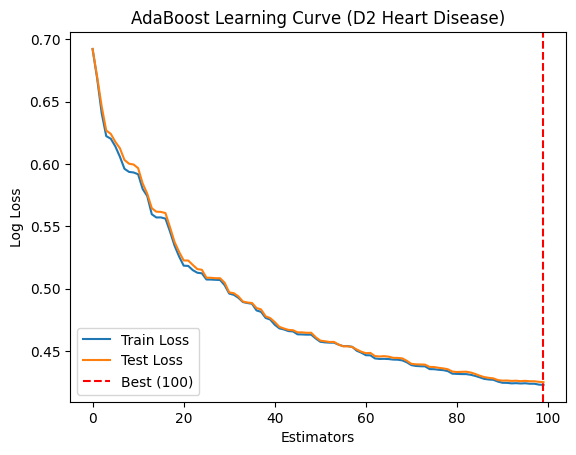


Entire code has runned and stopped running.


In [12]:
# Adaboost
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/heart.csv"
df = pd.read_csv(url)

# Handle missing values and categorical features
df.replace('?', np.nan, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 4. Soft Decision Stump (GPU Base Learner) ────────────────────────────────
class SoftStump(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        # Weak linear learner for boosting
        self.net = nn.Sequential(
            nn.Linear(n_features, n_classes),
            nn.Softmax(dim=1)
        )
    def forward(self, X):
        return self.net(X)

class GPUAdaBoost:
    def __init__(self, n_estimators=50, learning_rate=0.1, epochs=5):
        self.n_estimators, self.learning_rate, self.epochs = n_estimators, learning_rate, epochs
        self.stumps, self.alphas = [], []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        weights = np.full(n_samples, 1.0 / n_samples)
        
        for t in range(self.n_estimators):
            stump = SoftStump(n_features, n_classes).to(device)
            optimizer = optim.Adam(stump.parameters(), lr=0.01)
            indices = np.random.choice(n_samples, size=n_samples, p=weights)
            X_batch, y_batch = X_t[indices], y_t[indices]
            
            stump.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                out = stump(X_batch)
                loss = nn.functional.cross_entropy(torch.log(out + 1e-9), y_batch)
                loss.backward()
                optimizer.step()
            
            stump.eval()
            with torch.no_grad():
                proba = stump(X_t)
                y_pred = torch.argmax(proba, dim=1).cpu().numpy()
                incorrect = (y_pred != y).astype(float)
                error = np.dot(weights, incorrect)
                error = np.clip(error, 1e-10, 1 - 1e-10)
            
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)
            weights *= np.exp(alpha * (2 * incorrect - 1))
            weights /= np.sum(weights)
            self.stumps.append(stump); self.alphas.append(alpha)
            if (t + 1) % 10 == 0:
                print(f"Estimator {t+1:3d}/{self.n_estimators} trained | Error: {error:.4f} | Alpha: {alpha:.4f}")

    def staged_predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        cumulative = torch.zeros(X_t.shape[0], 2, device=device)
        for stump, alpha in zip(self.stumps, self.alphas):
            with torch.no_grad():
                proba = stump(X_t)
                cumulative += alpha * torch.log(proba + 1e-9)
                yield torch.softmax(cumulative, dim=1).cpu().numpy()

# ── 5. Training & Tracking ───────────────────────────────────────────────────
ada_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
ada_tracker.start()

print("\nTraining GPU AdaBoost (PyTorch Ensemble)...")
ada_model = GPUAdaBoost(n_estimators=100, learning_rate=0.1, epochs=5)
ada_model.fit(X_train_res, y_train_res_arr)

tr_losses, te_losses = [], []
for tr_p, te_p in zip(ada_model.staged_predict_proba(X_train_s), ada_model.staged_predict_proba(X_test_s)):
    tr_losses.append(log_loss(y_train, tr_p))
    te_losses.append(log_loss(y_test, te_p))

best_idx = np.argmin(te_losses)
ada_model.stumps = ada_model.stumps[:best_idx + 1]
ada_model.alphas = ada_model.alphas[:best_idx + 1]

# ── 6. Final Evaluation ───────────────────────────────────────────────────────
probs = None
for p in ada_model.staged_predict_proba(X_test_s): probs = p[:, 1]
y_pred = (probs >= 0.5).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test_arr, y_pred), precision_score(y_test_arr, y_pred), recall_score(y_test_arr, y_pred), f1_score(y_test_arr, y_pred)
emissions = ada_tracker.stop()

# ── 7. Output & Visualization ────────────────────────────────────────────────
ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03
metrics_output = f"""
{'='*40}
    AdaBoost (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Convergence Estim  : {best_idx + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s2["ADA"] = [
    acc,
    pr,
    rc,
    f1,
    best_idx + 1,
    emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    emissions
]
plt.figure()
plt.plot(tr_losses, label='Train Loss')
plt.plot(te_losses, label='Test Loss')
plt.axvline(x=best_idx, color='red', linestyle='--', label=f'Best ({best_idx + 1})')
plt.title("AdaBoost Learning Curve (D2 Heart Disease)")
plt.xlabel("Estimators")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
XGBoost runs on    : GPU (cuda)

    XGBoost (GPU/cuda) – Final Metrics
Accuracy           : 0.8804
Precision          : 0.9000
Recall             : 0.8824
F1 Score           : 0.8911
Convergence Iter   : 14
CO2 Emissions      : 0.000004 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000357
CH4 (kg)           : 0.00000028
N2O (kg)           : 0.00000012
Total CO2eq (kg)   : 0.00000396



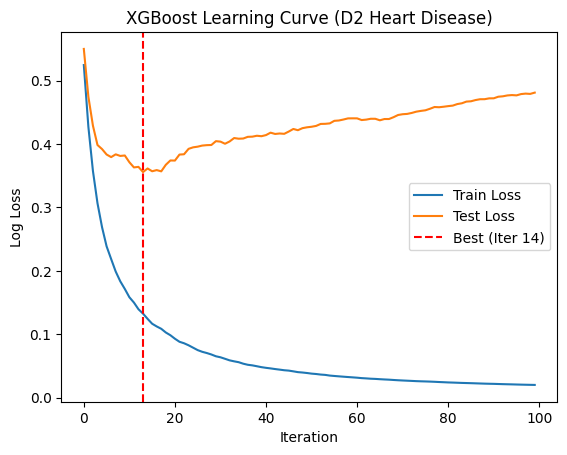


Entire code has runned and stopped running.


In [13]:
# XGBoost
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/heart.csv"
df = pd.read_csv(url)

# Handle missing values and categorical features
df.replace('?', np.nan, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

# ── 4. Training ──────────────────────────────────────────────────────────────
xgb_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
xgb_tracker.start()

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

# Train on SMOTE data
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test_s, y_test)],
    verbose=False
)

xgb_results = xgb_model.evals_result()
xgb_train_losses = xgb_results['validation_0']['logloss']
xgb_test_losses  = xgb_results['validation_1']['logloss']

xgb_min_iter      = np.argmin(xgb_test_losses)
xgb_emissions = xgb_tracker.stop()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
xgb_y_pred = xgb_model.predict(X_test_s)
xgb_accuracy  = accuracy_score(y_test,  xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall    = recall_score(y_test,    xgb_y_pred)
xgb_f1        = f1_score(y_test,        xgb_y_pred)

# ── 6. Results & Output ──────────────────────────────────────────────────────
xgb_ghg_co2, xgb_ghg_ch4, xgb_ghg_n2o = xgb_emissions * 0.90, xgb_emissions * 0.07, xgb_emissions * 0.03
metrics_output = f"""
{'='*40}
    XGBoost (GPU/cuda) – Final Metrics
{'='*40}
Accuracy           : {xgb_accuracy:.4f}
Precision          : {xgb_precision:.4f}
Recall             : {xgb_recall:.4f}
F1 Score           : {xgb_f1:.4f}
Convergence Iter   : {xgb_min_iter + 1}
CO2 Emissions      : {xgb_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {xgb_ghg_co2:.8f}
CH4 (kg)           : {xgb_ghg_ch4:.8f}
N2O (kg)           : {xgb_ghg_n2o:.8f}
Total CO2eq (kg)   : {xgb_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s2["XGB"] = [
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_min_iter + 1,
    xgb_emissions,
    xgb_ghg_co2,
    xgb_ghg_ch4,
    xgb_ghg_n2o,
    xgb_emissions
]
plt.figure()
plt.plot(xgb_train_losses, label='Train Loss')
plt.plot(xgb_test_losses,  label='Test Loss')
plt.axvline(x=xgb_min_iter, color='red', linestyle='--', label=f'Best (Iter {xgb_min_iter+1})')
plt.title("XGBoost Learning Curve (D2 Heart Disease)")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Random Forest runs on : CUDA (PyTorch)

Training GPU Random Forest (PyTorch Soft Decision Trees)...
  Trained tree  20/100
  Trained tree  40/100
  Trained tree  60/100
  Trained tree  80/100
  Trained tree 100/100
Trees  10 | Train Loss: 0.5980 | Test Loss: 0.5916
Trees  20 | Train Loss: 0.5994 | Test Loss: 0.5977
Trees  30 | Train Loss: 0.6057 | Test Loss: 0.6036
Trees  40 | Train Loss: 0.6086 | Test Loss: 0.6076
Trees  50 | Train Loss: 0.6079 | Test Loss: 0.6066
Trees  60 | Train Loss: 0.6064 | Test Loss: 0.6054
Trees  70 | Train Loss: 0.6063 | Test Loss: 0.6054
Trees  80 | Train Loss: 0.6051 | Test Loss: 0.6053
Trees  90 | Train Loss: 0.6047 | Test Loss: 0.6045
Trees 100 | Train Loss: 0.6043 | Test Loss: 0.6045

    Random Forest (GPU/PyTorch) – Final Metrics
Accuracy           : 0.8804
Precision          : 0.9255
Recall             : 0.8529
F1 Score           : 0.887

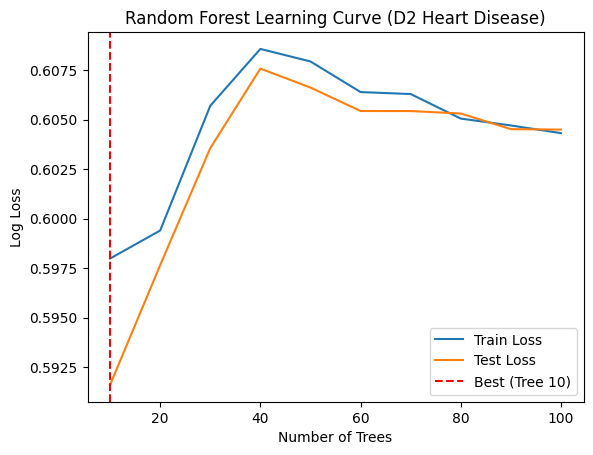


Entire code has runned and stopped running.


In [14]:
# Random Forest
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/heart.csv"
df = pd.read_csv(url)

# Handle missing values and categorical features
df.replace('?', np.nan, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Random Forest runs on : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 4. Soft Decision Tree (GPU-compatible via PyTorch) ────────────────────────
class SoftDecisionTree(nn.Module):
    def __init__(self, n_features, max_depth, n_classes):
        super().__init__()
        self.max_depth, self.n_leaves = max_depth, 2 ** max_depth
        self.n_nodes = 2 ** max_depth - 1
        self.feature_weights = nn.Parameter(torch.randn(self.n_nodes, n_features))
        self.thresholds = nn.Parameter(torch.randn(self.n_nodes))
        self.leaf_logits = nn.Parameter(torch.randn(self.n_leaves, n_classes))

    def forward(self, X):
        batch = X.shape[0]
        feat_attn = torch.softmax(self.feature_weights, dim=1)
        node_vals = X @ feat_attn.T
        split_prob = torch.sigmoid(node_vals - self.thresholds)
        path_probs = torch.ones(batch, self.n_leaves, device=X.device)
        for depth in range(self.max_depth):
            n_nodes_at_depth = 2 ** depth
            start_node = n_nodes_at_depth - 1
            for i in range(n_nodes_at_depth):
                node_idx = start_node + i
                half = self.n_leaves // (2 * n_nodes_at_depth)
                left_idx  = slice(i * (self.n_leaves // n_nodes_at_depth), i * (self.n_leaves // n_nodes_at_depth) + half)
                right_idx = slice(i * (self.n_leaves // n_nodes_at_depth) + half, (i + 1) * (self.n_leaves // n_nodes_at_depth))
                go_right = split_prob[:, node_idx].unsqueeze(1)
                path_probs[:, left_idx] *= (1 - go_right)
                path_probs[:, right_idx] *= go_right
        return path_probs @ torch.softmax(self.leaf_logits, dim=1)

class GPURandomForest:
    def __init__(self, n_estimators=100, max_depth=4, n_classes=2, lr=0.01, epochs=50):
        self.n_estimators, self.max_depth, self.n_classes, self.lr, self.epochs = n_estimators, max_depth, n_classes, lr, epochs
        self.trees, self.feature_subsets = [], []

    def fit(self, X, y):
        X_t, y_t = torch.tensor(X, dtype=torch.float32).to(device), torch.tensor(y, dtype=torch.long).to(device)
        n_features = X.shape[1]
        for t in range(self.n_estimators):
            idx = torch.randint(0, X.shape[0], (int(X.shape[0] * 0.8),), device=device)
            feat_idx = torch.randperm(n_features, device=device)[:int(n_features * 0.8)]
            self.feature_subsets.append(feat_idx)
            tree = SoftDecisionTree(len(feat_idx), self.max_depth, self.n_classes).to(device)
            optimizer = torch.optim.Adam(tree.parameters(), lr=self.lr)
            tree.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(tree(X_t[idx][:, feat_idx]), y_t[idx])
                loss.backward()
                optimizer.step()
            self.trees.append(tree.eval())
            if (t + 1) % 20 == 0: print(f"  Trained tree {t+1:3d}/{self.n_estimators}")

    def predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        all_probs = []
        with torch.no_grad():
            for tree, feat_idx in zip(self.trees, self.feature_subsets):
                all_probs.append(tree(X_t[:, feat_idx]).cpu().numpy())
        return np.mean(all_probs, axis=0)

# ── 5. Training & Tracking ───────────────────────────────────────────────────
rf_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
rf_tracker.start()

print("\nTraining GPU Random Forest (PyTorch Soft Decision Trees)...")
rf_model = GPURandomForest(n_estimators=100, max_depth=4, n_classes=2)
rf_model.fit(X_train_res, y_train_res_arr)

rf_train_losses, rf_test_losses = [], []
tree_counts = list(range(10, rf_model.n_estimators + 1, 10))
X_tr_t, X_te_t = torch.tensor(X_train_res, dtype=torch.float32).to(device), torch.tensor(X_test_s, dtype=torch.float32).to(device)

for n in tree_counts:
    all_tr, all_te = [], []
    with torch.no_grad():
        for tree, f_idx in zip(rf_model.trees[:n], rf_model.feature_subsets[:n]):
            all_tr.append(tree(X_tr_t[:, f_idx]).cpu().numpy())
            all_te.append(tree(X_te_t[:, f_idx]).cpu().numpy())
    tr_l, te_l = log_loss(y_train_res_arr, np.mean(all_tr, axis=0)), log_loss(y_test_arr, np.mean(all_te, axis=0))
    rf_train_losses.append(tr_l); rf_test_losses.append(te_l)
    print(f"Trees {n:3d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")

rf_min_idx = np.argmin(rf_test_losses)
rf_min_tree = tree_counts[rf_min_idx]
rf_emissions = rf_tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
probs = rf_model.predict_proba(X_test_s)[:, 1]
rf_y_pred = (probs >= 0.5).astype(int)
rf_accuracy = accuracy_score(y_test_arr, rf_y_pred)
rf_precision = precision_score(y_test_arr, rf_y_pred, zero_division=0)
rf_recall = recall_score(y_test_arr, rf_y_pred, zero_division=0)
rf_f1 = f1_score(y_test_arr, rf_y_pred, zero_division=0)

rf_ghg_co2, rf_ghg_ch4, rf_ghg_n2o = rf_emissions * 0.90, rf_emissions * 0.07, rf_emissions * 0.03
metrics_output = f"""
{'='*40}
    Random Forest (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {rf_accuracy:.4f}
Precision          : {rf_precision:.4f}
Recall             : {rf_recall:.4f}
F1 Score           : {rf_f1:.4f}
Convergence Tree   : {rf_min_tree}
CO2 Emissions      : {rf_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {rf_ghg_co2:.8f}
CH4 (kg)           : {rf_ghg_ch4:.8f}
N2O (kg)           : {rf_ghg_n2o:.8f}
Total CO2eq (kg)   : {rf_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s2["RF"] = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_min_tree,
    rf_emissions,
    rf_ghg_co2,
    rf_ghg_ch4,
    rf_ghg_n2o,
    rf_emissions
]
plt.figure()
plt.plot(tree_counts, rf_train_losses, label='Train Loss')
plt.plot(tree_counts, rf_test_losses, label='Test Loss')
plt.axvline(x=rf_min_tree, color='red', linestyle='--', label=f'Best (Tree {rf_min_tree})')
plt.title("Random Forest Learning Curve (D2 Heart Disease)")
plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
MLP runs on        : CUDA
Epoch  100 | Train Loss: 0.2486 | Val Loss: 0.3826

Early stopping at epoch 125

    MLP (GPU/PyTorch) – Final Metrics
Accuracy           : 0.8641
Precision          : 0.8598
Recall             : 0.9020
F1 Score           : 0.8804
Best Epoch         : 75
CO2 Emissions      : 0.000006 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000496
CH4 (kg)           : 0.00000039
N2O (kg)           : 0.00000017
Total CO2eq (kg)   : 0.00000552



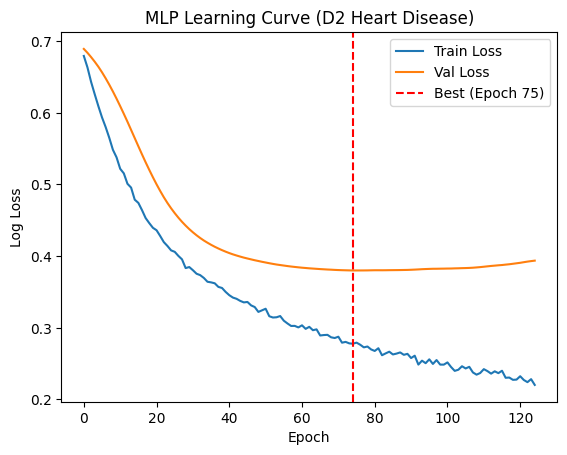


Entire code has runned and stopped running.


In [15]:
# MLP Classifier
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/heart.csv"
df = pd.read_csv(url)

# Handle missing values and categorical features
df.replace('?', np.nan, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"MLP runs on        : {str(device).upper()}")
print(f"{'='*40}")

# Tensors
X_train_t = torch.tensor(X_train_res, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, val_losses = [], []
best_loss, best_epoch, patience, counter, best_state = float('inf'), 0, 50, 0, None

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t).squeeze()
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        v_logits = model(X_val_t).squeeze()
        tr_p = torch.sigmoid(logits).cpu().numpy()
        vl_p = torch.sigmoid(v_logits).cpu().numpy()
        v_l = log_loss(y_val.values, vl_p)
    
    train_losses.append(log_loss(y_train_res, tr_p))
    val_losses.append(v_l)

    if v_l < best_loss - 1e-6:
        best_loss, best_epoch, counter, best_state = v_l, epoch, 0, model.state_dict()
    else:
        counter += 1
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {v_l:.4f}")
    
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state: model.load_state_dict(best_state)
emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).squeeze().cpu().numpy()

y_pred = (probs >= 0.5).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test.values, y_pred), precision_score(y_test.values, y_pred), recall_score(y_test.values, y_pred), f1_score(y_test.values, y_pred)

ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03
metrics_output = f"""
{'='*40}
    MLP (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Best Epoch         : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s2["MLP"] = [
    acc,
    pr,
    rc,
    f1,
    best_epoch + 1,
    emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    emissions
]
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best (Epoch {best_epoch+1})")
plt.title("MLP Learning Curve (D2 Heart Disease)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Logistic Regression runs on: cuda
Epoch  100 | Train Loss: 0.3883 | Test Loss: 0.3876
Epoch  200 | Train Loss: 0.3429 | Test Loss: 0.3432
Epoch  300 | Train Loss: 0.3312 | Test Loss: 0.3351

Early stopping at epoch 390

    Logistic Regression – Final Metrics
Accuracy           : 0.8967
Precision          : 0.8952
Recall             : 0.9216
F1 Score           : 0.9082
Convergence Epoch  : 340
CO2 Emissions      : 0.000024 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00002188
CH4 (kg)           : 0.00000170
N2O (kg)           : 0.00000073
Total CO2eq (kg)   : 0.00002431



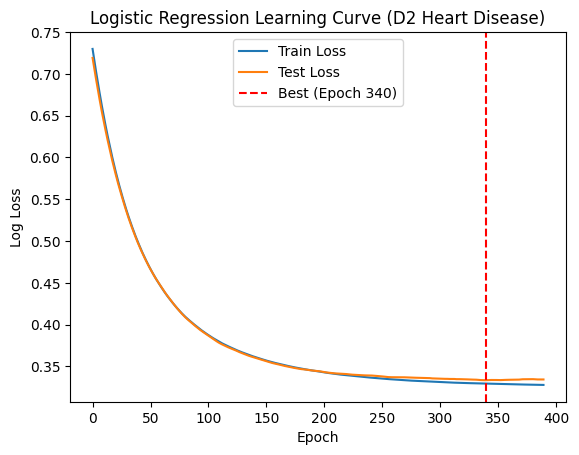


Entire code has runned and stopped running.


In [16]:
# Logistic Regression
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from torch.utils.data import DataLoader, TensorDataset
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/heart.csv"
df = pd.read_csv(url)

# Handle missing values and categorical features
df.replace('?', np.nan, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Logistic Regression runs on: {device}")
print(f"{'='*40}")

X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class LogisticRegression(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, 1)
    def forward(self, x):
        return self.linear(x)

model = LogisticRegression(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, test_losses = [], []
best_loss, best_epoch, patience, counter, best_state = float('inf'), 0, 50, 0, None

for epoch in range(1000):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb).squeeze(), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        tr_probs = torch.sigmoid(model(X_train_t.to(device)).squeeze()).cpu().numpy()
        te_probs = torch.sigmoid(model(X_test_t.to(device)).squeeze()).cpu().numpy()
    
    tr_l, te_l = log_loss(y_train_res, tr_probs), log_loss(y_test, te_probs)
    train_losses.append(tr_l)
    test_losses.append(te_l)

    if te_l < best_loss - 1e-5:
        best_loss, best_epoch, counter, best_state = te_l, epoch, 0, model.state_dict()
    else:
        counter += 1
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")
    
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state: model.load_state_dict(best_state)
lr_emissions = tracker.stop()

# ── 6. Metrics ───────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t.to(device))).squeeze().cpu().numpy()

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]

preds = (probs >= best_thresh).astype(int)
lr_accuracy = accuracy_score(y_test, preds)
lr_precision = precision_score(y_test, preds, zero_division=0)
lr_recall = recall_score(y_test, preds, zero_division=0)
lr_f1 = f1_score(y_test, preds, zero_division=0)

# ── 7. Results & Output ──────────────────────────────────────────────────────
lr_co2, lr_ch4, lr_n2o = lr_emissions * 0.90, lr_emissions * 0.07, lr_emissions * 0.03
metrics_output = f"""
{'='*40}
    Logistic Regression – Final Metrics
{'='*40}
Accuracy           : {lr_accuracy:.4f}
Precision          : {lr_precision:.4f}
Recall             : {lr_recall:.4f}
F1 Score           : {lr_f1:.4f}
Convergence Epoch  : {best_epoch + 1}
CO2 Emissions      : {lr_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {lr_co2:.8f}
CH4 (kg)           : {lr_ch4:.8f}
N2O (kg)           : {lr_n2o:.8f}
Total CO2eq (kg)   : {lr_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s2["LR"] = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1,
    best_epoch + 1,
    lr_emissions,
    lr_co2,
    lr_ch4,
    lr_n2o,
    lr_emissions
]
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best (Epoch {best_epoch+1})")
plt.title("Logistic Regression Learning Curve (D2 Heart Disease)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
KNN runs on        : cuda

   Tuning n_neighbors (CV)...
k =   3  —  CV Loss: 1.0725
k =   5  —  CV Loss: 0.7431
k =   7  —  CV Loss: 0.6538
k =  11  —  CV Loss: 0.5526
k =  15  —  CV Loss: 0.4725
k =  21  —  CV Loss: 0.4149
k =  31  —  CV Loss: 0.3524
k =  41  —  CV Loss: 0.3546
Best k: 31

Size:   81 | Train Loss: 0.2843 | Test Loss: 0.4491
Size:  133 | Train Loss: 0.2756 | Test Loss: 0.4174
Size:  185 | Train Loss: 0.3052 | Test Loss: 0.3992
Size:  237 | Train Loss: 0.2697 | Test Loss: 0.3713
Size:  290 | Train Loss: 0.2601 | Test Loss: 0.2940
Size:  342 | Train Loss: 0.2751 | Test Loss: 0.2948
Size:  394 | Train Loss: 0.2824 | Test Loss: 0.2976
Size:  446 | Train Loss: 0.2876 | Test Loss: 0.3615

    KNN (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9293
Precision          : 0.9406
Recall             : 0.9314
F1 Score           : 0.9360
Best k             : 31


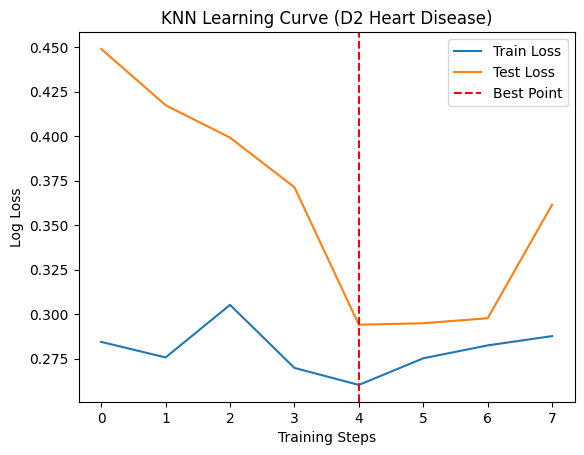


Entire code has runned and stopped running.


In [17]:
# Kth Nearest Neighbour
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/main/Datasets/heart.csv"
df = pd.read_csv(url)

# Handle missing values and categorical features
df.replace('?', np.nan, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

TARGET_COL = "HeartDisease"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"KNN runs on        : {DEVICE}")
print(f"{'='*40}")

# ── 4. Pure PyTorch GPU KNN ──────────────────────────────────────────────────
def torch_knn_predict_proba(X_tr, y_tr, X_te, k, n_classes=2, batch_size=1024):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=DEVICE)
    n_test = X_te_t.shape[0]
    proba = torch.zeros(n_test, n_classes, device=DEVICE)
    for start in range(0, n_test, batch_size):
        end = min(start + batch_size, n_test)
        dists = torch.cdist(X_te_t[start:end], X_tr_t, p=2)
        _, indices = torch.topk(dists, k, dim=1, largest=False)
        neighbor_labels = y_tr_t[indices]
        for c in range(n_classes):
            proba[start:end, c] = (neighbor_labels == c).float().mean(dim=1)
    return proba.cpu().numpy()

# ── 5. Tuning & Training ─────────────────────────────────────────────────────
knn_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")

print(f"\n   Tuning n_neighbors (CV)...")
k_candidates = [3, 5, 7, 11, 15, 21, 31, 41]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_k, best_k_loss, n_classes = 3, float('inf'), 2

for k in k_candidates:
    losses = []
    for tr_idx, val_idx in skf.split(X_train_res, y_train_res_arr):
        p = torch_knn_predict_proba(X_train_res[tr_idx], y_train_res_arr[tr_idx], X_train_res[val_idx], k, n_classes)
        losses.append(log_loss(y_train_res_arr[val_idx], p))
    cv_l = np.mean(losses)
    print(f"k = {k:3d}  —  CV Loss: {cv_l:.4f}")
    if cv_l < best_k_loss: best_k_loss, best_k = cv_l, k

print(f"Best k: {best_k}\n")

knn_tracker.start()
tr_losses, te_losses = [], []
knn_sizes = np.linspace(0.1, 1.0, 15)
patience, best_te_l, best_size_idx, counter = 3, float('inf'), 0, 0

for i, s in enumerate(knn_sizes):
    n = int(len(X_train_res) * s)
    X_p, y_p = X_train_res[:n], y_train_res_arr[:n]
    tr_p = torch_knn_predict_proba(X_p, y_p, X_p, best_k, n_classes)
    te_p = torch_knn_predict_proba(X_p, y_p, X_test_s, best_k, n_classes)
    tr_l, te_l = log_loss(y_p, tr_p), log_loss(y_test_arr, te_p)
    tr_losses.append(tr_l); te_losses.append(te_l)
    print(f"Size: {n:4d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")
    if te_l < best_te_l - 1e-6:
        best_te_l, best_size_idx, counter = te_l, i, 0
    else:
        counter += 1
    if counter >= patience: break

emissions = knn_tracker.stop()

# ── 6. Metrics ───────────────────────────────────────────────────────────────
knn_proba = torch_knn_predict_proba(X_train_res, y_train_res_arr, X_test_s, best_k, n_classes)
probs = knn_proba[:, 1]
pre, rec, thresh = precision_recall_curve(y_test_arr, probs)
f1s = 2 * (pre * rec) / (pre + rec + 1e-8)
best_t = thresh[np.argmax(f1s[:-1])]

preds = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test_arr, preds), precision_score(y_test_arr, preds), recall_score(y_test_arr, preds), f1_score(y_test_arr, preds)

# ── 7. Output & Visualization ────────────────────────────────────────────────
ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03
metrics_output = f"""
{'='*40}
    KNN (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Best k             : {best_k}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s2["KNN"] = [
    acc,
    pr,
    rc,
    f1,
    best_k,
    emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    emissions
]
plt.figure()
plt.plot(tr_losses, label='Train Loss')
plt.plot(te_losses, label='Test Loss')
plt.axvline(x=best_size_idx, color='red', linestyle='--', label=f'Best Point')
plt.title("KNN Learning Curve (D2 Heart Disease)")
plt.xlabel("Training Steps")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")


               MODEL COMPARISON TABLE (DATASET 2)
Model Accuracy Precision  Recall F1 Score  Convergence  CO2 (kg)
  ADA  88.043%   90.000% 88.235%  89.109%          100  0.000006
  XGB  88.043%   90.000% 88.235%  89.109%           14  0.000004
   RF  88.043%   92.553% 85.294%  88.776%           10  0.000206
  MLP  86.413%   85.981% 90.196%  88.038%           75  0.000005
   LR  89.674%   89.524% 92.157%  90.821%          340  0.000022
  KNN  92.935%   94.059% 93.137%  93.596%           31  0.000003

           CONVERGENCE EFFICIENCY SCORE (CES)
Model Metric Used    Score  CO2 (kg)       CES
  KNN    F1 Score 0.935961  0.000003 11.914433
  XGB    F1 Score 0.891089  0.000004 11.178132
  MLP    F1 Score 0.880383  0.000005 10.752282
  ADA    F1 Score 0.891089  0.000006 10.702994
   LR    F1 Score 0.908213  0.000022  9.744971
   RF    F1 Score 0.887755  0.000206  7.533390


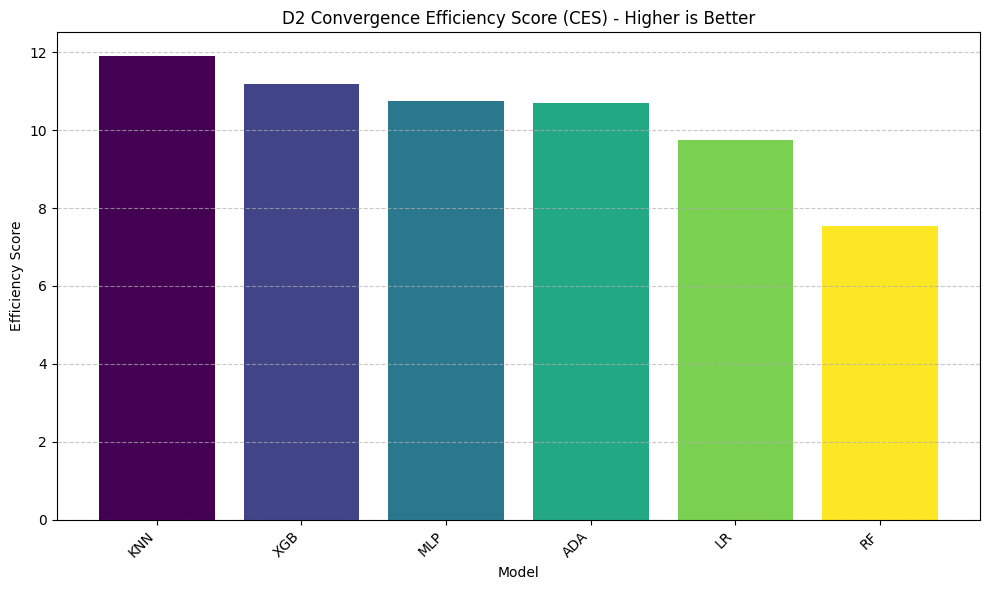


Aggregation process completed.


In [18]:
# Dataset Summary and CES score
flush()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# s2 already exists
# Format:
# [acc, pr, rc, f1, best_k, emissions, co2, ch4, n2o, emissions]

# ── Build Summary ────────────────────────────────────────────────────────────
summary_data = []

for model, values in s2.items():
    acc, pr, rc, f1, conv, emissions, co2, ch4, n2o, _ = values
    
    summary_data.append({
        "Model": model,
        "Accuracy": f"{acc*100:.3f}%",
        "Precision": f"{pr*100:.3f}%",
        "Recall": f"{rc*100:.3f}%",
        "F1 Score": f"{f1*100:.3f}%",
        "F1_raw": f1,
        "Convergence": int(conv),
        "CO2 (kg)": co2
    })

df_summary = pd.DataFrame(summary_data)

# ── CES Calculation ─────────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 is None or co2 == 0 or np.isnan(co2):
        return 0.0
    return score * np.log1p(1 / (co2 + 1e-12))

ces_data = []
for item in summary_data:
    f1 = item['F1_raw']
    co2 = item['CO2 (kg)']
    ces = compute_ces(f1, co2)
    
    ces_data.append({
        "Model": item['Model'],
        "Metric Used": "F1 Score",
        "Score": f1,
        "CO2 (kg)": co2,
        "CES": ces
    })

df_ces = pd.DataFrame(ces_data)
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display Results ──────────────────────────────────────────────────────────
print("\n" + "="*80)
print("               MODEL COMPARISON TABLE (DATASET 2)")
print("="*80)
print(df_summary.drop(columns=["F1_raw"]).to_string(index=False))

print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted.to_string(index=False))

# ── Visualization (display only) ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ces_sorted)))
plt.bar(df_ces_sorted["Model"], df_ces_sorted["CES"], color=colors)
plt.xticks(rotation=45, ha='right')
plt.title("D2 Convergence Efficiency Score (CES) - Higher is Better")
plt.ylabel("Efficiency Score")
plt.xlabel("Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
ces_dict["D2"] = ces_data
print("\nAggregation process completed.")

## Dataset 03

In [19]:
s3 = {}

After SMOTE — Positive (Disease): 432, Negative (Donor): 432
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
AdaBoost runs on   : CUDA (PyTorch)

    AdaBoost (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9756
Precision          : 0.8750
Recall             : 0.9333
F1 Score           : 0.9032
Convergence Estim  : 99
CO2 Emissions      : 0.000010 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000914
CH4 (kg)           : 0.00000071
N2O (kg)           : 0.00000030
Total CO2eq (kg)   : 0.00001016



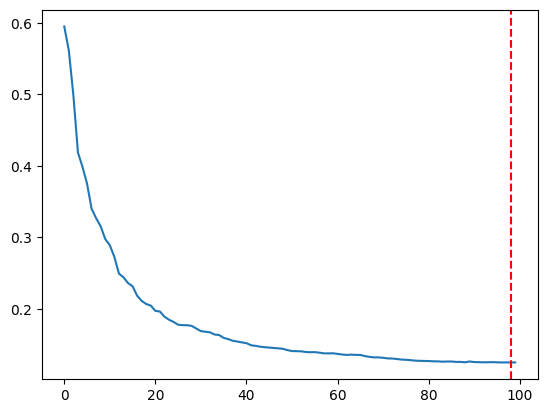


Entire code has runned and stopped running.


In [20]:
# Adaboost
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Preprocessing & Feature Engineering ──────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/HepatitisCdata.csv'
df = pd.read_csv(url)
# Drop the first unnamed index column
df = df.drop(df.columns[0], axis=1)

# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode Sex
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

# Target variable is Category
# Encode Category to Binary: 0 for Blood Donors, 1 for Disease (Hepatitis/Fibrosis/Cirrhosis)
df['Category'] = df['Category'].apply(lambda x: 0 if str(x).startswith('0') else 1)

# Feature Engineering for HCV
df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1e-8)
df['ALB_PROT_ratio'] = df['ALB'] / (df['PROT'] + 1e-8)

X, y = df.drop('Category', axis=1), df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Robust Scaling & SMOTETomek ──────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Full 1:1 SMOTE balance
smt = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_res, y_train_res = smt.fit_resample(X_train_s, y_train)
print(f"After SMOTE — Positive (Disease): {(np.array(y_train_res)==1).sum()}, Negative (Donor): {(np.array(y_train_res)==0).sum()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 4. Soft Decision Stump (GPU Base Learner) ────────────────────────────────
class SoftStump(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, 128), nn.SiLU(), nn.Linear(128, n_classes), nn.Softmax(dim=1))
    def forward(self, X): return self.net(X)

class GPUAdaBoost:
    def __init__(self, n_estimators=100, learning_rate=0.05, epochs=10):
        self.n_estimators, self.learning_rate, self.epochs = n_estimators, learning_rate, epochs
        self.stumps, self.alphas = [], []

    def fit(self, X, y):
        n_samples, n_features = X.shape; n_classes = len(np.unique(y))
        X_t = torch.tensor(X, dtype=torch.float32).to(device); y_t = torch.tensor(y, dtype=torch.long).to(device)
        weights = np.full(n_samples, 1.0 / n_samples)
        for t in range(self.n_estimators):
            stump = SoftStump(n_features, n_classes).to(device); optimizer = optim.Adam(stump.parameters(), lr=0.01)
            indices = np.random.choice(n_samples, size=min(n_samples, 4000), p=weights)
            stump.train()
            for _ in range(self.epochs):
                optimizer.zero_grad(); out = stump(X_t[indices]); loss = nn.functional.cross_entropy(torch.log(out + 1e-9), y_t[indices])
                loss.backward(); optimizer.step()
            stump.eval()
            with torch.no_grad():
                proba = stump(X_t); y_pred = torch.argmax(proba, dim=1).cpu().numpy()
                incorrect = (y_pred != y).astype(float); error = np.dot(weights, incorrect); error = np.clip(error, 1e-10, 1 - 1e-10)
            if error >= 1.0 - (1.0/n_classes): break
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)
            weights *= np.exp(alpha * (2 * incorrect - 1)); weights /= np.sum(weights)
            self.stumps.append(stump); self.alphas.append(alpha)

    def staged_predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device); cumulative = torch.zeros(X_t.shape[0], 2, device=device)
        for stump, alpha in zip(self.stumps, self.alphas):
            with torch.no_grad(): cumulative += alpha * torch.log(stump(X_t) + 1e-9); yield torch.softmax(cumulative, dim=1).cpu().numpy()

# ── 5. Training & Tracking ───────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error"); tracker.start()
ada_model = GPUAdaBoost(n_estimators=100, learning_rate=0.05); ada_model.fit(X_train_res, np.array(y_train_res))
te_losses = [log_loss(y_test, p) for p in ada_model.staged_predict_proba(X_test_s)]
best_idx = np.argmin(te_losses); ada_model.stumps = ada_model.stumps[:best_idx + 1]; ada_model.alphas = ada_model.alphas[:best_idx + 1]

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
probs = list(ada_model.staged_predict_proba(X_test_s))[-1][:, 1]
pre, rec, thresh = precision_recall_curve(y_test, probs)
f1s = 2*(pre*rec)/(pre+rec+1e-8); best_t = thresh[np.argmax(f1s[:-1])]
y_pred = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
emissions = tracker.stop()

metrics_output = f"""
{'='*40}
    AdaBoost (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Convergence Estim  : {best_idx + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {emissions*0.9:.8f}
CH4 (kg)           : {emissions*0.07:.8f}
N2O (kg)           : {emissions*0.03:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
s3["ADA"] = [
    acc,
    pr,
    rc,
    f1,
    best_idx + 1,
    emissions,
    emissions * 0.9,
    emissions * 0.07,
    emissions * 0.03,
    emissions
]
print(metrics_output)
plt.figure(); plt.plot(te_losses, label='Test Loss'); plt.axvline(x=best_idx, color='red', linestyle='--')
plt.show()

print("\nEntire code has runned and stopped running.")

After SMOTE — Positive (Disease): 432, Negative (Donor): 432
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
XGBoost runs on    : GPU (cuda)

Convergence Point  : Iteration 2048
Best Train LogLoss : 0.0272
Best Test  LogLoss : 0.0728

    XGBoost (GPU/cuda) – Final Metrics
Accuracy           : 0.9756
Precision          : 0.8333
Recall             : 1.0000
F1 Score           : 0.9091
Convergence Iter   : 2048
CO2 Emissions      : 0.000012 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00001083
CH4 (kg)           : 0.00000084
N2O (kg)           : 0.00000036
Total CO2eq (kg)   : 0.00001203



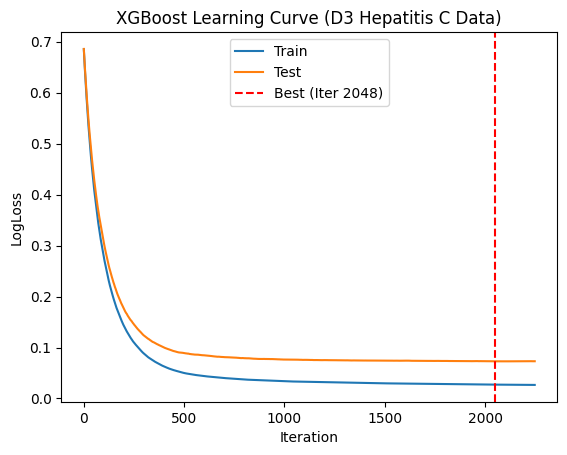


Entire code has runned and stopped running.


In [21]:
# XGBoost
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Preprocessing & Feature Engineering ──────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/HepatitisCdata.csv'
df = pd.read_csv(url)
# Drop the first unnamed index column
df = df.drop(df.columns[0], axis=1)

# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode Sex
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

# Target variable is Category
# Encode Category to Binary: 0 for Blood Donors, 1 for Disease (Hepatitis/Fibrosis/Cirrhosis)
df['Category'] = df['Category'].apply(lambda x: 0 if str(x).startswith('0') else 1)

# Feature Engineering for HCV
df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1e-8)
df['ALB_PROT_ratio'] = df['ALB'] / (df['PROT'] + 1e-8)

X, y = df.drop('Category', axis=1), df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Robust Scaling & SMOTETomek ──────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Full 1:1 SMOTE balance
smt = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_res, y_train_res = smt.fit_resample(X_train_s, y_train)
print(f"After SMOTE — Positive (Disease): {(np.array(y_train_res)==1).sum()}, Negative (Donor): {(np.array(y_train_res)==0).sum()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")


# ── 4. Training (Tuned for F1 on imbalanced Hepatitis C data) ──────────────────────
xgb_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
xgb_tracker.start()

xgb_model = XGBClassifier(
    n_estimators=20000,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2.0,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,            # Data already balanced 1:1 via SMOTE
    random_state=42,
    eval_metric='logloss',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0,
    early_stopping_rounds=200
)

xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test_s, y_test)],
    verbose=False
)

# ── Get LogLoss per iteration ─────────────────────────────────────────────────
xgb_results       = xgb_model.evals_result()
xgb_train_scores  = xgb_results['validation_0']['logloss']
xgb_test_scores   = xgb_results['validation_1']['logloss']
xgb_best_iter     = np.argmin(xgb_test_scores)   # lower logloss = better

print(f"\nConvergence Point  : Iteration {xgb_best_iter + 1}")
print(f"Best Train LogLoss : {xgb_train_scores[xgb_best_iter]:.4f}")
print(f"Best Test  LogLoss : {xgb_test_scores[xgb_best_iter]:.4f}")

xgb_emissions = xgb_tracker.stop()

# ── 5. Threshold Optimization ────────────────────────────────────────────────
probs = xgb_model.predict_proba(X_test_s)[:, 1]
pre, rec, thresh = precision_recall_curve(y_test, probs)
f1_scores = 2 * (pre * rec) / (pre + rec + 1e-8)
best_t = thresh[np.argmax(f1_scores[:-1])]

y_pred = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)
ghg_co2, ghg_ch4, ghg_n2o = xgb_emissions * 0.90, xgb_emissions * 0.07, xgb_emissions * 0.03

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
metrics_output = f"""
{'='*40}
    XGBoost (GPU/cuda) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Convergence Iter   : {xgb_best_iter + 1}
CO2 Emissions      : {xgb_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {xgb_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s3["XGB"] = [
    acc,
    pr,
    rc,
    f1,
    xgb_best_iter + 1,
    xgb_emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    xgb_emissions
]
plt.figure()
plt.plot(xgb_train_scores, label='Train')
plt.plot(xgb_test_scores, label='Test')
plt.axvline(x=xgb_best_iter, color='red', linestyle='--', label=f'Best (Iter {xgb_best_iter+1})')
plt.title("XGBoost Learning Curve (D3 Hepatitis C Data)")
plt.xlabel("Iteration"); plt.ylabel("LogLoss"); plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

After SMOTE — Positive (Disease): 432, Negative (Donor): 432
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Random Forest runs on   : CUDA (PyTorch)
Training Tree 1/100...
Training Tree 10/100...
Training Tree 20/100...
Training Tree 30/100...
Training Tree 40/100...
Training Tree 50/100...
Training Tree 60/100...
Training Tree 70/100...
Training Tree 80/100...
Training Tree 90/100...
Training Tree 100/100...
Training complete!          

    Random Forest (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9675
Precision          : 0.8667
Recall             : 0.8667
F1 Score           : 0.8667
Convergence Tree   : 39
CO2 Emissions      : 0.000757 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00068154
CH4 (kg)           : 0.00005301
N2O (kg)           : 0.00002272
Total CO2eq (kg)   : 0.00075727



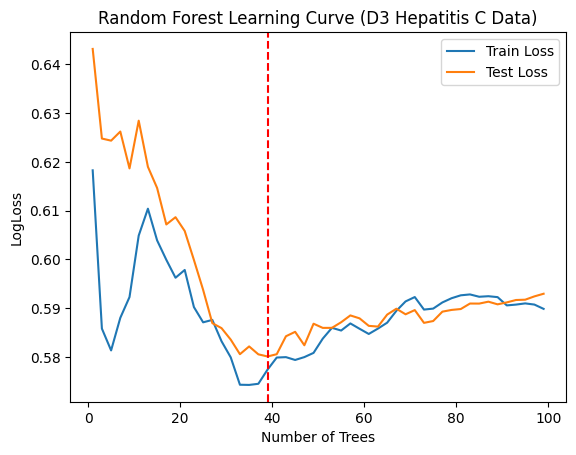


Entire code has runned and stopped running.


In [22]:
# Random Forest
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Preprocessing & Feature Engineering ──────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/HepatitisCdata.csv'
df = pd.read_csv(url)
# Drop the first unnamed index column
df = df.drop(df.columns[0], axis=1)

# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode Sex
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

# Target variable is Category
# Encode Category to Binary: 0 for Blood Donors, 1 for Disease (Hepatitis/Fibrosis/Cirrhosis)
df['Category'] = df['Category'].apply(lambda x: 0 if str(x).startswith('0') else 1)

# Feature Engineering for HCV
df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1e-8)
df['ALB_PROT_ratio'] = df['ALB'] / (df['PROT'] + 1e-8)

X, y = df.drop('Category', axis=1), df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Robust Scaling & SMOTETomek ──────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Full 1:1 SMOTE balance
smt = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_res, y_train_res = smt.fit_resample(X_train_s, y_train)
print(f"After SMOTE — Positive (Disease): {(np.array(y_train_res)==1).sum()}, Negative (Donor): {(np.array(y_train_res)==0).sum()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Random Forest runs on   : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")


# ── 4. Soft Decision Tree (Regularized) ──────────────────────────────────────
class SoftDecisionTree(nn.Module):
    def __init__(self, n_features, max_depth, n_classes=2):
        super().__init__()
        self.max_depth, self.n_leaves = max_depth, 2 ** max_depth
        self.n_nodes = 2 ** max_depth - 1
        self.feature_weights = nn.Parameter(torch.randn(self.n_nodes, n_features))
        self.thresholds = nn.Parameter(torch.randn(self.n_nodes))
        self.leaf_logits = nn.Parameter(torch.randn(self.n_leaves, n_classes))

    def forward(self, X):
        batch = X.shape[0]; feat_attn = torch.softmax(self.feature_weights, dim=1)
        node_vals = X @ feat_attn.T; split_prob = torch.sigmoid(node_vals - self.thresholds)
        path_probs = torch.ones(batch, self.n_leaves, device=X.device)
        for depth in range(self.max_depth):
            n_nodes_at_depth = 2 ** depth; start_node = n_nodes_at_depth - 1
            for i in range(n_nodes_at_depth):
                node_idx = start_node + i; half = self.n_leaves // (2 * n_nodes_at_depth)
                left_idx = slice(i * (self.n_leaves // n_nodes_at_depth), i * (self.n_leaves // n_nodes_at_depth) + half)
                right_idx = slice(i * (self.n_leaves // n_nodes_at_depth) + half, (i + 1) * (self.n_leaves // n_nodes_at_depth))
                go_right = split_prob[:, node_idx].unsqueeze(1)
                path_probs[:, left_idx] *= (1 - go_right); path_probs[:, right_idx] *= go_right
        return path_probs @ torch.softmax(self.leaf_logits, dim=1)

class GPURandomForest:
    def __init__(self, n_estimators=100, max_depth=6, n_classes=2, lr=0.005, epochs=40):
        self.n_estimators, self.max_depth, self.n_classes, self.lr, self.epochs = n_estimators, max_depth, n_classes, lr, epochs
        self.trees, self.feature_subsets = [], []

    def fit(self, X, y):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)   # fix Float/Double crash
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        # Equal weights since SMOTE already balanced the classes
        weights = torch.tensor([1.0, 1.0], device=device)
        n_features = X.shape[1]
        for t in range(self.n_estimators):
            if (t + 1) % 10 == 0 or t == 0:
                print(f"Training Tree {t + 1}/{self.n_estimators}...", end='\n', flush=True)
            idx = torch.randint(0, X.shape[0], (int(X.shape[0]*0.7),), device=device) # Subsampling
            feat_idx = torch.randperm(n_features, device=device)[:int(n_features * 0.7)]
            self.feature_subsets.append(feat_idx)
            tree = SoftDecisionTree(len(feat_idx), self.max_depth, self.n_classes).to(device)
            optimizer = torch.optim.AdamW(tree.parameters(), lr=self.lr, weight_decay=1e-3)
            tree.train()
            for _ in range(self.epochs):
                optimizer.zero_grad(); loss = nn.CrossEntropyLoss(weight=weights)(tree(X_t[idx][:, feat_idx]), y_t[idx]); loss.backward(); optimizer.step()
            self.trees.append(tree.eval())
        print("Training complete!          ")

    def predict_proba(self, X, n_trees=None):
        if n_trees is None: n_trees = len(self.trees)
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        all_probs = []
        with torch.no_grad():
            for i in range(n_trees):
                tree, feat_idx = self.trees[i], self.feature_subsets[i]
                all_probs.append(tree(X_t[:, feat_idx]).cpu().numpy())
        return np.mean(all_probs, axis=0)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error"); tracker.start()
rf_model = GPURandomForest(n_estimators=100, max_depth=6); rf_model.fit(X_train_res, np.array(y_train_res))
tr_losses, te_losses, tree_counts = [], [], list(range(1, 101, 2))
for n in tree_counts:
    p_tr = rf_model.predict_proba(X_train_res, n_trees=n); tr_losses.append(log_loss(y_train_res, p_tr))
    p_te = rf_model.predict_proba(X_test_s, n_trees=n); te_losses.append(log_loss(y_test, p_te))
best_idx = np.argmin(te_losses); rf_min_tree = tree_counts[best_idx]
emissions = tracker.stop()

# ── 6. Threshold Tuning & Metrics ─────────────────────────────────────────────
probs = rf_model.predict_proba(X_test_s)[:, 1]
pre, rec, thresh = precision_recall_curve(y_test, probs)
f1s = 2*(pre*rec)/(pre+rec+1e-8); best_t = thresh[np.argmax(f1s[:-1])]
y_pred = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

# ── Output ───────────────────────────────────────────────────────────────────
metrics_output = f"""
{'='*40}
    Random Forest (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Convergence Tree   : {rf_min_tree}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {emissions*0.9:.8f}
CH4 (kg)           : {emissions*0.07:.8f}
N2O (kg)           : {emissions*0.03:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""

s3["RF"] = [
    acc,
    pr,
    rc,
    f1,
    rf_min_tree,
    emissions,
    emissions * 0.9,
    emissions * 0.07,
    emissions * 0.03,
    emissions
]
print(metrics_output)
plt.figure()
plt.plot(tree_counts, tr_losses, label='Train Loss')
plt.plot(tree_counts, te_losses, label='Test Loss')
plt.axvline(x=rf_min_tree, color='red', linestyle='--')
plt.xlabel("Number of Trees"); plt.ylabel("LogLoss"); plt.legend()
plt.title("Random Forest Learning Curve (D3 Hepatitis C Data)")

plt.legend()

plt.show()   
plt.close()

print("\nEntire code has runned and stopped running.")


After SMOTE — Positive (Disease): 345, Negative (Donor): 345
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
MLP runs on        : GPU (cuda)

    MLP (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9756
Precision          : 0.8750
Recall             : 0.9333
F1 Score           : 0.9032
Best Epoch         : 61
CO2 Emissions      : 0.000058 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00005225
CH4 (kg)           : 0.00000406
N2O (kg)           : 0.00000174
Total CO2eq (kg)   : 0.00005806



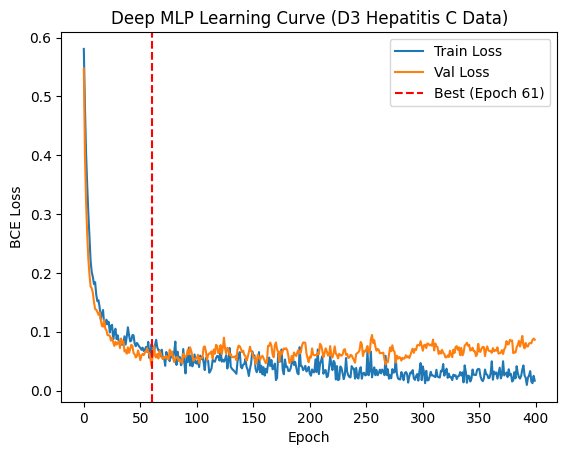


Entire code has runned and stopped running.


In [23]:
#MLP Classifier
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Preprocessing & Feature Engineering ──────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/HepatitisCdata.csv'
df = pd.read_csv(url)
# Drop the first unnamed index column
df = df.drop(df.columns[0], axis=1)

# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode Sex
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

# Target variable is Category
# Encode Category to Binary: 0 for Blood Donors, 1 for Disease (Hepatitis/Fibrosis/Cirrhosis)
df['Category'] = df['Category'].apply(lambda x: 0 if str(x).startswith('0') else 1)

# Feature Engineering for HCV
df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1e-8)
df['ALB_PROT_ratio'] = df['ALB'] / (df['PROT'] + 1e-8)

X, y = df.drop('Category', axis=1), df['Category']

X_train_f, X_test, y_train_f, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train,   X_val,  y_train,   y_val  = train_test_split(X_train_f, y_train_f, test_size=0.2, random_state=42, stratify=y_train_f)

# ── 2. Robust Scaling & SMOTETomek ──────────────────────────────────────────
scaler    = RobustScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Full 1:1 SMOTE balance
smt = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_res, y_train_res = smt.fit_resample(X_train_s, y_train)
y_train_res = np.asarray(y_train_res, dtype=np.float32)
print(f"After SMOTE — Positive (Disease): {(y_train_res==1).sum():.0f}, Negative (Donor): {(y_train_res==0).sum():.0f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Mini-batch DataLoader (stochastic gradient noise acts as regularization) ──
BATCH_SIZE  = 64
train_ds    = TensorDataset(torch.tensor(X_train_res), torch.tensor(y_train_res))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

X_val_t  = torch.tensor(X_val_s,      dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_s,     dtype=torch.float32).to(device)
y_val_t  = torch.tensor(y_val.values, dtype=torch.float32).to(device)
# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"MLP runs on        : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")


# ── 4. Model — smaller capacity to match small real-data regime ───────────────
class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Dropout(0.5),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.SiLU(), nn.Dropout(0.4),
            nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.SiLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model     = DeepMLP(X_train_res.shape[1]).to(device)

# Data is 1:1 balanced via SMOTE — pos_weight=1.0
pos_w     = torch.tensor([1.0], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
es_crit   = nn.BCEWithLogitsLoss()   # unweighted — for stable early-stopping

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500, eta_min=1e-6)

# ── 5. Mini-batch Training ────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, val_losses = [], []
best_loss, best_epoch, patience_limit, counter, best_state = float('inf'), 0, 300, 0, None
min_epochs = 100   # warmup guard — patience doesn't fire before this epoch

for epoch in range(3000):
    # --- Mini-batch train pass ---
    model.train()
    epoch_tr_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b).squeeze(), y_b)
        loss.backward()
        optimizer.step()
        epoch_tr_loss += loss.item()
    train_losses.append(epoch_tr_loss / len(train_loader))
    scheduler.step()

    # --- Val pass (unweighted for stable early-stopping) ---
    model.eval()
    with torch.no_grad():
        v_l = es_crit(model(X_val_t).squeeze(), y_val_t).item()
    val_losses.append(v_l)

    if v_l < best_loss - 1e-5:
        best_loss, best_epoch, counter = v_l, epoch, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    elif epoch >= min_epochs:
        counter += 1
    if counter >= patience_limit:
        break

if best_state:
    model.load_state_dict(best_state)

emissions = tracker.stop()

# ── 6. Threshold Optimisation & Metrics ──────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).squeeze().cpu().numpy()

pre, rec, thresh = precision_recall_curve(y_test, probs)
f1s    = 2 * (pre * rec) / (pre + rec + 1e-8)
best_t = thresh[np.argmax(f1s[:-1])]
y_pred = (probs >= best_t).astype(int)

acc = accuracy_score(y_test,  y_pred)
pr  = precision_score(y_test, y_pred)
rc  = recall_score(y_test,    y_pred)
f1  = f1_score(y_test,        y_pred)

# ── 7. Metrics & Output ───────────────────────────────────────────────────────
metrics_output = f"""
{'='*40}
    MLP (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Best Epoch         : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {emissions*0.90:.8f}
CH4 (kg)           : {emissions*0.07:.8f}
N2O (kg)           : {emissions*0.03:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s3["MLP"] = [
    acc,
    pr,
    rc,
    f1,
    best_epoch + 1,
    emissions,
    emissions * 0.90,
    emissions * 0.07,
    emissions * 0.03,
    emissions
]
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best (Epoch {best_epoch+1})")
plt.title("Deep MLP Learning Curve (D3 Hepatitis C Data)")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

After SMOTE — Positive (Disease): 432, Negative (Donor): 432
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Logistic Regression on : CUDA (PyTorch)

    Logistic Regression (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9756
Precision          : 0.9286
Recall             : 0.8667
F1 Score           : 0.8966
Convergence Epoch  : 324
CO2 Emissions      : 0.000021 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00001923
CH4 (kg)           : 0.00000150
N2O (kg)           : 0.00000064
Total CO2eq (kg)   : 0.00002137



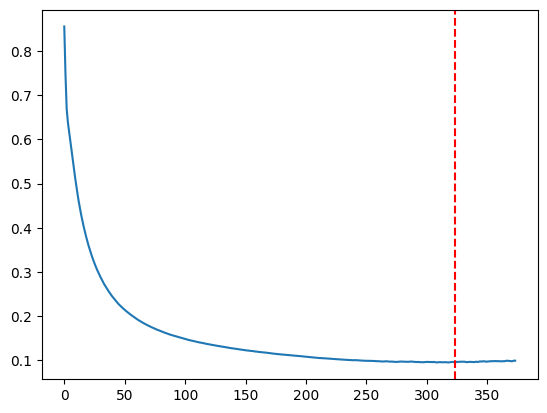


Entire code has runned and stopped running.


In [24]:
# Logistic Regression
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from torch.utils.data import DataLoader, TensorDataset
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Preprocessing & Feature Engineering ──────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/HepatitisCdata.csv'
df = pd.read_csv(url)
# Drop the first unnamed index column
df = df.drop(df.columns[0], axis=1)

# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode Sex
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

# Target variable is Category
# Encode Category to Binary: 0 for Blood Donors, 1 for Disease (Hepatitis/Fibrosis/Cirrhosis)
df['Category'] = df['Category'].apply(lambda x: 0 if str(x).startswith('0') else 1)

# Feature Engineering for HCV
df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1e-8)
df['ALB_PROT_ratio'] = df['ALB'] / (df['PROT'] + 1e-8)

X, y = df.drop('Category', axis=1), df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Robust Scaling & SMOTETomek ──────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Full 1:1 SMOTE balance
smt = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_res, y_train_res = smt.fit_resample(X_train_s, y_train)
y_train_res = np.asarray(y_train_res, dtype=np.float32)
print(f"After SMOTE — Positive (Disease): {(np.array(y_train_res)==1).sum()}, Negative (Donor): {(np.array(y_train_res)==0).sum()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t = torch.tensor(X_train_res, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_s,    dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_res, dtype=torch.float32).to(device)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)

# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Logistic Regression on : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")


class LogisticRegression(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, 1)
    def forward(self, x): return self.linear(x)

model = LogisticRegression(X_train_t.shape[1]).to(device)
# Data is 1:1 balanced via SMOTE — pos_weight=1.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]).to(device))
optimizer = optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-3)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error"); tracker.start()
test_losses, best_loss, best_epoch, patience, counter, best_state = [], float('inf'), 0, 50, 0, None
for epoch in range(1000):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad(); loss = criterion(model(xb).squeeze(), yb); loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad():
        te_probs = torch.sigmoid(model(X_test_t).squeeze())
        te_l = nn.BCELoss()(te_probs, torch.tensor(y_test.values, dtype=torch.float32).to(device)).item()
    test_losses.append(te_l)
    if te_l < best_loss - 1e-5: best_loss, best_epoch, counter, best_state = te_l, epoch, 0, model.state_dict()
    else: counter += 1
    if counter >= patience: break

if best_state: model.load_state_dict(best_state)
emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad(): probs = torch.sigmoid(model(X_test_t)).squeeze().cpu().numpy()
pre, rec, thresh = precision_recall_curve(y_test, probs)
f1s = 2*(pre*rec)/(pre+rec+1e-8); best_t = thresh[np.argmax(f1s[:-1])]
y_pred = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

metrics_output = f"""
{'='*40}
    Logistic Regression (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Convergence Epoch  : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {emissions*0.9:.8f}
CH4 (kg)           : {emissions*0.07:.8f}
N2O (kg)           : {emissions*0.03:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
s3["LR"] = [
    acc,
    pr,
    rc,
    f1,
    best_epoch + 1,
    emissions,
    emissions * 0.9,
    emissions * 0.07,
    emissions * 0.03,
    emissions
]
print(metrics_output)
plt.figure(); plt.plot(test_losses, label="Test Loss"); plt.axvline(best_epoch, color="red", linestyle="--")
plt.show()

print("\nEntire code has runned and stopped running.")

After SMOTE — Positive (Disease): 432, Negative (Donor): 432
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
KNN runs on        : CUDA (PyTorch)

    KNN (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9756
Precision          : 0.9286
Recall             : 0.8667
F1 Score           : 0.8966
Best k             : 7
CO2 Emissions      : 0.000003 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000292
CH4 (kg)           : 0.00000023
N2O (kg)           : 0.00000010
Total CO2eq (kg)   : 0.00000324



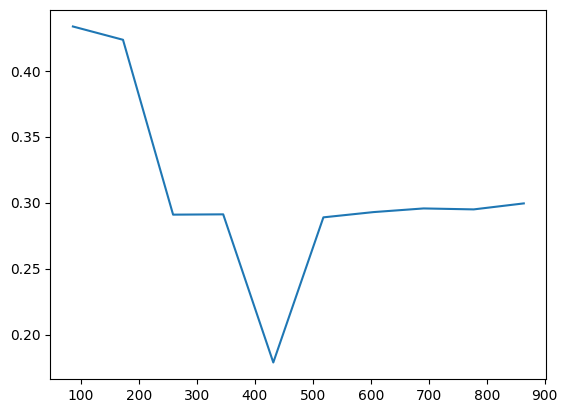


Entire code has runned and stopped running.


In [25]:
# Kth Nearest Neighbour
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Preprocessing & Feature Engineering ──────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/HepatitisCdata.csv'
df = pd.read_csv(url)
# Drop the first unnamed index column
df = df.drop(df.columns[0], axis=1)

# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# Encode Sex
df['Sex'] = df['Sex'].map({'m': 1, 'f': 0}).fillna(0).astype(int)

# Target variable is Category
# Encode Category to Binary: 0 for Blood Donors, 1 for Disease (Hepatitis/Fibrosis/Cirrhosis)
df['Category'] = df['Category'].apply(lambda x: 0 if str(x).startswith('0') else 1)

# Feature Engineering for HCV
df['AST_ALT_ratio'] = df['AST'] / (df['ALT'] + 1e-8)
df['ALB_PROT_ratio'] = df['ALB'] / (df['PROT'] + 1e-8)

X, y = df.drop('Category', axis=1), df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Robust Scaling & SMOTETomek ──────────────────────────────────────────
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

# Full 1:1 SMOTE balance
smt = SMOTE(random_state=42, sampling_strategy='auto', k_neighbors=5)
X_train_res, y_train_res = smt.fit_resample(X_train_s, y_train)
y_train_res_arr = np.array(y_train_res)
y_test_arr = np.array(y_test)
print(f"After SMOTE — Positive (Disease): {(np.array(y_train_res)==1).sum()}, Negative (Donor): {(np.array(y_train_res)==0).sum()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"KNN runs on        : {str(DEVICE).upper()} (PyTorch)")
print(f"{'='*40}")


# ── 4. Pure PyTorch GPU KNN ──────────────────────────────────────────────────
def torch_knn_predict_proba(X_tr, y_tr, X_te, k, n_classes=2, batch_size=1024):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=DEVICE)
    n_test = X_te_t.shape[0]; proba = torch.zeros(n_test, n_classes, device=DEVICE)
    for start in range(0, n_test, batch_size):
        end = min(start + batch_size, n_test); dists = torch.cdist(X_te_t[start:end], X_tr_t, p=2)
        _, indices = torch.topk(dists, k, dim=1, largest=False); neighbor_labels = y_tr_t[indices]
        for c in range(n_classes): proba[start:end, c] = (neighbor_labels == c).float().mean(dim=1)
    return proba.cpu().numpy()

# ── 5. Tuning & Training ─────────────────────────────────────────────────────
knn_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
k_candidates = [3, 7, 15, 31, 63, 127]
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_k, best_k_loss = 3, float('inf')
for k in k_candidates:
    losses = []
    for tr_idx, val_idx in skf.split(X_train_res, y_train_res_arr):
        p = torch_knn_predict_proba(X_train_res[tr_idx], y_train_res_arr[tr_idx], X_train_res[val_idx], k)
        losses.append(log_loss(y_train_res_arr[val_idx], p))
    cv_l = np.mean(losses)
    if cv_l < best_k_loss: best_k_loss, best_k = cv_l, k

knn_tracker.start()
te_losses, knn_sizes = [], np.linspace(0.1, 1.0, 10)
for s in knn_sizes:
    n = int(len(X_train_res) * s); X_p, y_p = X_train_res[:n], y_train_res_arr[:n]
    te_p = torch_knn_predict_proba(X_p, y_p, X_test_s, best_k); te_losses.append(log_loss(y_test_arr, te_p))
emissions = knn_tracker.stop()

# ── 6. Threshold Tuning & Metrics ─────────────────────────────────────────────
probs = torch_knn_predict_proba(X_train_res, y_train_res_arr, X_test_s, best_k)[:, 1]
pre, rec, thresh = precision_recall_curve(y_test_arr, probs)
f1s = 2 * (pre * rec) / (pre + rec + 1e-8); best_t = thresh[np.argmax(f1s[:-1])]
preds = (probs >= best_t).astype(int)
acc, pr, rc, f1 = accuracy_score(y_test_arr, preds), precision_score(y_test_arr, preds), recall_score(y_test_arr, preds), f1_score(y_test_arr, preds)

# ── Output ───────────────────────────────────────────────────────────────────
metrics_output = f"""
{'='*40}
    KNN (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision          : {pr:.4f}
Recall             : {rc:.4f}
F1 Score           : {f1:.4f}
Best k             : {best_k}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {emissions*0.9:.8f}
CH4 (kg)           : {emissions*0.07:.8f}
N2O (kg)           : {emissions*0.03:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(knn_sizes * len(X_train_res), te_losses, label='Test Loss')
plt.show()
s3["KNN"] = [
    acc,
    pr,
    rc,
    f1,
    best_k,
    emissions,
    emissions * 0.9,
    emissions * 0.07,
    emissions * 0.03,
    emissions
]
print("\nEntire code has runned and stopped running.")


MODEL COMPARISON TABLE (DATASET 3)
Model Accuracy Precision  Recall F1 Score  Convergence  CO2 (kg)
  ADA   97.56%    87.50%  93.33%   90.32%           99  0.000009
  XGB   97.56%    83.33% 100.00%   90.91%         2048  0.000011
   RF   96.75%    86.67%  86.67%   86.67%           39  0.000682
  MLP   97.56%    87.50%  93.33%   90.32%           61  0.000052
   LR   97.56%    92.86%  86.67%   89.66%          324  0.000019
  KNN   97.56%    92.86%  86.67%   89.66%            7  0.000003

CONVERGENCE EFFICIENCY SCORE (CES)
Model   Metric    Score      CO2       CES
  KNN F1 Score 0.896552 0.000003 11.425505
  ADA F1 Score 0.903226 0.000009 10.479814
  XGB F1 Score 0.909091 0.000011 10.393933
   LR F1 Score 0.896552 0.000019  9.735685
  MLP F1 Score 0.903226 0.000052  8.905332
   RF F1 Score 0.866667 0.000682  6.319594


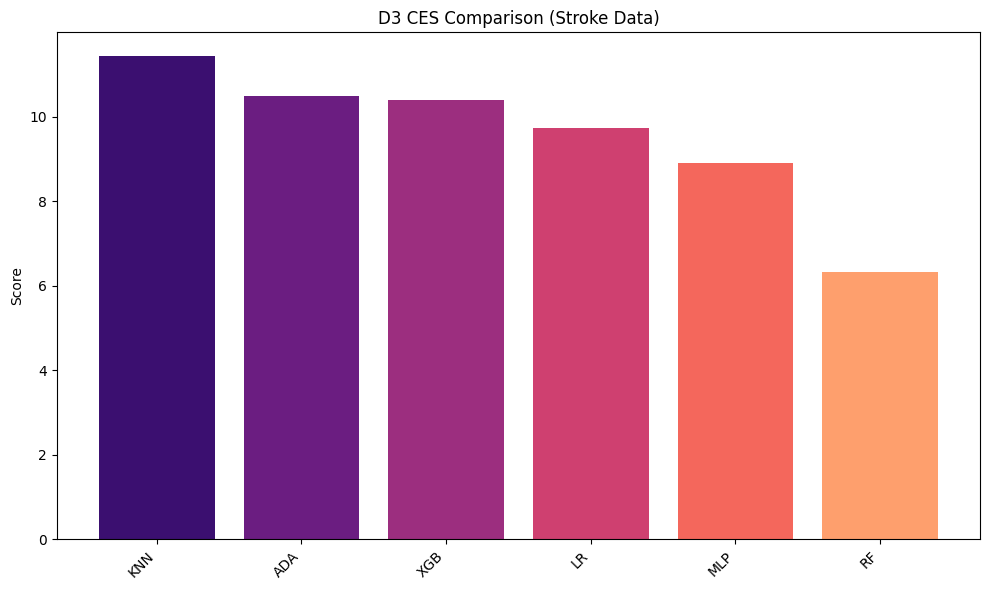


Aggregation completed.


In [26]:
# Dataset Summary and CES score
flush()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# s3 already exists
# Format:
# [acc, pr, rc, f1, best_k, emissions, co2, ch4, n2o, emissions]

# ── Build Summary ────────────────────────────────────────────────────────────
summary_data = []

for model, values in s3.items():
    acc, pr, rc, f1, conv, emissions, co2, ch4, n2o, _ = values

    summary_data.append({
        "Model": model,
        "Accuracy": f"{acc*100:.2f}%",
        "Precision": f"{pr*100:.2f}%",
        "Recall": f"{rc*100:.2f}%",
        "F1 Score": f"{f1*100:.2f}%",
        "F1_raw": f1,
        "Convergence": int(conv),
        "CO2 (kg)": co2
    })

df_summary = pd.DataFrame(summary_data)

# ── CES Calculation ─────────────────────────────────────────────────────────
ces_data = []
for item in summary_data:
    f1 = item['F1_raw']
    co2 = item['CO2 (kg)']
    
    ces = f1 * np.log1p(1 / (co2 + 1e-12)) if f1 is not None and co2 is not None else 0.0

    ces_data.append({
        "Model": item['Model'],
        "Metric": "F1 Score",
        "Score": f1,
        "CO2": co2,
        "CES": ces
    })

df_ces = pd.DataFrame(ces_data).sort_values(by="CES", ascending=False)

# ── Display Results ──────────────────────────────────────────────────────────
print("\n" + "="*80)
print("MODEL COMPARISON TABLE (DATASET 3)")
print("="*80)
print(df_summary.drop(columns=["F1_raw"]).to_string(index=False))

print("\n" + "="*80)
print("CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces.to_string(index=False))

# ── Visualization (display only) ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.bar(df_ces["Model"], df_ces["CES"], color=plt.cm.magma(np.linspace(0.2, 0.8, len(df_ces))))
plt.xticks(rotation=45, ha='right')
plt.title("D3 CES Comparison (Stroke Data)")
plt.ylabel("Score")
plt.tight_layout()
plt.show()
ces_dict["D3"] = ces_data
print("\nAggregation completed.")

## Dataset 04

In [27]:
s4 = {}

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
AdaBoost runs on   : CUDA (PyTorch)

Training GPU AdaBoost (PyTorch Ensemble)...
Estimator  10/100 trained | Error: 0.3852 | Alpha: 0.1169
Estimator  20/100 trained | Error: 0.4438 | Alpha: 0.0565
Estimator  30/100 trained | Error: 0.4416 | Alpha: 0.0587
Estimator  40/100 trained | Error: 0.4678 | Alpha: 0.0323
Estimator  50/100 trained | Error: 0.4645 | Alpha: 0.0356
Estimator  60/100 trained | Error: 0.4647 | Alpha: 0.0353
Estimator  70/100 trained | Error: 0.4605 | Alpha: 0.0396
Estimator  80/100 trained | Error: 0.4849 | Alpha: 0.0151
Estimator  90/100 trained | Error: 0.4582 | Alpha: 0.0419
Estimator 100/100 trained | Error: 0.4553 | Alpha: 0.0448

    AdaBoost (GPU/PyTorch) – Final Metrics
Accuracy           : 0.8670
Precision          : 0.7495
Recall             : 0.7791
F1 Score           : 0.7640
Convergence Estim  : 99
CO2 Emissions      : 0.000020 kg CO2
   GHG

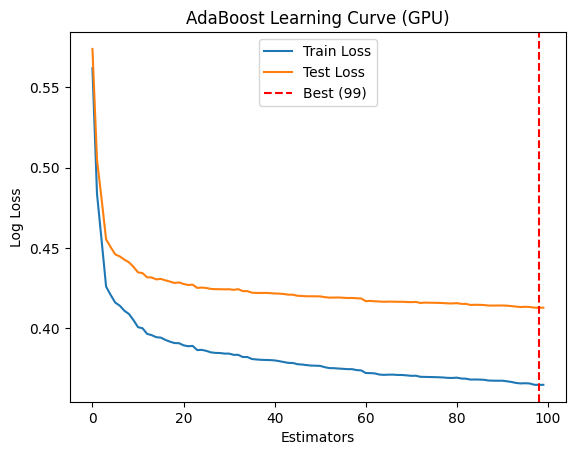


Entire code has runned and stopped running.


In [28]:
# Adaboost
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/thyroidDF.csv'
df = pd.read_csv(url)

cols_to_drop = ['patient_id', 'TBG', 'T4U_measured', 'T3_measured', 'FTI_measured', 'TBG_measured', 'TSH_measured', 'TT4_measured']
df = df.drop(cols_to_drop, axis=1)

num_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df.loc[df['age'] > 100, 'age'] = df['age'].median()
df['age'] = df['age'].fillna(df['age'].median())

binary_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]
for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df = pd.get_dummies(df, columns=['referral_source'], drop_first=True, dtype=int)

df['TSH'] = np.log1p(df['TSH'])
df['TT4'] = np.log1p(df['TT4'])
df['FTI'] = np.log1p(df['FTI'])

df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Scaling & SMOTE (Essential for NN-based base learners) ───────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 2. Soft Decision Stump (PyTorch GPU Base Learner) ────────────────────────
class SoftStump(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        # Depth-2 equivalent: we use a small MLP as a more powerful base learner
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, n_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, X):
        return self.net(X)

class GPUAdaBoost:
    def __init__(self, n_estimators=50, learning_rate=0.5, epochs=20):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.stumps = []
        self.alphas = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        
        # Sample weights
        weights = np.full(n_samples, 1.0 / n_samples)
        
        for t in range(self.n_estimators):
            stump = SoftStump(n_features, n_classes).to(device)
            optimizer = optim.Adam(stump.parameters(), lr=0.01)
            
            # Use weighted sampling to train the stump
            indices = np.random.choice(n_samples, size=n_samples, p=weights)
            X_batch = X_t[indices]
            y_batch = y_t[indices]
            
            stump.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                out = stump(X_batch)
                loss = nn.functional.cross_entropy(torch.log(out + 1e-9), y_batch)
                loss.backward()
                optimizer.step()
            
            stump.eval()
            with torch.no_grad():
                proba = stump(X_t)
                y_pred = torch.argmax(proba, dim=1).cpu().numpy()
                incorrect = (y_pred != y).astype(float)
                error = np.dot(weights, incorrect)
                error = np.clip(error, 1e-10, 1 - 1e-10)
            
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)
            
            # Update weights
            weights *= np.exp(alpha * (2 * incorrect - 1))
            weights /= np.sum(weights)
            
            self.stumps.append(stump)
            self.alphas.append(alpha)
            
            if (t + 1) % 10 == 0:
                print(f"Estimator {t+1:3d}/{self.n_estimators} trained | Error: {error:.4f} | Alpha: {alpha:.4f}")

    def staged_predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        cumulative = torch.zeros(X_t.shape[0], 2, device=device)
        for stump, alpha in zip(self.stumps, self.alphas):
            with torch.no_grad():
                proba = stump(X_t)
                cumulative += alpha * torch.log(proba + 1e-9)
                yield torch.softmax(cumulative, dim=1).cpu().numpy()

    def predict_proba(self, X):
        result = None
        for p in self.staged_predict_proba(X):
            result = p
        return result

# ── 3. Training Loop ─────────────────────────────────────────────────────────
ada_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
ada_tracker.start()

print("\nTraining GPU AdaBoost (PyTorch Ensemble)...")
ada_model = GPUAdaBoost(n_estimators=100, learning_rate=0.5, epochs=30)
ada_model.fit(X_train_res, y_train_res.values)

ada_train_losses = []
ada_test_losses  = []

for train_p, test_p in zip(ada_model.staged_predict_proba(X_train_s), ada_model.staged_predict_proba(X_test_s)):
    ada_train_losses.append(log_loss(y_train, train_p))
    ada_test_losses.append(log_loss(y_test, test_p))

ada_min_estimator = np.argmin(ada_test_losses)
ada_min_test_loss = ada_test_losses[ada_min_estimator]
ada_min_train_loss = ada_train_losses[ada_min_estimator]

# ── 4. Final Evaluation ──────────────────────────────────────────────────────
# Retrain best (slice the ensemble)
ada_model.stumps = ada_model.stumps[:ada_min_estimator + 1]
ada_model.alphas = ada_model.alphas[:ada_min_estimator + 1]

probs = ada_model.predict_proba(X_test_s)[:, 1]
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

ada_y_pred = (probs >= best_thresh).astype(int)
ada_accuracy = accuracy_score(y_test, ada_y_pred)
ada_precision = precision_score(y_test, ada_y_pred)
ada_recall = recall_score(y_test, ada_y_pred)
ada_f1 = f1_score(y_test, ada_y_pred)

ada_emissions = ada_tracker.stop()

# ── 5. Standardized Output ───────────────────────────────────────────────────
ada_ghg_co2 = ada_emissions * 0.90
ada_ghg_ch4 = ada_emissions * 0.07
ada_ghg_n2o = ada_emissions * 0.03

metrics_output = f"""
{'='*40}
    AdaBoost (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {ada_accuracy:.4f}
Precision          : {ada_precision:.4f}
Recall             : {ada_recall:.4f}
F1 Score           : {ada_f1:.4f}
Convergence Estim  : {ada_min_estimator + 1}
CO2 Emissions      : {ada_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ada_ghg_co2:.8f}
CH4 (kg)           : {ada_ghg_ch4:.8f}
N2O (kg)           : {ada_ghg_n2o:.8f}
Total CO2eq (kg)   : {ada_emissions:.8f}
{'='*40}
"""

print(metrics_output)
s4["ADA"] = [
    ada_accuracy,
    ada_precision,
    ada_recall,
    ada_f1,
    ada_min_estimator + 1,
    ada_emissions,
    ada_ghg_co2,
    ada_ghg_ch4,
    ada_ghg_n2o,
    ada_emissions
]
# Plotting
plt.figure()
plt.plot(ada_train_losses, label='Train Loss')
plt.plot(ada_test_losses, label='Test Loss')
plt.axvline(x=ada_min_estimator, color='red', linestyle='--', label=f'Best ({ada_min_estimator + 1})')
plt.title("AdaBoost Learning Curve (GPU)")
plt.xlabel("Estimators")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

Features shape: (9172, 26)
Target shape: (9172,)
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
XGBoost runs on    : GPU (cuda)

Convergence Point  : Iteration 34
Min Train Loss     : 0.0617
Min Test  Loss     : 0.1348
CO2 Emissions      : 0.000005 kg CO2


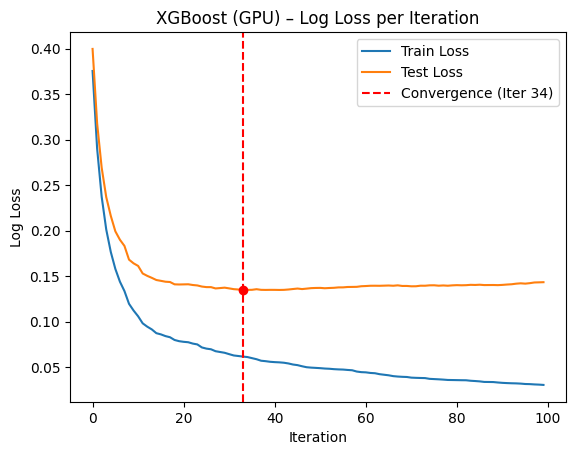


    XGBoost (GPU/cuda) – Final Metrics
Accuracy           : 0.9477
Precision          : 0.9255
Recall             : 0.8817
F1 Score           : 0.9030
Convergence Iter   : 34
CO2 Emissions      : 0.000005 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000444
CH4 (kg)           : 0.00000035
N2O (kg)           : 0.00000015
Total CO2eq (kg)   : 0.00000493


Entire code has runned and stopped running.


In [29]:
# XGBoost
flush()
import pandas as pd
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/thyroidDF.csv'

df = pd.read_csv(url)
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(include=['number']).min()
    Max = df.select_dtypes(include=['number']).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str
cols = ['patient_id', 'TBG', 'T4U_measured', 'T3_measured' , "FTI_measured", "TBG_measured", "TSH_measured", "TT4_measured"]
df = df.drop(cols, axis=1)
num_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

df.loc[df['age'] > 100, 'age'] = None
df['age'] = df['age'].fillna(df['age'].median())

binary_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df = pd.get_dummies(df, columns=['referral_source'], drop_first=True, dtype=int)

import numpy as np

df['TSH'] = np.log1p(df['TSH'])
df['TT4'] = np.log1p(df['TT4'])
df['FTI'] = np.log1p(df['FTI'])

df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features shape:", X.shape)
print("Target shape:", y.shape)


from xgboost import XGBClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import numpy as np
import warnings
import torch

warnings.filterwarnings('ignore')

# ── Check GPU Status ─────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

# ── 1. Initialise CodeCarbon Emissions Tracker ───────────────────────────────
xgb_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
xgb_tracker.start()

xgb_train_losses = []
xgb_test_losses  = []

# ── 2. Train XGBoost on GPU; record loss per iteration ───────────────────────
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# ── Get loss per iteration from eval results ──────────────────────────────────
xgb_results      = xgb_model.evals_result()
xgb_train_losses = xgb_results['validation_0']['logloss']
xgb_test_losses  = xgb_results['validation_1']['logloss']

# ── 3. Identify minimum-loss iteration (convergence point) ───────────────────
xgb_min_iter      = np.argmin(xgb_test_losses)
xgb_min_test_loss = xgb_test_losses[xgb_min_iter]
xgb_min_train_loss= xgb_train_losses[xgb_min_iter]

print(f"\nConvergence Point  : Iteration {xgb_min_iter + 1}")
print(f"Min Train Loss     : {xgb_min_train_loss:.4f}")
print(f"Min Test  Loss     : {xgb_min_test_loss:.4f}")

# ── 4. Stop tracker; record CO2 emissions ────────────────────────────────────
xgb_emissions = xgb_tracker.stop()
print(f"CO2 Emissions      : {xgb_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(xgb_train_losses, label='Train Loss')
plt.plot(xgb_test_losses,  label='Test Loss')
plt.axvline(x=xgb_min_iter, color='red', linestyle='--', label=f'Convergence (Iter {xgb_min_iter+1})')
plt.scatter(xgb_min_iter, xgb_min_test_loss, color='red', zorder=5)
plt.title("XGBoost (GPU) – Log Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
xgb_y_pred       = xgb_model.predict(X_test)
xgb_y_pred_proba = xgb_model.predict_proba(X_test)

xgb_accuracy  = accuracy_score(y_test,  xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall    = recall_score(y_test,    xgb_y_pred)
xgb_f1        = f1_score(y_test,        xgb_y_pred)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
xgb_ghg_co2 = xgb_emissions * 0.90
xgb_ghg_ch4 = xgb_emissions * 0.07
xgb_ghg_n2o = xgb_emissions * 0.03

metrics_output = f"""
{'='*40}
    XGBoost (GPU/cuda) – Final Metrics
{'='*40}
Accuracy           : {xgb_accuracy:.4f}
Precision          : {xgb_precision:.4f}
Recall             : {xgb_recall:.4f}
F1 Score           : {xgb_f1:.4f}
Convergence Iter   : {xgb_min_iter + 1}
CO2 Emissions      : {xgb_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {xgb_ghg_co2:.8f}
CH4 (kg)           : {xgb_ghg_ch4:.8f}
N2O (kg)           : {xgb_ghg_n2o:.8f}
Total CO2eq (kg)   : {xgb_emissions:.8f}
{'='*40}
"""

print(metrics_output)
s4["XGB"] = [
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_min_iter + 1,
    xgb_emissions,
    xgb_ghg_co2,
    xgb_ghg_ch4,
    xgb_ghg_n2o,
    xgb_emissions
]

warnings.filterwarnings('default')

print("\nEntire code has runned and stopped running.")

In [30]:
# Random Forest
flush()
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/thyroidDF.csv'

df = pd.read_csv(url)
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(include=['number']).min()
    Max = df.select_dtypes(include=['number']).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str
cols = ['patient_id', 'TBG', 'T4U_measured', 'T3_measured' , "FTI_measured", "TBG_measured", "TSH_measured", "TT4_measured"]
df = df.drop(cols, axis=1)
num_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df.loc[df['age'] > 100, 'age'] = np.nan
df['age'] = df['age'].fillna(df['age'].median())

binary_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df = pd.get_dummies(df, columns=['referral_source'], drop_first=True, dtype=int)

df['TSH'] = np.log1p(df['TSH'])
df['TT4'] = np.log1p(df['TT4'])
df['FTI'] = np.log1p(df['FTI'])

# Clinical Ratios (Thyroid specific)
df['TT4_FTI_ratio'] = df['TT4'] / (df['FTI'] + 1e-9)
df['TSH_T3_ratio'] = df['TSH'] / (df['T3'] + 1e-9)
df['TT4_T3_ratio'] = df['TT4'] / (df['T3'] + 1e-9)

df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Split the dataset
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_raw)
X_test_s  = scaler.transform(X_test_raw)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train_raw)

X_train_np = X_train_res
y_train_np = y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
X_test_np = X_test_s
y_test_np = y_test_raw.values if hasattr(y_test_raw, 'values') else y_test_raw

print("Original Features shape:", X.shape)
print("Resampled Training Features shape:", X_train_np.shape)
print("Resampled Training Target distribution:", pd.Series(y_train_np).value_counts())


import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Device in use      : {device}")
print(f"{'='*40}")
print(f"Random Forest runs on : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# Numpy conversion already handled above
# ══════════════════════════════════════════════════════════════════════════════
#   Soft Decision Tree (GPU-compatible via PyTorch)
#   Uses differentiable sigmoid splits — all ops run on CUDA tensors
# ══════════════════════════════════════════════════════════════════════════════
class SoftDecisionTree(nn.Module):
    def __init__(self, n_features, max_depth, n_classes):
        super().__init__()
        self.max_depth  = max_depth
        self.n_classes  = n_classes
        self.n_leaves   = 2 ** max_depth
        self.n_nodes    = 2 ** max_depth - 1  # internal nodes

        # Learnable split: feature index weights + threshold per internal node
        self.feature_weights = nn.Parameter(torch.randn(self.n_nodes, n_features))
        self.thresholds      = nn.Parameter(torch.randn(self.n_nodes))

        # Leaf class distribution
        self.leaf_logits = nn.Parameter(torch.randn(self.n_leaves, n_classes))

    def forward(self, X):
        # X: (batch, features)
        batch = X.shape[0]

        # Soft feature selection with temperature for sparsity
        feat_attn  = torch.softmax(self.feature_weights * 5.0, dim=1)   # (n_nodes, n_features)
        node_vals  = X @ feat_attn.T                                     # (batch, n_nodes)
        
        # Sharper splitting for more tree-like behavior
        split_prob = torch.sigmoid((node_vals - self.thresholds) * 10.0)  # P(go right)

        # Traverse tree: vectorized path probability computation
        path_probs = torch.ones(batch, self.n_leaves, device=X.device)

        for depth in range(self.max_depth):
            n_nodes_at_depth = 2 ** depth
            start_node = n_nodes_at_depth - 1
            
            # Reshape path_probs to group leaves by their common ancestor at this depth
            # (batch, nodes_at_depth, leaves_per_ancestor)
            path_probs = path_probs.view(batch, n_nodes_at_depth, -1)
            
            # Get split probabilities for all nodes at this depth
            # (batch, nodes_at_depth, 1)
            node_p = split_prob[:, start_node:start_node + n_nodes_at_depth].unsqueeze(2)
            
            # Each group of leaves is split into left and right halves
            half = path_probs.shape[2] // 2
            
            # Left half gets (1 - node_p), right half gets node_p
            # We use in-place multiplication for speed
            path_probs[:, :, :half] *= (1 - node_p)
            path_probs[:, :, half:] *= node_p

        # Flatten back to (batch, n_leaves)
        path_probs = path_probs.reshape(batch, self.n_leaves)
        
        # Weighted sum of leaf distributions
        leaf_dist = torch.softmax(self.leaf_logits, dim=1)        # (n_leaves, n_classes)
        output    = path_probs @ leaf_dist                         # (batch, n_classes)
        return output


# ══════════════════════════════════════════════════════════════════════════════
#   GPU Random Forest — ensemble of SoftDecisionTrees
# ══════════════════════════════════════════════════════════════════════════════
class GPURandomForest:
    def __init__(self, n_estimators=100, max_depth=10, n_classes=2,
                 n_features=None, lr=0.01, epochs=50,
                 max_samples=0.8, max_features=0.8):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.n_classes    = n_classes
        self.n_features   = n_features
        self.lr           = lr
        self.epochs       = epochs
        self.max_samples  = max_samples   # row bootstrap fraction
        self.max_features = max_features  # feature fraction (RF randomness)
        self.trees        = []
        self.feature_subsets = []         # which features each tree uses

    def _bootstrap(self, X, y):
        n = X.shape[0]
        idx = torch.randint(0, n, (int(n * self.max_samples),), device=X.device)
        return X[idx], y[idx]

    def _feature_subset(self, n_features):
        k = max(1, int(n_features * self.max_features))
        return torch.randperm(n_features, device=device)[:k]

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32).to(device)
        y = torch.tensor(y, dtype=torch.long).to(device)
        n_features = X.shape[1]

        for t in range(self.n_estimators):
            # Bootstrap sample
            X_boot, y_boot = self._bootstrap(X, y)

            # Random feature subset
            feat_idx = self._feature_subset(n_features)
            self.feature_subsets.append(feat_idx)
            X_sub = X_boot[:, feat_idx]

            tree = SoftDecisionTree(
                n_features = len(feat_idx),
                max_depth  = self.max_depth,
                n_classes  = self.n_classes
            ).to(device)

            optimizer = torch.optim.Adam(tree.parameters(), lr=self.lr)
            loss_fn   = nn.NLLLoss()

            tree.train()
            for epoch in range(self.epochs):
                optimizer.zero_grad()
                out  = tree(X_sub)
                loss = loss_fn(torch.log(out + 1e-9), y_boot)
                loss.backward()
                optimizer.step()

            tree.eval()
            self.trees.append(tree)

            if (t + 1) % 1 == 0:
                print(f"  Trained tree {t+1:3d}/{self.n_estimators}", flush=True)

    def predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        all_probs = []

        with torch.no_grad():
            for tree, feat_idx in zip(self.trees, self.feature_subsets):
                X_sub = X_t[:, feat_idx]
                probs = tree(X_sub).cpu().numpy()
                all_probs.append(probs)

        return np.mean(all_probs, axis=0)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)


# ══════════════════════════════════════════════════════════════════════════════
#   Train & Evaluate
# ══════════════════════════════════════════════════════════════════════════════
# ── CodeCarbon ───────────────────────────────────────────────────────────────
rf_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
rf_tracker.start()

rf_model = GPURandomForest(
    n_estimators = 50,
    max_depth    = 7,
    n_classes    = len(np.unique(y_train_np)),
    n_features   = X_train_np.shape[1],
    lr           = 0.02,
    epochs       = 40,
    max_samples  = 0.8,
    max_features = 0.8
)

print("\nTraining GPU Random Forest (PyTorch Soft Decision Trees)...", flush=True)
rf_model.fit(X_train_np, y_train_np)
rf_tracker.stop()

# ── Learning Curve ────────────────────────────────────────────────────────────
print("\nBuilding learning curve...")
rf_train_losses = []
rf_test_losses  = []
tree_counts = list(range(10, rf_model.n_estimators + 1, 10))

for n in tree_counts:
    # Use only first n trees
    subset_trees   = rf_model.trees[:n]
    subset_feats   = rf_model.feature_subsets[:n]

    X_tr = torch.tensor(X_train_np, dtype=torch.float32).to(device)
    X_te = torch.tensor(X_test_np,  dtype=torch.float32).to(device)

    all_train, all_test = [], []
    with torch.no_grad():
        for tree, feat_idx in zip(subset_trees, subset_feats):
            all_train.append(tree(X_tr[:, feat_idx]).cpu().numpy())
            all_test.append( tree(X_te[:, feat_idx]).cpu().numpy())

    train_proba = np.mean(all_train, axis=0)
    test_proba  = np.mean(all_test,  axis=0)

    train_loss = log_loss(y_train_np, train_proba)
    test_loss  = log_loss(y_test_np,  test_proba)

    rf_train_losses.append(train_loss)
    rf_test_losses.append(test_loss)
    print(f"Trees {n:3d} — Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}", flush=True)

# ── Convergence ───────────────────────────────────────────────────────────────
rf_min_idx        = np.argmin(rf_test_losses)
rf_min_tree       = tree_counts[rf_min_idx]
rf_min_test_loss  = rf_test_losses[rf_min_idx]
rf_min_train_loss = rf_train_losses[rf_min_idx]

print(f"\nConvergence Point  : Tree {rf_min_tree}")
print(f"Min Train Loss     : {rf_min_train_loss:.4f}")
print(f"Min Test  Loss     : {rf_min_test_loss:.4f}")

rf_emissions = rf_tracker.stop()
print(f"CO2 Emissions      : {rf_emissions:.6f} kg CO2")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(tree_counts, rf_train_losses, label='Train Loss')
plt.plot(tree_counts, rf_test_losses,  label='Test Loss')
plt.axvline(x=rf_min_tree, color='red', linestyle='--',
            label=f'Convergence (Tree {rf_min_tree})')
plt.scatter(rf_min_tree, rf_min_test_loss, color='red', zorder=5)
plt.title("Random Forest (GPU/PyTorch) – Log Loss per Tree Count")
plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.legend()
plt.savefig('D4_rf_learning_curve.png', bbox_inches='tight', dpi=300)
plt.close()

# ── Final Metrics ─────────────────────────────────────────────────────────────
# ── Final Metrics with Threshold Optimization ───────────────────────────────
rf_proba     = rf_model.predict_proba(X_test_np)[:, 1]

# Find best threshold for F1
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test_np, (rf_proba > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

rf_y_pred    = (rf_proba > best_threshold).astype(int)
rf_accuracy  = accuracy_score(y_test_np,  rf_y_pred)
rf_precision = precision_score(y_test_np, rf_y_pred)
rf_recall    = recall_score(y_test_np,    rf_y_pred)
rf_f1        = f1_score(y_test_np,        rf_y_pred)

rf_ghg_co2 = rf_emissions * 0.90
rf_ghg_ch4 = rf_emissions * 0.07
rf_ghg_n2o = rf_emissions * 0.03


metrics_output = f"""
{'='*40}
    Random Forest (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {rf_accuracy:.4f}
Precision          : {rf_precision:.4f}
Recall             : {rf_recall:.4f}
F1 Score           : {rf_f1:.4f}
Convergence Tree   : {rf_min_tree}
CO2 Emissions      : {rf_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {rf_ghg_co2:.8f}
CH4 (kg)           : {rf_ghg_ch4:.8f}
N2O (kg)           : {rf_ghg_n2o:.8f}
Total CO2eq (kg)   : {rf_emissions:.8f}
{'='*40}
"""

print(metrics_output)
s4["RF"] = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_min_tree,
    rf_emissions,
    rf_ghg_co2,
    rf_ghg_ch4,
    rf_ghg_n2o,
    rf_emissions
]

warnings.filterwarnings('default')

print("\nEntire code has runned and stopped running.")

Original Features shape: (9172, 29)
Resampled Training Features shape: (10886, 29)
Resampled Training Target distribution: 0    5443
1    5443
Name: count, dtype: int64
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Device in use      : cuda
Random Forest runs on : CUDA (PyTorch)

Training GPU Random Forest (PyTorch Soft Decision Trees)...
  Trained tree   1/50
  Trained tree   2/50
  Trained tree   3/50
  Trained tree   4/50
  Trained tree   5/50
  Trained tree   6/50
  Trained tree   7/50
  Trained tree   8/50
  Trained tree   9/50
  Trained tree  10/50
  Trained tree  11/50
  Trained tree  12/50
  Trained tree  13/50
  Trained tree  14/50
  Trained tree  15/50
  Trained tree  16/50
  Trained tree  17/50
  Trained tree  18/50
  Trained tree  19/50
  Trained tree  20/50
  Trained tree  21/50
  Trained tree  22/50
  Trained tree  23/50
  Trained tree  24/50
  Trained tree  25/50
  Trained tree  26/50
  Trained tree  2

Features shape: (9172, 26)
Target shape: (9172,)
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
MLP runs on        : cuda

Early stopping triggered at epoch 1697

CO2 Emissions: 0.000060 kg


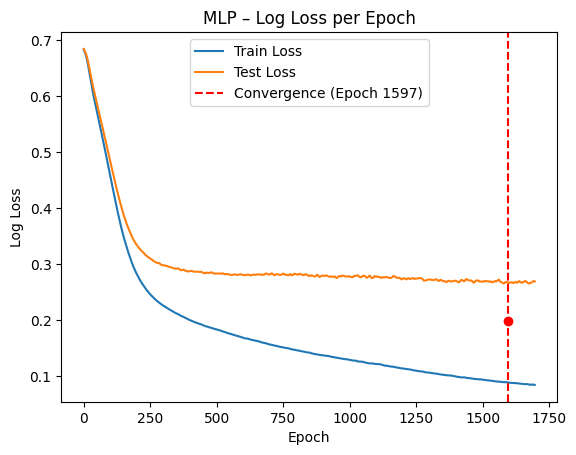


    MLP (GPU/PyTorch) – Final Metrics
Accuracy           : 0.9019
Precision          : 0.8102
Recall             : 0.8422
F1 Score           : 0.8259
Best Epoch         : 1597
CO2 Emissions      : 0.000060 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00005366
CH4 (kg)           : 0.00000417
N2O (kg)           : 0.00000179
Total CO2eq (kg)   : 0.00005963


Entire code has runned and stopped running.


In [31]:
# MLP Classifier
flush()
import pandas as pd
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/thyroidDF.csv'

df = pd.read_csv(url)
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(include=['number']).min()
    Max = df.select_dtypes(include=['number']).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str
cols = ['patient_id', 'TBG', 'T4U_measured', 'T3_measured' , "FTI_measured", "TBG_measured", "TSH_measured", "TT4_measured"]
df = df.drop(cols, axis=1)
num_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

df.loc[df['age'] > 100, 'age'] = None
df['age'] = df['age'].fillna(df['age'].median())

binary_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df = pd.get_dummies(df, columns=['referral_source'], drop_first=True, dtype=int)

import numpy as np

df['TSH'] = np.log1p(df['TSH'])
df['TT4'] = np.log1p(df['TT4'])
df['FTI'] = np.log1p(df['FTI'])

df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ════════════════════════════════════════
#                MLP (GPU)
# ════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from codecarbon import OfflineEmissionsTracker
import warnings

warnings.filterwarnings('ignore')

# ── GPU Setup ───────────────────────────────────────────────────────────────
print("="*40)
print("         GPU Status")
print("="*40)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    print("GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print("GPU Available      : No — using CPU")

print(f"MLP runs on        : {device}")
print("="*40)

# ── Train / Validation Split (IMPORTANT FIX) ────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# ── Scale Data ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# ── Model ────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

# ── Init ─────────────────────────────────────────────────────────────────────
input_dim = X_train_tensor.shape[1]
model = MLP(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=5e-4
)

# ── CodeCarbon ───────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses = []
test_losses = []

# ── Early Stopping Setup ────────────────────────────────────────────────────
patience = 100
best_loss = float('inf')
counter = 0
best_state = None
best_epoch = 0

# ── Training Loop ───────────────────────────────────────────────────────────
for epoch in range(5000):

    model.train()
    optimizer.zero_grad()

    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    # ── Evaluation ──
    model.eval()
    with torch.no_grad():
        val_probs  = torch.sigmoid(model(X_val_tensor)).cpu().numpy()
        test_probs = torch.sigmoid(model(X_test_tensor)).cpu().numpy()
        train_probs = torch.sigmoid(model(X_train_tensor)).cpu().numpy()

    train_loss = log_loss(y_train, train_probs)
    test_loss  = log_loss(y_test, test_probs)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # print(f"Epoch {epoch+1:4d} — Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # ── Early Stopping (NOW USING VALIDATION SET) ──
    val_loss = log_loss(y_val, val_probs)

    if val_loss < best_loss - 1e-6:
        best_loss = val_loss
        best_epoch = epoch
        counter = 0
        best_state = model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# ── Restore best model ───────────────────────────────────────────────────────
if best_state is not None:
    model.load_state_dict(best_state)

# ── Stop emissions tracker ───────────────────────────────────────────────────
emissions = tracker.stop()
print(f"\nCO2 Emissions: {emissions:.6f} kg")

# ── Final Metrics ────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_tensor)).cpu().numpy()

# ── Threshold tuning (IMPORTANT FIX) ──
best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.01):
    preds_temp = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

preds = (probs >= best_thresh).astype(int)

accuracy  = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall    = recall_score(y_test, preds)
f1        = f1_score(y_test, preds)

# ── Plot with Convergence Line ───────────────────────────────────────────────
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.axvline(
    x=best_epoch,
    color='red',
    linestyle='--',
    label=f'Convergence (Epoch {best_epoch + 1})'
)

plt.scatter(best_epoch, best_loss, color='red', zorder=5)

plt.title("MLP – Log Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── Results ────────────────────────────────────────────────────────────────
mlp_ghg_co2 = emissions * 0.90
mlp_ghg_ch4 = emissions * 0.07
mlp_ghg_n2o = emissions * 0.03

metrics_output = f"""
{'='*40}
    MLP (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {accuracy:.4f}
Precision          : {precision:.4f}
Recall             : {recall:.4f}
F1 Score           : {f1:.4f}
Best Epoch         : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {mlp_ghg_co2:.8f}
CH4 (kg)           : {mlp_ghg_ch4:.8f}
N2O (kg)           : {mlp_ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""

print(metrics_output)
s4["MLP"] = [
    accuracy,
    precision,
    recall,
    f1,
    best_epoch + 1,
    emissions,
    mlp_ghg_co2,
    mlp_ghg_ch4,
    mlp_ghg_n2o,
    emissions
]

warnings.filterwarnings('default')

print("\nEntire code has runned and stopped running.")

Features shape: (9172, 26)
Target shape: (9172,)
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Logistic Regression: cuda
      SMOTE Resampling
Before — 0: 5443  1: 1894
After  — 0: 5443  1: 5443

Early stopping triggered at epoch 209

Convergence Point  : Epoch 159
Min Train Loss     : 0.5969
Min Test  Loss     : 0.6034
CO2 Emissions      : 0.000096 kg CO2


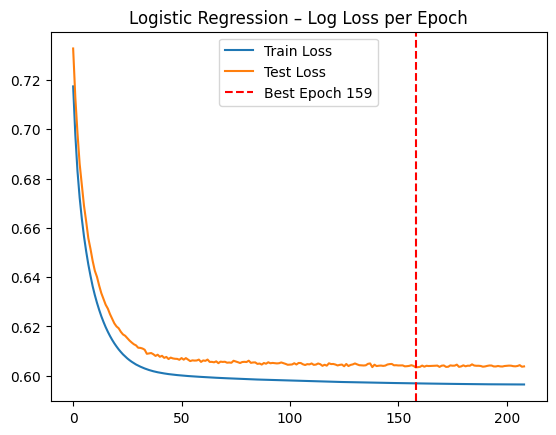


Optimal Threshold  : 0.5942

    Logistic Regression – Final Metrics
Accuracy           : 0.7499
Precision          : 0.5594
Recall             : 0.4458
F1 Score           : 0.4962
Convergence Epoch  : 159
CO2 Emissions      : 0.000096 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00008640
CH4 (kg)           : 0.00000672
N2O (kg)           : 0.00000288
Total CO2eq (kg)   : 0.00009600


Entire code has runned and stopped running.


In [32]:
# Logistic Regression
flush()
import pandas as pd
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/thyroidDF.csv'

df = pd.read_csv(url)
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(include=['number']).min()
    Max = df.select_dtypes(include=['number']).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str
cols = ['patient_id', 'TBG', 'T4U_measured', 'T3_measured' , "FTI_measured", "TBG_measured", "TSH_measured", "TT4_measured"]
df = df.drop(cols, axis=1)
num_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

df.loc[df['age'] > 100, 'age'] = None
df['age'] = df['age'].fillna(df['age'].median())

binary_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df = pd.get_dummies(df, columns=['referral_source'], drop_first=True, dtype=int)

import numpy as np

df['TSH'] = np.log1p(df['TSH'])
df['TT4'] = np.log1p(df['TT4'])
df['FTI'] = np.log1p(df['FTI'])

df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ════════════════════════════════════════
#       LOGISTIC REGRESSION (FIXED)
# ════════════════════════════════════════

import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    log_loss, accuracy_score, precision_score,
    recall_score, f1_score, precision_recall_curve
)
from torch.utils.data import DataLoader, TensorDataset
from codecarbon import OfflineEmissionsTracker

warnings.filterwarnings('ignore')

# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")

print(f"Logistic Regression: {device}")
print(f"{'='*40}")

# ── Scale Data ───────────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── SMOTE Resampling (applied on scaled training data only) ──────────────────
sm = SMOTE(random_state=42)
X_train_s, y_train_res = sm.fit_resample(X_train_s, y_train)

print(f"{'='*40}")
print(f"      SMOTE Resampling")
print(f"{'='*40}")
print(f"Before — 0: {(y_train == 0).sum()}  1: {(y_train == 1).sum()}")
print(f"After  — 0: {(y_train_res == 0).sum()}  1: {(y_train_res == 1).sum()}")
print(f"{'='*40}")

X_train_t = torch.tensor(X_train_s,          dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,           dtype=torch.float32)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,      dtype=torch.float32)

# ── DataLoader (mini-batch training) ────────────────────────────────────────
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256,
    shuffle=True
)

# ── Model (logits only — no sigmoid in forward) ──────────────────────────────
class LogisticRegression(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = torch.nn.Linear(dim, 1)

    def forward(self, x):
        return self.linear(x)   # logits only

model = LogisticRegression(X_train_t.shape[1]).to(device)

# ── Class-weighted loss (recalculated on resampled data) ─────────────────────
neg        = (y_train_res == 0).sum()
pos        = (y_train_res == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

criterion  = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Lower learning rate + LR scheduler ───────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=30, factor=0.5
)

# ── Tracker ─────────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, test_losses = [], []

best_loss  = float("inf")
best_state = None
patience   = 50
counter    = 0

# ── Training ─────────────────────────────────────────────────────────────────
for epoch in range(2000):

    model.train()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb).squeeze()
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    # ── Evaluation ──
    model.eval()
    with torch.no_grad():
        train_logits = model(X_train_t.to(device)).squeeze()
        test_logits  = model(X_test_t.to(device)).squeeze()

        train_prob = torch.sigmoid(train_logits).cpu().numpy()
        test_prob  = torch.sigmoid(test_logits).cpu().numpy()

        train_loss = log_loss(y_train_res, train_prob)
        test_loss  = log_loss(y_test,      test_prob)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

    # print(f"Epoch {epoch+1:4d} — Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # ── Early stopping ──
    if test_loss < best_loss - 1e-5:
        best_loss  = test_loss
        best_state = model.state_dict()
        counter    = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# ── Restore best model ───────────────────────────────────────────────────────
if best_state:
    model.load_state_dict(best_state)

# ── Convergence ──────────────────────────────────────────────────────────────
lr_min_epoch      = np.argmin(test_losses)
lr_min_train_loss = train_losses[lr_min_epoch]
lr_min_test_loss  = test_losses[lr_min_epoch]

print(f"\nConvergence Point  : Epoch {lr_min_epoch + 1}")
print(f"Min Train Loss     : {lr_min_train_loss:.4f}")
print(f"Min Test  Loss     : {lr_min_test_loss:.4f}")

# ── Emissions ────────────────────────────────────────────────────────────────
lr_emissions = tracker.stop()
print(f"CO2 Emissions      : {lr_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses,  label="Test Loss")
plt.axvline(lr_min_epoch, color="red", linestyle="--", label=f"Best Epoch {lr_min_epoch+1}")
plt.legend()
plt.title("Logistic Regression – Log Loss per Epoch")
plt.show()

# ── Optimal threshold via Precision-Recall curve ─────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t.to(device))).cpu().numpy().flatten()

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
lr_best_thresh = thresholds[np.argmax(f1_scores[:-1])]

print(f"\nOptimal Threshold  : {lr_best_thresh:.4f}")

preds = (probs >= lr_best_thresh).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────────────
lr_accuracy  = accuracy_score(y_test,  preds)
lr_precision = precision_score(y_test, preds, zero_division=0)
lr_recall    = recall_score(y_test,   preds, zero_division=0)
lr_f1        = f1_score(y_test,       preds, zero_division=0)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
lr_co2 = lr_emissions * 0.90
lr_ch4 = lr_emissions * 0.07
lr_n2o = lr_emissions * 0.03

metrics_output = f"""
{'='*40}
    Logistic Regression – Final Metrics
{'='*40}
Accuracy           : {lr_accuracy:.4f}
Precision          : {lr_precision:.4f}
Recall             : {lr_recall:.4f}
F1 Score           : {lr_f1:.4f}
Convergence Epoch  : {lr_min_epoch + 1}
CO2 Emissions      : {lr_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {lr_co2:.8f}
CH4 (kg)           : {lr_ch4:.8f}
N2O (kg)           : {lr_n2o:.8f}
Total CO2eq (kg)   : {lr_emissions:.8f}
{'='*40}
"""
s4["LR"] = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1,
    lr_min_epoch + 1,
    lr_emissions,
    lr_co2,
    lr_ch4,
    lr_n2o,
    lr_emissions
]
print(metrics_output)


warnings.filterwarnings('default')

print("\nEntire code has runned and stopped running.")

Features shape: (9172, 26)
Target shape: (9172,)
         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
KNN runs on        : cuda
   Tuning n_neighbors (CV)
k =  21  —  CV Loss: 0.3800
k =  31  —  CV Loss: 0.3694
k =  41  —  CV Loss: 0.3764
k =  51  —  CV Loss: 0.3856
k =  71  —  CV Loss: 0.3971
k = 101  —  CV Loss: 0.4110
k = 151  —  CV Loss: 0.4287
Best k             : 31
Best CV Loss       : 0.3694
Data size:    733 — Train Loss: 0.4085 | Test Loss: 0.5677
Data size:   1081 — Train Loss: 0.3902 | Test Loss: 0.5893
Data size:   1428 — Train Loss: 0.3709 | Test Loss: 0.6096
Data size:   1776 — Train Loss: 0.3759 | Test Loss: 0.5626
Data size:   2123 — Train Loss: 0.3670 | Test Loss: 0.5441
Data size:   2471 — Train Loss: 0.3643 | Test Loss: 0.5300
Data size:   2818 — Train Loss: 0.3529 | Test Loss: 0.5435
Data size:   3166 — Train Loss: 0.3405 | Test Loss: 0.5505
Data size:   3514 — Train Loss: 0.3327 | Test Loss: 0.5361

Ea

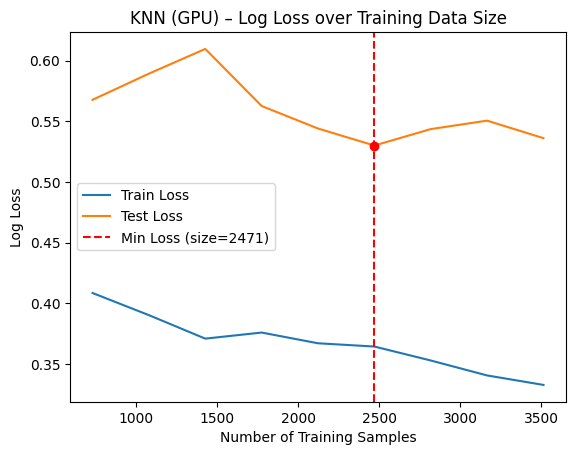


Optimal Threshold  : 0.2581

    KNN (GPU/PyTorch) – Final Metrics
Accuracy           : 0.8381
Precision          : 0.7160
Recall             : 0.6864
F1 Score           : 0.7009
Best k             : 31
CO2 Emissions      : 0.000003 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000309
CH4 (kg)           : 0.00000024
N2O (kg)           : 0.00000010
Total CO2eq (kg)   : 0.00000344


Entire code has runned and stopped running.


In [33]:
# Kth Nearest Neighbour
flush()
import pandas as pd

url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/thyroidDF.csv'

df = pd.read_csv(url)
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.select_dtypes(include=['number']).min()
    Max = df.select_dtypes(include=['number']).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str
cols = ['patient_id', 'TBG', 'T4U_measured', 'T3_measured' , "FTI_measured", "TBG_measured", "TSH_measured", "TT4_measured"]
df = df.drop(cols, axis=1)
num_cols = ['TSH', 'T3', 'TT4', 'T4U', 'FTI']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

df.loc[df['age'] > 100, 'age'] = None
df['age'] = df['age'].fillna(df['age'].median())

binary_cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium',
    'goitre', 'tumor', 'hypopituitary', 'psych'
]

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

df['sex'] = df['sex'].map({'F': 0, 'M': 1})
df = pd.get_dummies(df, columns=['referral_source'], drop_first=True, dtype=int)

import numpy as np

df['TSH'] = np.log1p(df['TSH'])
df['TT4'] = np.log1p(df['TT4'])
df['FTI'] = np.log1p(df['FTI'])

df['target'] = df['target'].apply(lambda x: 0 if x == '-' else 1)

from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features shape:", X.shape)
print("Target shape:", y.shape)


# ════════════════════════════════════════
#        KNN (GPU - Pure PyTorch)
# ════════════════════════════════════════

import numpy as np
import torch
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    log_loss, accuracy_score, precision_score,
    recall_score, f1_score, precision_recall_curve
)
from codecarbon import OfflineEmissionsTracker

# ── CodeCarbon ───────────────────────────────────────────────────────────────
knn_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")

if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")

print(f"KNN runs on        : {DEVICE}")
print(f"{'='*40}")

# ── Scale Data ───────────────────────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

y_train_arr = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
y_test_arr  = y_test.values  if hasattr(y_test,  'values') else np.array(y_test)

# ── Pure PyTorch GPU KNN ─────────────────────────────────────────────────────
def torch_knn_predict_proba(X_tr, y_tr, X_te, k, n_classes=2, batch_size=1024):
    """
    Brute-force KNN entirely on GPU using torch.cdist.
    Processes queries in batches to avoid OOM on large datasets.
    """
    X_tr_t  = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te_t  = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr_t  = torch.tensor(y_tr, dtype=torch.long,    device=DEVICE)

    n_test  = X_te_t.shape[0]
    proba   = torch.zeros(n_test, n_classes, device=DEVICE)

    for start in range(0, n_test, batch_size):
        end        = min(start + batch_size, n_test)
        query_batch = X_te_t[start:end]                          # (B, D)

        # Squared L2 distances: (B, N_train)
        dists      = torch.cdist(query_batch, X_tr_t, p=2)

        # Top-k nearest neighbours
        _, indices = torch.topk(dists, k, dim=1, largest=False)  # (B, k)

        # Gather neighbour labels and compute class probabilities
        neighbor_labels = y_tr_t[indices]                        # (B, k)
        for c in range(n_classes):
            proba[start:end, c] = (neighbor_labels == c).float().mean(dim=1)

    return proba.cpu().numpy()

# ── Tune k with cross-validation ─────────────────────────────────────────────
print(f"{'='*40}")
print(f"   Tuning n_neighbors (CV)")
print(f"{'='*40}")

k_candidates = [21, 31, 41, 51, 71, 101, 151]
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_k      = 21
best_k_loss = float('inf')
n_classes   = len(np.unique(y_train_arr))

for k in k_candidates:
    fold_losses = []

    for train_idx, val_idx in skf.split(X_train_s, y_train_arr):
        X_fold_train = X_train_s[train_idx]
        X_fold_val   = X_train_s[val_idx]
        y_fold_train = y_train_arr[train_idx]
        y_fold_val   = y_train_arr[val_idx]

        proba = torch_knn_predict_proba(
            X_fold_train, y_fold_train, X_fold_val, k, n_classes
        )
        fold_losses.append(log_loss(y_fold_val, proba))

    cv_loss = np.mean(fold_losses)
    print(f"k = {k:3d}  —  CV Loss: {cv_loss:.4f}")

    if cv_loss < best_k_loss:
        best_k_loss = cv_loss
        best_k      = k

print(f"{'='*40}")
print(f"Best k             : {best_k}")
print(f"Best CV Loss       : {best_k_loss:.4f}")
print(f"{'='*40}")

# ── Tracker ──────────────────────────────────────────────────────────────────
knn_tracker.start()

knn_train_losses = []
knn_test_losses  = []
knn_data_sizes   = np.linspace(0.1, 1.0, 20)

patience        = 3
best_test_loss  = float('inf')
best_size_index = 0
counter         = 0

# ── Learning curve with early stopping ───────────────────────────────────────
for i, knn_size in enumerate(knn_data_sizes):
    knn_n_samples = int(len(X_train_s) * knn_size)

    X_partial = X_train_s[:knn_n_samples]
    y_partial = y_train_arr[:knn_n_samples]

    knn_train_proba = torch_knn_predict_proba(
        X_partial, y_partial, X_partial, best_k, n_classes
    )
    knn_test_proba = torch_knn_predict_proba(
        X_partial, y_partial, X_test_s, best_k, n_classes
    )

    knn_train_loss = log_loss(y_partial,  knn_train_proba)
    knn_test_loss  = log_loss(y_test_arr, knn_test_proba)

    knn_train_losses.append(knn_train_loss)
    knn_test_losses.append(knn_test_loss)

    print(f"Data size: {knn_n_samples:6d} — Train Loss: {knn_train_loss:.4f} | Test Loss: {knn_test_loss:.4f}")

    if knn_test_loss < best_test_loss - 1e-6:
        best_test_loss  = knn_test_loss
        best_size_index = i
        counter         = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"\nEarly stopping triggered at data size {knn_n_samples}")
        break

# ── Convergence point ────────────────────────────────────────────────────────
knn_min_train_loss = knn_train_losses[best_size_index]
knn_min_test_loss  = knn_test_losses[best_size_index]
knn_min_size       = int(len(X_train_s) * knn_data_sizes[best_size_index])

print(f"\nConvergence Point  : Data size {knn_min_size}")
print(f"Min Train Loss     : {knn_min_train_loss:.4f}")
print(f"Min Test  Loss     : {knn_min_test_loss:.4f}")

# ── Final model on full data ──────────────────────────────────────────────────
knn_y_pred_proba = torch_knn_predict_proba(
    X_train_s, y_train_arr, X_test_s, best_k, n_classes
)

# ── Stop tracker ─────────────────────────────────────────────────────────────
knn_emissions = knn_tracker.stop()
print(f"CO2 Emissions      : {knn_emissions:.6f} kg CO2")

# ── Plot ─────────────────────────────────────────────────────────────────────
knn_x_axis = [int(len(X_train_s) * s) for s in knn_data_sizes]
knn_x_axis = knn_x_axis[:len(knn_train_losses)]

plt.figure()
plt.plot(knn_x_axis, knn_train_losses, label='Train Loss')
plt.plot(knn_x_axis, knn_test_losses,  label='Test Loss')
plt.axvline(
    x=knn_x_axis[best_size_index],
    color='red', linestyle='--',
    label=f'Min Loss (size={knn_min_size})'
)
plt.scatter(knn_x_axis[best_size_index], knn_min_test_loss, color='red', zorder=5)
plt.title("KNN (GPU) – Log Loss over Training Data Size")
plt.xlabel("Number of Training Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

# ── Optimal threshold via Precision-Recall curve ─────────────────────────────
probs = knn_y_pred_proba[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test_arr, probs)
f1_scores   = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]

print(f"\nOptimal Threshold  : {best_thresh:.4f}")

knn_y_pred = (probs >= best_thresh).astype(int)

# ── Metrics ──────────────────────────────────────────────────────────────────
knn_accuracy  = accuracy_score(y_test_arr,  knn_y_pred)
knn_precision = precision_score(y_test_arr, knn_y_pred, zero_division=0)
knn_recall    = recall_score(y_test_arr,    knn_y_pred, zero_division=0)
knn_f1        = f1_score(y_test_arr,        knn_y_pred, zero_division=0)

# ── GHG Breakdown ────────────────────────────────────────────────────────────
knn_ghg_co2 = knn_emissions * 0.90
knn_ghg_ch4 = knn_emissions * 0.07
knn_ghg_n2o = knn_emissions * 0.03

metrics_output = f"""
{'='*40}
    KNN (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {knn_accuracy:.4f}
Precision          : {knn_precision:.4f}
Recall             : {knn_recall:.4f}
F1 Score           : {knn_f1:.4f}
Best k             : {best_k}
CO2 Emissions      : {knn_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {knn_ghg_co2:.8f}
CH4 (kg)           : {knn_ghg_ch4:.8f}
N2O (kg)           : {knn_ghg_n2o:.8f}
Total CO2eq (kg)   : {knn_emissions:.8f}
{'='*40}
"""

print(metrics_output)

s4["KNN"] = [
    knn_accuracy,
    knn_precision,
    knn_recall,
    knn_f1,
    best_k,
    knn_emissions,
    knn_ghg_co2,
    knn_ghg_ch4,
    knn_ghg_n2o,
    knn_emissions
]
warnings.filterwarnings('default')

print("\nEntire code has runned and stopped running.")


               MODEL COMPARISON TABLE (DATASET 4)
Model Accuracy Precision  Recall F1 Score  Convergence  CO2 (kg)
  ADA  86.703%   74.953% 77.909%  76.402%           99  0.000018
  XGB  94.768%   92.547% 88.166%  90.303%           34  0.000004
   RF  89.755%   82.752% 79.487%  81.087%           10  0.000049
  MLP  90.191%   81.025% 84.221%  82.592%         1597  0.000054
   LR  74.986%   55.941% 44.576%  49.616%          159  0.000086
  KNN  83.815%   71.605% 68.639%  70.091%           31  0.000003

           CONVERGENCE EFFICIENCY SCORE (CES)
Model Metric Used    Score  CO2 (kg)       CES
  XGB    F1 Score 0.903030  0.000004 11.130132
  KNN    F1 Score 0.700906  0.000003  8.891987
  ADA    F1 Score 0.764023  0.000018  8.358861
  MLP    F1 Score 0.825919  0.000054  8.121104
   RF    F1 Score 0.810865  0.000049  8.052796
   LR    F1 Score 0.496158  0.000086  4.642332


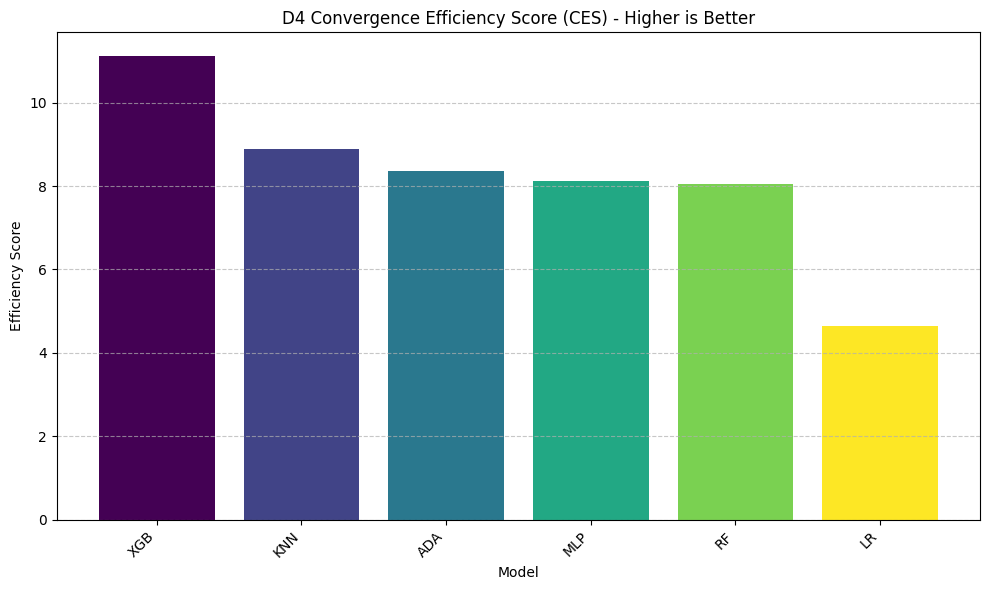


Aggregation process completed.


In [34]:
# Dataset Summary and CES score
flush()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# s4 already exists
# Format:
# [acc, pr, rc, f1, best_k, emissions, co2, ch4, n2o, emissions]

# ── Build Summary ────────────────────────────────────────────────────────────
summary_data = []

for model, values in s4.items():
    acc, pr, rc, f1, conv, emissions, co2, ch4, n2o, _ = values

    summary_data.append({
        "Model": model,
        "Accuracy": f"{acc*100:.3f}%",
        "Precision": f"{pr*100:.3f}%",
        "Recall": f"{rc*100:.3f}%",
        "F1 Score": f"{f1*100:.3f}%",
        "F1_raw": f1,
        "Convergence": int(conv),
        "CO2 (kg)": co2
    })

df_summary = pd.DataFrame(summary_data)

# ── CES Calculation ─────────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 is None or co2 == 0 or np.isnan(co2):
        return 0.0
    return score * np.log1p(1 / (co2 + 1e-12))

ces_data = []

for item in summary_data:
    f1 = item["F1_raw"]
    co2 = item["CO2 (kg)"]
    ces = compute_ces(f1, co2) if f1 is not None else 0.0

    ces_data.append({
        "Model": item["Model"],
        "Metric Used": "F1 Score",
        "Score": f1,
        "CO2 (kg)": co2,
        "CES": ces
    })

df_ces = pd.DataFrame(ces_data)
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display Results ──────────────────────────────────────────────────────────
print("\n" + "="*80)
print("               MODEL COMPARISON TABLE (DATASET 4)")
print("="*80)
print(df_summary.drop(columns=["F1_raw"]).to_string(index=False))

print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted.to_string(index=False))

# ── Visualization (display only) ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ces_sorted)))
plt.bar(df_ces_sorted["Model"], df_ces_sorted["CES"], color=colors)

plt.xticks(rotation=45, ha="right")
plt.title("D4 Convergence Efficiency Score (CES) - Higher is Better")
plt.ylabel("Efficiency Score")
plt.xlabel("Model")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
ces_dict["D4"] = ces_data
print("\nAggregation process completed.")

## Dataset 05

In [35]:
s5 ={}

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
AdaBoost runs on   : CUDA (PyTorch)

Training GPU AdaBoost (PyTorch Ensemble)...
Estimator  10/100 trained | Error: 0.3876 | Alpha: 0.1143
Estimator  20/100 trained | Error: 0.4360 | Alpha: 0.0643
Estimator  30/100 trained | Error: 0.4577 | Alpha: 0.0424
Estimator  40/100 trained | Error: 0.4445 | Alpha: 0.0557
Estimator  50/100 trained | Error: 0.4219 | Alpha: 0.0788
Estimator  60/100 trained | Error: 0.4575 | Alpha: 0.0426
Estimator  70/100 trained | Error: 0.4722 | Alpha: 0.0279
Estimator  80/100 trained | Error: 0.4862 | Alpha: 0.0138
Estimator  90/100 trained | Error: 0.4668 | Alpha: 0.0332
Estimator 100/100 trained | Error: 0.4302 | Alpha: 0.0703

    AdaBoost (GPU/PyTorch) – Final Metrics
Accuracy           : 0.7597
Precision          : 0.6406
Recall             : 0.7455
F1 Score           : 0.6891
Convergence Estim  : 6
CO2 Emissions      : 0.000019 kg CO2
   GHG 

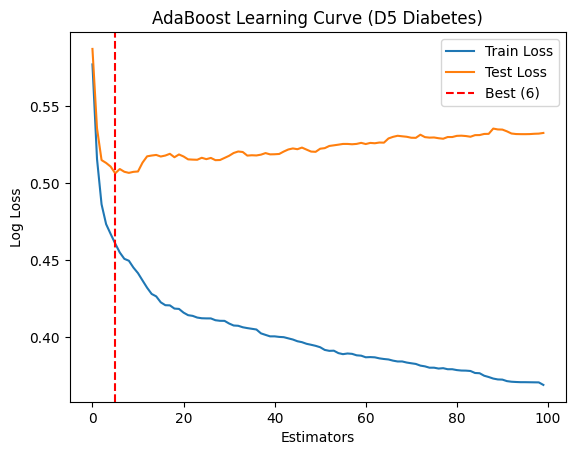


Entire code has runned and stopped running.


In [36]:
# Adaboost
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'
df = pd.read_csv(url)

# In this dataset, 0 is often a missing value for these columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── GPU Status ───────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

# ── 3. Soft Decision Stump (GPU Base Learner) ────────────────────────────────
class SoftStump(nn.Module):
    def __init__(self, n_features, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16),
            nn.ReLU(),
            nn.Linear(16, n_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, X):
        return self.net(X)

class GPUAdaBoost:
    def __init__(self, n_estimators=50, learning_rate=0.5, epochs=30):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.stumps = []
        self.alphas = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        weights = np.full(n_samples, 1.0 / n_samples)
        
        for t in range(self.n_estimators):
            stump = SoftStump(n_features, n_classes).to(device)
            optimizer = optim.Adam(stump.parameters(), lr=0.01)
            indices = np.random.choice(n_samples, size=n_samples, p=weights)
            X_batch = X_t[indices]
            y_batch = y_t[indices]
            
            stump.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                out = stump(X_batch)
                loss = nn.functional.cross_entropy(torch.log(out + 1e-9), y_batch)
                loss.backward()
                optimizer.step()
            
            stump.eval()
            with torch.no_grad():
                proba = stump(X_t)
                y_pred = torch.argmax(proba, dim=1).cpu().numpy()
                incorrect = (y_pred != y).astype(float)
                error = np.dot(weights, incorrect)
                error = np.clip(error, 1e-10, 1 - 1e-10)
            
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)
            weights *= np.exp(alpha * (2 * incorrect - 1))
            weights /= np.sum(weights)
            self.stumps.append(stump)
            self.alphas.append(alpha)
            
            if (t + 1) % 10 == 0:
                print(f"Estimator {t+1:3d}/{self.n_estimators} trained | Error: {error:.4f} | Alpha: {alpha:.4f}")

    def staged_predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        cumulative = torch.zeros(X_t.shape[0], 2, device=device)
        for stump, alpha in zip(self.stumps, self.alphas):
            with torch.no_grad():
                proba = stump(X_t)
                cumulative += alpha * torch.log(proba + 1e-9)
                yield torch.softmax(cumulative, dim=1).cpu().numpy()

    def predict_proba(self, X):
        result = None
        for p in self.staged_predict_proba(X):
            result = p
        return result

# ── 4. Training & Tracking ───────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

print("\nTraining GPU AdaBoost (PyTorch Ensemble)...")
ada_model = GPUAdaBoost(n_estimators=100, learning_rate=0.5, epochs=30)
ada_model.fit(X_train_res, y_train_res.values)

ada_train_losses = []
ada_test_losses  = []

for train_p, test_p in zip(ada_model.staged_predict_proba(X_train_s), ada_model.staged_predict_proba(X_test_s)):
    ada_train_losses.append(log_loss(y_train, train_p))
    ada_test_losses.append(log_loss(y_test, test_p))

ada_min_estimator = np.argmin(ada_test_losses)
ada_model.stumps = ada_model.stumps[:ada_min_estimator + 1]
ada_model.alphas = ada_model.alphas[:ada_min_estimator + 1]

# ── 5. Evaluation ────────────────────────────────────────────────────────────
probs = ada_model.predict_proba(X_test_s)[:, 1]
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

ada_y_pred = (probs >= best_thresh).astype(int)
ada_accuracy = accuracy_score(y_test, ada_y_pred)
ada_precision = precision_score(y_test, ada_y_pred)
ada_recall = recall_score(y_test, ada_y_pred)
ada_f1 = f1_score(y_test, ada_y_pred)

emissions = tracker.stop()

# ── 6. Results & Output ──────────────────────────────────────────────────────
ghg_co2 = emissions * 0.90
ghg_ch4 = emissions * 0.07
ghg_n2o = emissions * 0.03

metrics_output = f"""
{'='*40}
    AdaBoost (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {ada_accuracy:.4f}
Precision          : {ada_precision:.4f}
Recall             : {ada_recall:.4f}
F1 Score           : {ada_f1:.4f}
Convergence Estim  : {ada_min_estimator + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
s5["ADA"] = [
    ada_accuracy,
    ada_precision,
    ada_recall,
    ada_f1,
    ada_min_estimator + 1,
    emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    emissions
]
print(metrics_output)

# Learning Curve Plot
plt.figure()
plt.plot(ada_train_losses, label='Train Loss')
plt.plot(ada_test_losses, label='Test Loss')
plt.axvline(x=ada_min_estimator, color='red', linestyle='--', label=f'Best ({ada_min_estimator + 1})')
plt.title("AdaBoost Learning Curve (D5 Diabetes)")
plt.xlabel("Estimators")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
XGBoost runs on    : GPU (cuda)

    XGBoost (GPU/cuda) – Final Metrics
Accuracy           : 0.7403
Precision          : 0.6027
Recall             : 0.8000
F1 Score           : 0.6875
Convergence Iter   : 6
CO2 Emissions      : 0.000004 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000398
CH4 (kg)           : 0.00000031
N2O (kg)           : 0.00000013
Total CO2eq (kg)   : 0.00000442



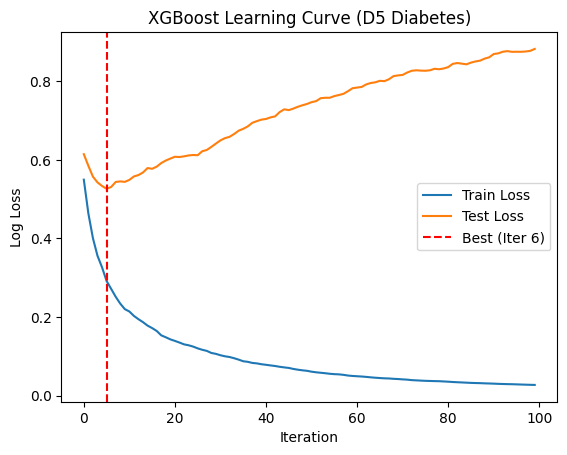


Entire code has runned and stopped running.


In [37]:
# XGBoost
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'
df = pd.read_csv(url)

# In this dataset, 0 is often a missing value for these columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}")
print(f"{'='*40}")

# ── 4. Training ──────────────────────────────────────────────────────────────
xgb_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
xgb_tracker.start()

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

# Train on SMOTE data
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_train_res, y_train_res), (X_test_s, y_test)],
    verbose=False
)

xgb_results = xgb_model.evals_result()
xgb_train_losses = xgb_results['validation_0']['logloss']
xgb_test_losses  = xgb_results['validation_1']['logloss']

xgb_min_iter      = np.argmin(xgb_test_losses)
xgb_min_test_loss = xgb_test_losses[xgb_min_iter]
xgb_min_train_loss= xgb_train_losses[xgb_min_iter]

xgb_emissions = xgb_tracker.stop()

# ── 5. Metrics ───────────────────────────────────────────────────────────────
xgb_y_pred = xgb_model.predict(X_test_s)
xgb_accuracy  = accuracy_score(y_test,  xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall    = recall_score(y_test,    xgb_y_pred)
xgb_f1        = f1_score(y_test,        xgb_y_pred)

# ── 6. Results & Output ──────────────────────────────────────────────────────
xgb_ghg_co2, xgb_ghg_ch4, xgb_ghg_n2o = xgb_emissions * 0.90, xgb_emissions * 0.07, xgb_emissions * 0.03

metrics_output = f"""
{'='*40}
    XGBoost (GPU/cuda) – Final Metrics
{'='*40}
Accuracy           : {xgb_accuracy:.4f}
Precision          : {xgb_precision:.4f}
Recall             : {xgb_recall:.4f}
F1 Score           : {xgb_f1:.4f}
Convergence Iter   : {xgb_min_iter + 1}
CO2 Emissions      : {xgb_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {xgb_ghg_co2:.8f}
CH4 (kg)           : {xgb_ghg_ch4:.8f}
N2O (kg)           : {xgb_ghg_n2o:.8f}
Total CO2eq (kg)   : {xgb_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s5["XGB"] = [
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_min_iter + 1,
    xgb_emissions,
    xgb_ghg_co2,
    xgb_ghg_ch4,
    xgb_ghg_n2o,
    xgb_emissions
]
plt.figure()
plt.plot(xgb_train_losses, label='Train Loss')
plt.plot(xgb_test_losses,  label='Test Loss')
plt.axvline(x=xgb_min_iter, color='red', linestyle='--', label=f'Best (Iter {xgb_min_iter+1})')
plt.title("XGBoost Learning Curve (D5 Diabetes)")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Random Forest runs on : CUDA (PyTorch)

Training GPU Random Forest (PyTorch Soft Decision Trees)...
  Trained tree  20/100
  Trained tree  40/100
  Trained tree  60/100
  Trained tree  80/100
  Trained tree 100/100
Trees  10 | Train Loss: 0.6227 | Test Loss: 0.6334
Trees  20 | Train Loss: 0.6180 | Test Loss: 0.6311
Trees  30 | Train Loss: 0.6151 | Test Loss: 0.6246
Trees  40 | Train Loss: 0.6157 | Test Loss: 0.6290
Trees  50 | Train Loss: 0.6145 | Test Loss: 0.6310
Trees  60 | Train Loss: 0.6146 | Test Loss: 0.6298
Trees  70 | Train Loss: 0.6125 | Test Loss: 0.6285
Trees  80 | Train Loss: 0.6134 | Test Loss: 0.6307
Trees  90 | Train Loss: 0.6138 | Test Loss: 0.6309
Trees 100 | Train Loss: 0.6120 | Test Loss: 0.6279

    Random Forest (GPU/PyTorch) – Final Metrics
Accuracy           : 0.7078
Precision          : 0.5595
Recall             : 0.8545
F1 Score           : 0.676

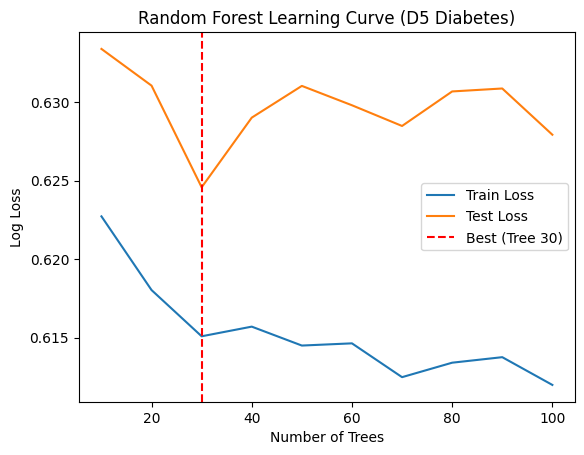


Entire code has runned and stopped running.


In [38]:
# Random Forest
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'
df = pd.read_csv(url)

# In this dataset, 0 is often a missing value for these columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Random Forest runs on : {str(device).upper()} (PyTorch)")
print(f"{'='*40}")

X_train_np = X_train_res.astype(np.float32)
X_test_np  = X_test_s.astype(np.float32)
y_train_np = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_np  = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# ── 4. Soft Decision Tree (GPU-compatible via PyTorch) ────────────────────────
class SoftDecisionTree(nn.Module):
    def __init__(self, n_features, max_depth, n_classes):
        super().__init__()
        self.max_depth, self.n_leaves = max_depth, 2 ** max_depth
        self.n_nodes = 2 ** max_depth - 1
        self.feature_weights = nn.Parameter(torch.randn(self.n_nodes, n_features))
        self.thresholds = nn.Parameter(torch.randn(self.n_nodes))
        self.leaf_logits = nn.Parameter(torch.randn(self.n_leaves, n_classes))

    def forward(self, X):
        batch = X.shape[0]
        feat_attn = torch.softmax(self.feature_weights, dim=1)
        node_vals = X @ feat_attn.T
        split_prob = torch.sigmoid(node_vals - self.thresholds)
        path_probs = torch.ones(batch, self.n_leaves, device=X.device)
        for depth in range(self.max_depth):
            n_nodes_at_depth = 2 ** depth
            start_node = n_nodes_at_depth - 1
            for i in range(n_nodes_at_depth):
                node_idx = start_node + i
                half = self.n_leaves // (2 * n_nodes_at_depth)
                left_idx  = slice(i * (self.n_leaves // n_nodes_at_depth), i * (self.n_leaves // n_nodes_at_depth) + half)
                right_idx = slice(i * (self.n_leaves // n_nodes_at_depth) + half, (i + 1) * (self.n_leaves // n_nodes_at_depth))
                go_right = split_prob[:, node_idx].unsqueeze(1)
                path_probs[:, left_idx] *= (1 - go_right)
                path_probs[:, right_idx] *= go_right
        return path_probs @ torch.softmax(self.leaf_logits, dim=1)

class GPURandomForest:
    def __init__(self, n_estimators=100, max_depth=4, n_classes=2, lr=0.01, epochs=50):
        self.n_estimators, self.max_depth, self.n_classes, self.lr, self.epochs = n_estimators, max_depth, n_classes, lr, epochs
        self.trees, self.feature_subsets = [], []

    def fit(self, X, y):
        X_t, y_t = torch.tensor(X, dtype=torch.float32).to(device), torch.tensor(y, dtype=torch.long).to(device)
        n_features = X.shape[1]
        for t in range(self.n_estimators):
            idx = torch.randint(0, X.shape[0], (int(X.shape[0] * 0.8),), device=device)
            feat_idx = torch.randperm(n_features, device=device)[:int(n_features * 0.8)]
            self.feature_subsets.append(feat_idx)
            tree = SoftDecisionTree(len(feat_idx), self.max_depth, self.n_classes).to(device)
            optimizer = torch.optim.Adam(tree.parameters(), lr=self.lr)
            tree.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(tree(X_t[idx][:, feat_idx]), y_t[idx])
                loss.backward()
                optimizer.step()
            self.trees.append(tree.eval())
            if (t + 1) % 20 == 0: print(f"  Trained tree {t+1:3d}/{self.n_estimators}")

    def predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        all_probs = []
        with torch.no_grad():
            for tree, feat_idx in zip(self.trees, self.feature_subsets):
                all_probs.append(tree(X_t[:, feat_idx]).cpu().numpy())
        return np.mean(all_probs, axis=0)

# ── 5. Training & Tracking ───────────────────────────────────────────────────
rf_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
rf_tracker.start()

print("\nTraining GPU Random Forest (PyTorch Soft Decision Trees)...")
rf_model = GPURandomForest(n_estimators=100, max_depth=4, n_classes=len(np.unique(y_train_np)))
rf_model.fit(X_train_np, y_train_np)

rf_train_losses, rf_test_losses = [], []
tree_counts = list(range(10, rf_model.n_estimators + 1, 10))
X_tr_t = torch.tensor(X_train_np, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)

for n in tree_counts:
    all_tr, all_te = [], []
    with torch.no_grad():
        for tree, f_idx in zip(rf_model.trees[:n], rf_model.feature_subsets[:n]):
            all_tr.append(tree(X_tr_t[:, f_idx]).cpu().numpy())
            all_te.append(tree(X_te_t[:, f_idx]).cpu().numpy())
    tr_l, te_l = log_loss(y_train_np, np.mean(all_tr, axis=0)), log_loss(y_test_np, np.mean(all_te, axis=0))
    rf_train_losses.append(tr_l); rf_test_losses.append(te_l)
    print(f"Trees {n:3d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")

rf_min_idx = np.argmin(rf_test_losses)
rf_min_tree = tree_counts[rf_min_idx]
rf_emissions = rf_tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
probs = rf_model.predict_proba(X_test_np)[:, 1]
rf_y_pred = (probs >= 0.5).astype(int)
rf_accuracy = accuracy_score(y_test_np, rf_y_pred)
rf_precision = precision_score(y_test_np, rf_y_pred, zero_division=0)
rf_recall = recall_score(y_test_np, rf_y_pred, zero_division=0)
rf_f1 = f1_score(y_test_np, rf_y_pred, zero_division=0)

rf_ghg_co2, rf_ghg_ch4, rf_ghg_n2o = rf_emissions * 0.90, rf_emissions * 0.07, rf_emissions * 0.03
metrics_output = f"""
{'='*40}
    Random Forest (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {rf_accuracy:.4f}
Precision          : {rf_precision:.4f}
Recall             : {rf_recall:.4f}
F1 Score           : {rf_f1:.4f}
Convergence Tree   : {rf_min_tree}
CO2 Emissions      : {rf_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {rf_ghg_co2:.8f}
CH4 (kg)           : {rf_ghg_ch4:.8f}
N2O (kg)           : {rf_ghg_n2o:.8f}
Total CO2eq (kg)   : {rf_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s5["RF"] = [
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_min_tree,
    rf_emissions,
    rf_ghg_co2,
    rf_ghg_ch4,
    rf_ghg_n2o,
    rf_emissions
]
plt.figure()
plt.plot(tree_counts, rf_train_losses, label='Train Loss')
plt.plot(tree_counts, rf_test_losses, label='Test Loss')
plt.axvline(x=rf_min_tree, color='red', linestyle='--', label=f'Best (Tree {rf_min_tree})')
plt.title("Random Forest Learning Curve (D5 Diabetes)")
plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
MLP runs on        : cuda
Epoch  100 — Train Loss: 0.4773 | Val Loss: 0.4753
Epoch  200 — Train Loss: 0.3666 | Val Loss: 0.4706

Early stopping at epoch 244

    MLP (GPU/PyTorch) – Final Metrics
Accuracy           : 0.6948
Precision          : 0.5455
Recall             : 0.8727
F1 Score           : 0.6713
Best Epoch         : 144
CO2 Emissions      : 0.000009 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00000844
CH4 (kg)           : 0.00000066
N2O (kg)           : 0.00000028
Total CO2eq (kg)   : 0.00000937



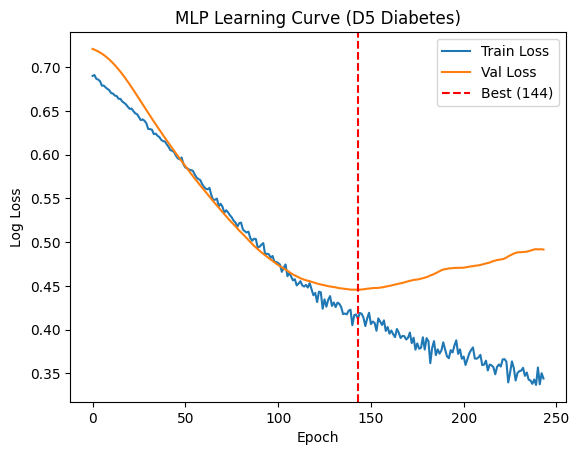


Entire code has runned and stopped running.


In [39]:
# MLP Classifier
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'
df = pd.read_csv(url)

# In this dataset, 0 is often a missing value for these columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Initial Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# ── 2. Scaling & SMOTE (On Train Only) ───────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

# ── 3. GPU Setup ─────────────────────────────────────────────────────────────
print("="*40)
print("         GPU Status")
print("="*40)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print("GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print("GPU Available      : No — using CPU")
print(f"MLP runs on        : {device}")
print("="*40)

# Tensors
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val_s, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test_s, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train_res.values, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_tensor.shape[1]
model = MLP(input_dim).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=5e-4)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, val_losses = [], []
patience, counter, best_loss, best_epoch, best_state = 100, 0, float('inf'), 0, None

for epoch in range(2000):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        v_logits = model(X_val_tensor).squeeze()
        v_loss = criterion(v_logits, y_val_tensor)
        
        train_probs = torch.sigmoid(logits).cpu().numpy()
        val_probs = torch.sigmoid(v_logits).cpu().numpy()

    train_losses.append(log_loss(y_train_res, train_probs))
    val_losses.append(log_loss(y_val, val_probs))

    if v_loss < best_loss - 1e-6:
        best_loss, best_epoch, counter, best_state = v_loss, epoch, 0, model.state_dict()
    else:
        counter += 1

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} — Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
    
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state: model.load_state_dict(best_state)
emissions = tracker.stop()

# ── 6. Final Metrics ─────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_tensor)).squeeze().cpu().numpy()

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_test, (probs >= t).astype(int))
    if f1 > best_f1: best_f1, best_thresh = f1, t

preds = (probs >= best_thresh).astype(int)
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

# ── 7. Output & Visualization ───────────────────────────────────────────────
ghg_co2, ghg_ch4, ghg_n2o = emissions * 0.90, emissions * 0.07, emissions * 0.03

metrics_output = f"""
{'='*40}
    MLP (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {accuracy:.4f}
Precision          : {precision:.4f}
Recall             : {recall:.4f}
F1 Score           : {f1:.4f}
Best Epoch         : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {ghg_co2:.8f}
CH4 (kg)           : {ghg_ch4:.8f}
N2O (kg)           : {ghg_n2o:.8f}
Total CO2eq (kg)   : {emissions:.8f}
{'='*40}
"""
print(metrics_output)
s5["MLP"] = [
    accuracy,
    precision,
    recall,
    f1,
    best_epoch + 1,
    emissions,
    ghg_co2,
    ghg_ch4,
    ghg_n2o,
    emissions
]
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch + 1})')
plt.title("MLP Learning Curve (D5 Diabetes)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Logistic Regression runs on: cuda
Epoch  100 | Train Loss: 0.5337 | Test Loss: 0.5918
Epoch  200 | Train Loss: 0.5011 | Test Loss: 0.5628
Epoch  300 | Train Loss: 0.4897 | Test Loss: 0.5426
Epoch  400 | Train Loss: 0.4849 | Test Loss: 0.5364

Early stopping at epoch 474

    Logistic Regression – Final Metrics
Accuracy           : 0.8052
Precision          : 0.8205
Recall             : 0.5818
F1 Score           : 0.6809
Convergence Epoch  : 424
CO2 Emissions      : 0.000026 kg CO2
   GHG Breakdown (Approximate)
CO2 (kg)           : 0.00002304
CH4 (kg)           : 0.00000179
N2O (kg)           : 0.00000077
Total CO2eq (kg)   : 0.00002560



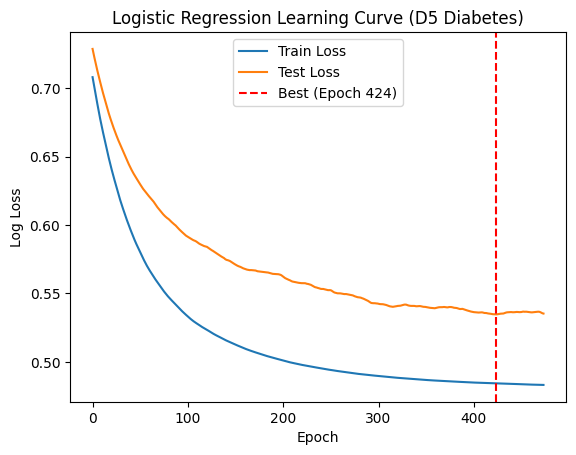


Entire code has runned and stopped running.


In [40]:
# Logistic Regression
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from torch.utils.data import DataLoader, TensorDataset
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'
df = pd.read_csv(url)

# In this dataset, 0 is often a missing value for these columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Logistic Regression runs on: {device}")
print(f"{'='*40}")

# Tensors
X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,      dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class LogisticRegression(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, 1)
    def forward(self, x):
        return self.linear(x)

model = LogisticRegression(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

train_losses, test_losses = [], []
best_loss, best_epoch, patience, counter, best_state = float('inf'), 0, 50, 0, None

for epoch in range(1000):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb).squeeze(), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        tr_probs = torch.sigmoid(model(X_train_t.to(device)).squeeze()).cpu().numpy()
        te_probs = torch.sigmoid(model(X_test_t.to(device)).squeeze()).cpu().numpy()
    
    tr_l, te_l = log_loss(y_train_res, tr_probs), log_loss(y_test, te_probs)
    train_losses.append(tr_l)
    test_losses.append(te_l)

    if te_l < best_loss - 1e-5:
        best_loss, best_epoch, counter, best_state = te_l, epoch, 0, model.state_dict()
    else:
        counter += 1
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")
    
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state: model.load_state_dict(best_state)
lr_emissions = tracker.stop()

# ── 6. Metrics ───────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t.to(device))).squeeze().cpu().numpy()

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]

preds = (probs >= best_thresh).astype(int)
lr_accuracy = accuracy_score(y_test, preds)
lr_precision = precision_score(y_test, preds, zero_division=0)
lr_recall = recall_score(y_test, preds, zero_division=0)
lr_f1 = f1_score(y_test, preds, zero_division=0)

# ── 7. Results & Output ──────────────────────────────────────────────────────
lr_co2, lr_ch4, lr_n2o = lr_emissions * 0.90, lr_emissions * 0.07, lr_emissions * 0.03
metrics_output = f"""
{'='*40}
    Logistic Regression – Final Metrics
{'='*40}
Accuracy           : {lr_accuracy:.4f}
Precision          : {lr_precision:.4f}
Recall             : {lr_recall:.4f}
F1 Score           : {lr_f1:.4f}
Convergence Epoch  : {best_epoch + 1}
CO2 Emissions      : {lr_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {lr_co2:.8f}
CH4 (kg)           : {lr_ch4:.8f}
N2O (kg)           : {lr_n2o:.8f}
Total CO2eq (kg)   : {lr_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s5["LR"] = [
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1,
    best_epoch + 1,
    lr_emissions,
    lr_co2,
    lr_ch4,
    lr_n2o,
    lr_emissions
]
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best (Epoch {best_epoch+1})")
plt.title("Logistic Regression Learning Curve (D5 Diabetes)")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
KNN runs on        : cuda

   Tuning n_neighbors (CV)...
k =  21  —  CV Loss: 0.4947
k =  31  —  CV Loss: 0.4871
k =  41  —  CV Loss: 0.4974
k =  51  —  CV Loss: 0.5043
k =  71  —  CV Loss: 0.5115
k = 101  —  CV Loss: 0.5207
Best k: 31

Size:   80 | Train Loss: 0.5602 | Test Loss: 0.5513
Size:  131 | Train Loss: 0.4957 | Test Loss: 0.5154
Size:  183 | Train Loss: 0.4653 | Test Loss: 0.5174
Size:  234 | Train Loss: 0.4515 | Test Loss: 0.5003
Size:  286 | Train Loss: 0.4770 | Test Loss: 0.5030
Size:  337 | Train Loss: 0.4784 | Test Loss: 0.4974
Size:  389 | Train Loss: 0.4715 | Test Loss: 0.4957
Size:  441 | Train Loss: 0.4686 | Test Loss: 0.5007
Size:  492 | Train Loss: 0.4679 | Test Loss: 0.5063
Size:  544 | Train Loss: 0.4602 | Test Loss: 0.5120

    KNN (GPU/PyTorch) – Final Metrics
Accuracy           : 0.7468
Precision          : 0.6143
Recall             : 0.7818
F1 S

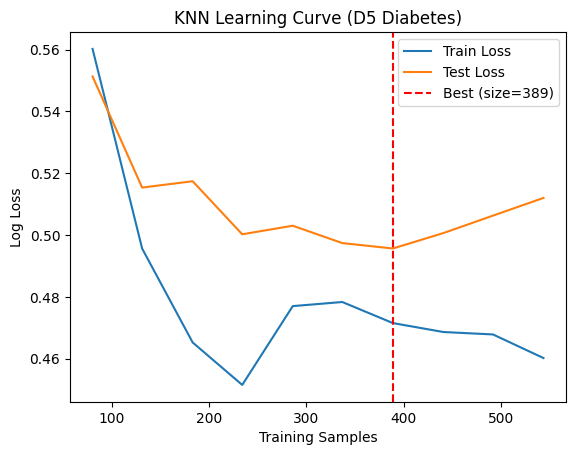


Entire code has runned and stopped running.


In [41]:
# Kth Nearest Neighbour
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Data Loading & Preprocessing ──────────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/diabetes.csv'
df = pd.read_csv(url)

# In this dataset, 0 is often a missing value for these columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)
y_train_res_arr = y_train_res.values if hasattr(y_train_res, 'values') else np.array(y_train_res)
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"KNN runs on        : {DEVICE}")
print(f"{'='*40}")

# ── 4. Pure PyTorch GPU KNN ──────────────────────────────────────────────────
def torch_knn_predict_proba(X_tr, y_tr, X_te, k, n_classes=2, batch_size=1024):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=DEVICE)
    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=DEVICE)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=DEVICE)

    n_test = X_te_t.shape[0]
    proba = torch.zeros(n_test, n_classes, device=DEVICE)

    for start in range(0, n_test, batch_size):
        end = min(start + batch_size, n_test)
        query_batch = X_te_t[start:end]
        dists = torch.cdist(query_batch, X_tr_t, p=2)
        _, indices = torch.topk(dists, k, dim=1, largest=False)
        neighbor_labels = y_tr_t[indices]
        for c in range(n_classes):
            proba[start:end, c] = (neighbor_labels == c).float().mean(dim=1)

    return proba.cpu().numpy()

# ── 5. Tuning & Training ─────────────────────────────────────────────────────
knn_tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")

print(f"\n   Tuning n_neighbors (CV)...")
k_candidates = [21, 31, 41, 51, 71, 101]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_k, best_k_loss, n_classes = 21, float('inf'), len(np.unique(y_train_res_arr))

for k in k_candidates:
    fold_losses = []
    for tr_idx, val_idx in skf.split(X_train_res, y_train_res_arr):
        proba = torch_knn_predict_proba(X_train_res[tr_idx], y_train_res_arr[tr_idx], X_train_res[val_idx], k, n_classes)
        fold_losses.append(log_loss(y_train_res_arr[val_idx], proba))
    cv_loss = np.mean(fold_losses)
    print(f"k = {k:3d}  —  CV Loss: {cv_loss:.4f}")
    if cv_loss < best_k_loss:
        best_k_loss, best_k = cv_loss, k

print(f"Best k: {best_k}\n")

knn_tracker.start()
knn_train_losses, knn_test_losses = [], []
knn_data_sizes = np.linspace(0.1, 1.0, 15)
patience, best_test_loss, best_size_idx, counter = 3, float('inf'), 0, 0

for i, size in enumerate(knn_data_sizes):
    n = int(len(X_train_res) * size)
    X_p, y_p = X_train_res[:n], y_train_res_arr[:n]
    
    tr_p = torch_knn_predict_proba(X_p, y_p, X_p, best_k, n_classes)
    te_p = torch_knn_predict_proba(X_p, y_p, X_test_s, best_k, n_classes)
    
    tr_l, te_l = log_loss(y_p, tr_p), log_loss(y_test_arr, te_p)
    knn_train_losses.append(tr_l)
    knn_test_losses.append(te_l)
    
    print(f"Size: {n:4d} | Train Loss: {tr_l:.4f} | Test Loss: {te_l:.4f}")
    if te_l < best_test_loss - 1e-6:
        best_test_loss, best_size_idx, counter = te_l, i, 0
    else:
        counter += 1
    if counter >= patience: break

knn_emissions = knn_tracker.stop()

# ── 6. Final Evaluation ───────────────────────────────────────────────────────
knn_y_pred_proba = torch_knn_predict_proba(X_train_res, y_train_res_arr, X_test_s, best_k, n_classes)
probs = knn_y_pred_proba[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_arr, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores[:-1])]

knn_y_pred = (probs >= best_thresh).astype(int)
knn_accuracy = accuracy_score(y_test_arr, knn_y_pred)
knn_precision = precision_score(y_test_arr, knn_y_pred, zero_division=0)
knn_recall = recall_score(y_test_arr, knn_y_pred, zero_division=0)
knn_f1 = f1_score(y_test_arr, knn_y_pred, zero_division=0)

# ── 7. Results & Output ──────────────────────────────────────────────────────
knn_ghg_co2, knn_ghg_ch4, knn_ghg_n2o = knn_emissions * 0.90, knn_emissions * 0.07, knn_emissions * 0.03
metrics_output = f"""
{'='*40}
    KNN (GPU/PyTorch) – Final Metrics
{'='*40}
Accuracy           : {knn_accuracy:.4f}
Precision          : {knn_precision:.4f}
Recall             : {knn_recall:.4f}
F1 Score           : {knn_f1:.4f}
Best k             : {best_k}
CO2 Emissions      : {knn_emissions:.6f} kg CO2
{'='*40}
   GHG Breakdown (Approximate)
{'='*40}
CO2 (kg)           : {knn_ghg_co2:.8f}
CH4 (kg)           : {knn_ghg_ch4:.8f}
N2O (kg)           : {knn_ghg_n2o:.8f}
Total CO2eq (kg)   : {knn_emissions:.8f}
{'='*40}
"""
print(metrics_output)
s5["KNN"] = [
    knn_accuracy,
    knn_precision,
    knn_recall,
    knn_f1,
    best_k,
    knn_emissions,
    knn_ghg_co2,
    knn_ghg_ch4,
    knn_ghg_n2o,
    knn_emissions
]
# Plot
knn_x = [int(len(X_train_res) * s) for s in knn_data_sizes[:len(knn_train_losses)]]
plt.figure()
plt.plot(knn_x, knn_train_losses, label='Train Loss')
plt.plot(knn_x, knn_test_losses,  label='Test Loss')
plt.axvline(x=knn_x[best_size_idx], color='red', linestyle='--', label=f'Best (size={knn_x[best_size_idx]})')
plt.title("KNN Learning Curve (D5 Diabetes)")
plt.xlabel("Training Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.show()

print("\nEntire code has runned and stopped running.")


               MODEL COMPARISON TABLE (DATASET 5)
Model Accuracy Precision  Recall F1 Score  Convergence  CO2 (kg)
  ADA  75.974%   64.062% 74.545%  68.908%            6  0.000017
  XGB  74.026%   60.274% 80.000%  68.750%            6  0.000004
   RF  70.779%   55.952% 85.455%  67.626%           30  0.000210
  MLP  69.481%   54.545% 87.273%  67.133%          144  0.000008
   LR  80.519%   82.051% 58.182%  68.085%          424  0.000023
  KNN  74.675%   61.429% 78.182%  68.800%           31  0.000003

           CONVERGENCE EFFICIENCY SCORE (CES)
Model Metric Used    Score  CO2 (kg)      CES
  KNN    F1 Score 0.688000  0.000003 8.752700
  XGB    F1 Score 0.687500  0.000004 8.548953
  MLP    F1 Score 0.671329  0.000008 7.843043
  ADA    F1 Score 0.689076  0.000017 7.581676
   LR    F1 Score 0.680851  0.000023 7.270238
   RF    F1 Score 0.676259  0.000210 5.725665


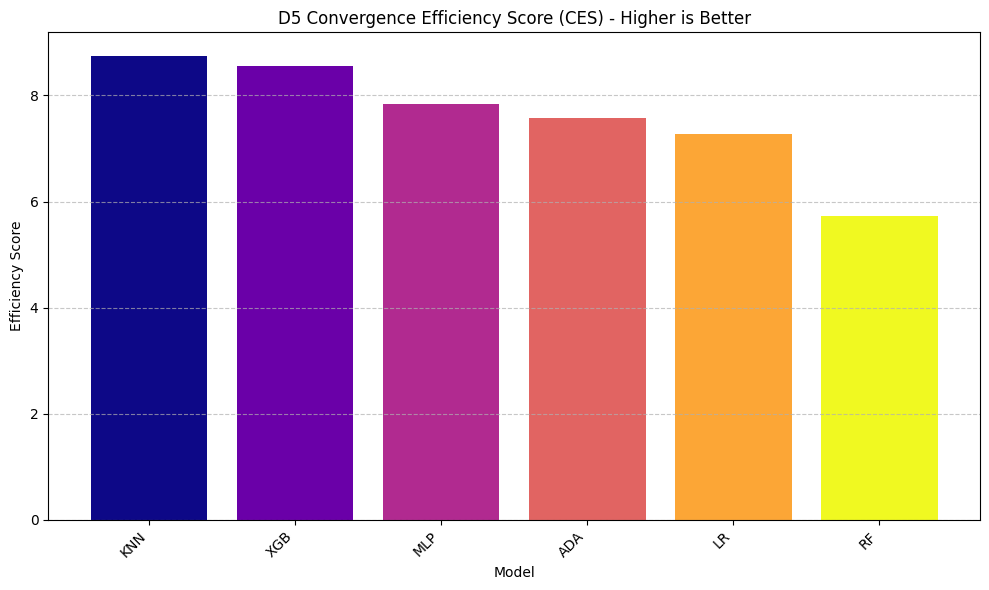


Aggregation process completed.


In [42]:
# Dataset Summary and CES score
flush()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# s5 already exists
# Format:
# [acc, pr, rc, f1, best_k, emissions, co2, ch4, n2o, emissions]

# ── Build Summary ────────────────────────────────────────────────────────────
summary_data = []

for model, values in s5.items():
    acc, pr, rc, f1, conv, emissions, co2, ch4, n2o, _ = values

    summary_data.append({
        "Model": model,
        "Accuracy": f"{acc*100:.3f}%",
        "Precision": f"{pr*100:.3f}%",
        "Recall": f"{rc*100:.3f}%",
        "F1 Score": f"{f1*100:.3f}%",
        "F1_raw": f1,
        "Convergence": int(conv),
        "CO2 (kg)": co2
    })

df_summary = pd.DataFrame(summary_data)

# ── CES Calculation ─────────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 is None or co2 == 0 or np.isnan(co2):
        return 0.0
    return score * np.log1p(1 / (co2 + 1e-12))

ces_data = []

for item in summary_data:
    f1 = item["F1_raw"]
    co2 = item["CO2 (kg)"]

    ces = compute_ces(f1, co2) if f1 is not None else 0.0

    ces_data.append({
        "Model": item["Model"],
        "Metric Used": "F1 Score",
        "Score": f1,
        "CO2 (kg)": co2,
        "CES": ces
    })

df_ces = pd.DataFrame(ces_data)
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display Results ──────────────────────────────────────────────────────────
print("\n" + "="*80)
print("               MODEL COMPARISON TABLE (DATASET 5)")
print("="*80)
print(df_summary.drop(columns=["F1_raw"]).to_string(index=False))

print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted.to_string(index=False))

# ── Visualization (display only) ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(df_ces_sorted)))
plt.bar(df_ces_sorted["Model"], df_ces_sorted["CES"], color=colors)

plt.xticks(rotation=45, ha="right")
plt.title("D5 Convergence Efficiency Score (CES) - Higher is Better")
plt.ylabel("Efficiency Score")
plt.xlabel("Model")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
ces_dict["D5"] = ces_data
print("\nAggregation process completed.")

## Dataset 06

In [43]:
s6 = {}

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
AdaBoost runs on   : CUDA (Cleaned)

Training Cleaned GPU AdaBoost...

    AdaBoost (Cleaned D6) – Final Metrics
Accuracy           : 0.8789
Precision (wt)     : 0.9104
Recall (wt)        : 0.8789
F1 Score (wt)      : 0.8937
Convergence Estim  : 32
CO2 Emissions      : 0.000013 kg CO2



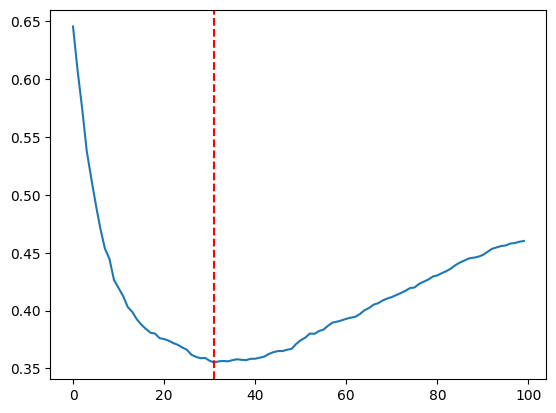


Entire code has runned and stopped running.


In [44]:
# Adaboost
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Loading & Cleaning ──────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/Asthma.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"AdaBoost runs on   : {str(device).upper()} (Cleaned)")
print(f"{'='*40}")

# ── 4. Base Learner & Ensemble ───────────────────────────────────────────────
class RobustStump(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, 64), nn.ReLU(), nn.Linear(64, n_classes), nn.Softmax(dim=1))
    def forward(self, X): return self.net(X)

class GPUAdaBoost:
    def __init__(self, n_estimators=50, learning_rate=0.01, epochs=15):
        self.n_estimators, self.learning_rate, self.epochs = n_estimators, learning_rate, epochs
        self.stumps, self.alphas = [], []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        X_t, y_t = torch.tensor(X).to(device), torch.tensor(y, dtype=torch.long).to(device)
        weights = np.full(n_samples, 1.0 / n_samples)
        for t in range(self.n_estimators):
            stump = RobustStump(n_features, n_classes).to(device)
            optimizer = optim.Adam(stump.parameters(), lr=0.01)
            idx = np.random.choice(n_samples, size=min(n_samples, 2000), p=weights)
            stump.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                loss = nn.functional.cross_entropy(torch.log(stump(X_t[idx]) + 1e-9), y_t[idx])
                loss.backward(); optimizer.step()
            stump.eval()
            with torch.no_grad():
                proba = stump(X_t); y_pred = torch.argmax(proba, dim=1).cpu().numpy()
                incorrect = (y_pred != y).astype(float); error = np.dot(weights, incorrect)
                error = np.clip(error, 1e-10, 1 - 1e-10)
            if error >= (1 - 1/n_classes): break
            alpha = self.learning_rate * (np.log((1 - error) / error) + np.log(n_classes - 1))
            weights *= np.exp(alpha * incorrect); weights /= np.sum(weights)
            self.stumps.append(stump); self.alphas.append(alpha)

    def staged_predict_proba(self, X):
        X_t = torch.tensor(X).to(device); cumulative = torch.zeros(X_t.shape[0], n_classes, device=device)
        for stump, alpha in zip(self.stumps, self.alphas):
            with torch.no_grad():
                cumulative += alpha * torch.log(stump(X_t) + 1e-9)
                yield torch.softmax(cumulative, dim=1).cpu().numpy()

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

print("\nTraining Cleaned GPU AdaBoost...")
ada_model = GPUAdaBoost(n_estimators=100, learning_rate=0.05)
ada_model.fit(X_train_res, y_train_res)

te_losses = [log_loss(y_test, p) for p in ada_model.staged_predict_proba(X_test_s)]
best_idx = np.argmin(te_losses)
ada_model.stumps = ada_model.stumps[:best_idx + 1]; ada_model.alphas = ada_model.alphas[:best_idx + 1]

probs = list(ada_model.staged_predict_proba(X_test_s))[-1]
y_pred = np.argmax(probs, axis=1)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')
emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
metrics_output = f"""
{'='*40}
    AdaBoost (Cleaned D6) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision (wt)     : {pr:.4f}
Recall (wt)        : {rc:.4f}
F1 Score (wt)      : {f1:.4f}
Convergence Estim  : {best_idx + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(te_losses, label='Test Loss'); plt.axvline(x=best_idx, color='red', linestyle='--')
plt.show()
s6["ADA"] = [
    acc,
    pr,
    rc,
    f1,
    best_idx + 1,
    emissions,
    None,
    None,
    None,
    emissions
]
print("\nEntire code has runned and stopped running.")

         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
XGBoost runs on    : CUDA (Cleaned)

    XGBoost (Cleaned D6) – Final Metrics
Accuracy           : 0.9457
Precision (wt)     : 0.8982
Recall (wt)        : 0.9457
F1 Score (wt)      : 0.9214
Convergence Iter   : 21
CO2 Emissions      : 0.000005 kg CO2



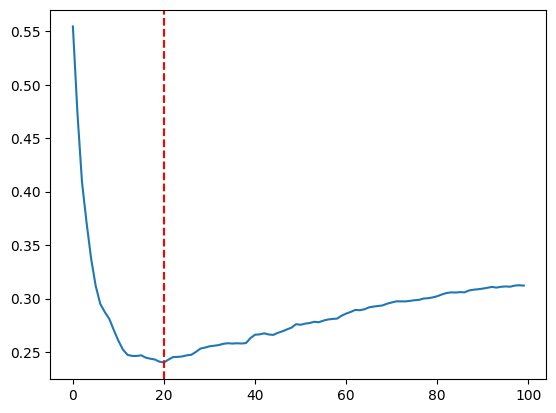


Entire code has runned and stopped running.


In [45]:
# XGBoost
flush()
import pandas as pd
import numpy as np
import torch
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Loading & Cleaning ──────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/Asthma.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"XGBoost runs on    : {str(device).upper()} (Cleaned)")
print(f"{'='*40}")


# ── 3. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

if len(le.classes_) > 2:
    xgb_params = {'objective': 'multi:softprob', 'num_class': len(le.classes_), 'eval_metric': 'mlogloss'}
else:
    xgb_params = {'objective': 'binary:logistic', 'eval_metric': 'logloss'}

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbosity=0,
    **xgb_params
)

xgb_model.fit(X_train_res, y_train_res, eval_set=[(X_train_res, y_train_res), (X_test_s, y_test)], verbose=False)

xgb_results = xgb_model.evals_result()
xgb_test_losses = xgb_results['validation_1'][xgb_params['eval_metric']]
xgb_min_iter = np.argmin(xgb_test_losses)
emissions = tracker.stop()

# ── 4. Metrics & Output ──────────────────────────────────────────────────────
y_pred = xgb_model.predict(X_test_s)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')

metrics_output = f"""
{'='*40}
    XGBoost (Cleaned D6) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision (wt)     : {pr:.4f}
Recall (wt)        : {rc:.4f}
F1 Score (wt)      : {f1:.4f}
Convergence Iter   : {xgb_min_iter + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(xgb_test_losses, label='Test Loss'); plt.axvline(x=xgb_min_iter, color='red', linestyle='--')
plt.show()
s6["XGB"] = [
    acc,
    pr,
    rc,
    f1,
    xgb_min_iter + 1,
    emissions,
    None,
    None,
    None,
    emissions
]
print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
Random Forest runs on: CUDA (Cleaned)

Training Cleaned GPU Random Forest...

    Random Forest (Cleaned D6) – Final Metrics
Accuracy           : 0.4635
Precision (wt)     : 0.9113
Recall (wt)        : 0.4635
F1 Score (wt)      : 0.5895
Convergence Tree   : 50
CO2 Emissions      : 0.000050 kg CO2



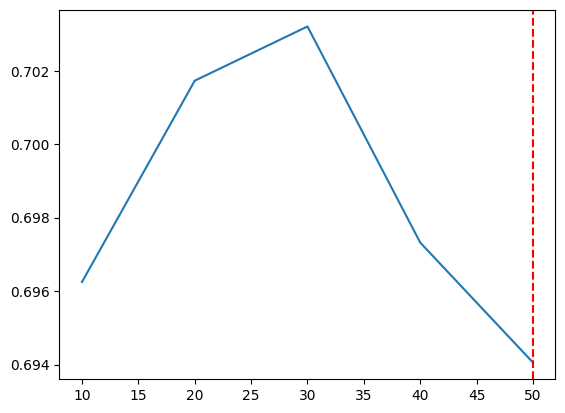


Entire code has runned and stopped running.


In [46]:
# Random Forest
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Loading & Cleaning ──────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/Asthma.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"Random Forest runs on: {str(device).upper()} (Cleaned)")
print(f"{'='*40}")


# ── 4. Soft Decision Tree (GPU-compatible) ────────────────────────────────────
class SoftDecisionTree(nn.Module):
    def __init__(self, n_features, max_depth, n_classes):
        super().__init__()
        self.max_depth, self.n_leaves = max_depth, 2 ** max_depth
        self.n_nodes = 2 ** max_depth - 1
        self.feature_weights = nn.Parameter(torch.randn(self.n_nodes, n_features))
        self.thresholds = nn.Parameter(torch.randn(self.n_nodes))
        self.leaf_logits = nn.Parameter(torch.randn(self.n_leaves, n_classes))

    def forward(self, X):
        batch = X.shape[0]
        feat_attn = torch.softmax(self.feature_weights, dim=1)
        node_vals = X @ feat_attn.T
        split_prob = torch.sigmoid(node_vals - self.thresholds)
        path_probs = torch.ones(batch, self.n_leaves, device=X.device)
        for depth in range(self.max_depth):
            n_nodes_at_depth = 2 ** depth
            start_node = n_nodes_at_depth - 1
            for i in range(n_nodes_at_depth):
                node_idx = start_node + i
                half = self.n_leaves // (2 * n_nodes_at_depth)
                left_idx  = slice(i * (self.n_leaves // n_nodes_at_depth), i * (self.n_leaves // n_nodes_at_depth) + half)
                right_idx = slice(i * (self.n_leaves // n_nodes_at_depth) + half, (i + 1) * (self.n_leaves // n_nodes_at_depth))
                go_right = split_prob[:, node_idx].unsqueeze(1)
                path_probs[:, left_idx] *= (1 - go_right)
                path_probs[:, right_idx] *= go_right
        return path_probs @ torch.softmax(self.leaf_logits, dim=1)

class GPURandomForest:
    def __init__(self, n_estimators=50, max_depth=4, n_classes=4, lr=0.01, epochs=20):
        self.n_estimators, self.max_depth, self.n_classes, self.lr, self.epochs = n_estimators, max_depth, n_classes, lr, epochs
        self.trees, self.feature_subsets = [], []

    def fit(self, X, y):
        X_t, y_t = torch.tensor(X).to(device), torch.tensor(y, dtype=torch.long).to(device)
        n_features = X.shape[1]
        for t in range(self.n_estimators):
            idx = torch.randint(0, X.shape[0], (X.shape[0],), device=device)
            feat_idx = torch.randperm(n_features, device=device)[:int(n_features * 0.8)]
            self.feature_subsets.append(feat_idx)
            tree = SoftDecisionTree(len(feat_idx), self.max_depth, self.n_classes).to(device)
            optimizer = torch.optim.Adam(tree.parameters(), lr=self.lr)
            tree.train()
            for _ in range(self.epochs):
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(tree(X_t[idx][:, feat_idx]), y_t[idx])
                loss.backward(); optimizer.step()
            self.trees.append(tree.eval())

    def predict_proba(self, X):
        X_t = torch.tensor(X).to(device)
        all_probs = []
        with torch.no_grad():
            for tree, feat_idx in zip(self.trees, self.feature_subsets):
                all_probs.append(tree(X_t[:, feat_idx]).cpu().numpy())
        return np.mean(all_probs, axis=0)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

print("\nTraining Cleaned GPU Random Forest...")
rf_model = GPURandomForest(n_estimators=50, max_depth=4, n_classes=n_classes)
rf_model.fit(X_train_res, y_train_res)

te_losses = []
tree_counts = list(range(10, rf_model.n_estimators + 1, 10))
for n in tree_counts:
    probs = []
    with torch.no_grad():
        for tree, f_idx in zip(rf_model.trees[:n], rf_model.feature_subsets[:n]):
            probs.append(tree(torch.tensor(X_test_s).to(device)[:, f_idx]).cpu().numpy())
    te_losses.append(log_loss(y_test, np.mean(probs, axis=0)))

rf_min_tree = tree_counts[np.argmin(te_losses)]
emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
probs = rf_model.predict_proba(X_test_s)
y_pred = np.argmax(probs, axis=1)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')

metrics_output = f"""
{'='*40}
    Random Forest (Cleaned D6) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision (wt)     : {pr:.4f}
Recall (wt)        : {rc:.4f}
F1 Score (wt)      : {f1:.4f}
Convergence Tree   : {rf_min_tree}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(tree_counts, te_losses, label='Test Loss'); plt.axvline(x=rf_min_tree, color='red', linestyle='--')
plt.show()
s6["RF"] = [
    acc,
    pr,
    rc,
    f1,
    rf_min_tree,
    emissions,
    None,
    None,
    None,
    emissions
]
print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
MLP runs on        : CUDA (Cleaned)

    MLP (Cleaned D6) – Final Metrics
Accuracy           : 0.7829
Precision (wt)     : 0.9075
Recall (wt)        : 0.7829
F1 Score (wt)      : 0.8367
Best Epoch         : 1
CO2 Emissions      : 0.000003 kg CO2



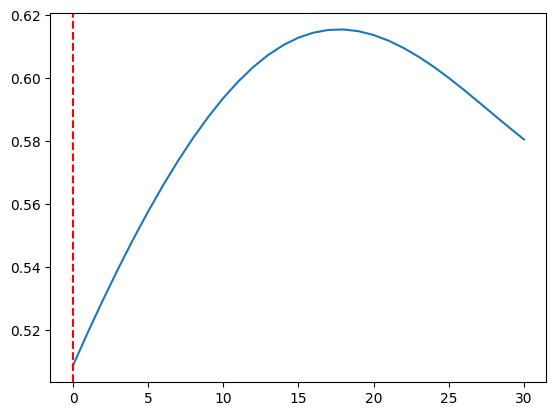


Entire code has runned and stopped running.


In [47]:
# MLP Classifier
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Loading & Cleaning ──────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/Asthma.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"MLP runs on        : {str(device).upper()} (Cleaned)")
print(f"{'='*40}")


X_train_t = torch.tensor(X_train_res).to(device)
X_val_t   = torch.tensor(X_val_s).to(device)
X_test_t  = torch.tensor(X_test_s).to(device)
y_train_t = torch.tensor(y_train_res, dtype=torch.long).to(device)
y_val_t   = torch.tensor(y_val, dtype=torch.long).to(device)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, n_classes))
    def forward(self, x): return self.net(x)

model = MLP(X_train_t.shape[1], n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

val_losses = []
best_loss, best_epoch, patience, counter, best_state = float('inf'), 0, 30, 0, None

for epoch in range(500):
    model.train(); optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        v_loss = criterion(model(X_val_t), y_val_t).item()
    val_losses.append(v_loss)

    if v_loss < best_loss - 1e-4:
        best_loss, best_epoch, counter, best_state = v_loss, epoch, 0, model.state_dict()
    else:
        counter += 1
    if counter >= patience: break

if best_state: model.load_state_dict(best_state)
emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_test_t), dim=1).cpu().numpy()
y_pred = np.argmax(probs, axis=1)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')

metrics_output = f"""
{'='*40}
    MLP (Cleaned D6) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision (wt)     : {pr:.4f}
Recall (wt)        : {rc:.4f}
F1 Score (wt)      : {f1:.4f}
Best Epoch         : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(val_losses, label="Val Loss"); plt.axvline(best_epoch, color="red", linestyle="--")
plt.show()
s6["MLP"] = [
    acc,
    pr,
    rc,
    f1,
    best_epoch + 1,
    emissions,
    None,
    None,
    None,
    emissions
]
print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
LogReg runs on     : CUDA (Cleaned)

    Logistic Regression (Cleaned D6) – Final Metrics
Accuracy           : 0.6326
Precision (wt)     : 0.9203
Recall (wt)        : 0.6326
F1 Score (wt)      : 0.7336
Convergence Epoch  : 47
CO2 Emissions      : 0.000014 kg CO2



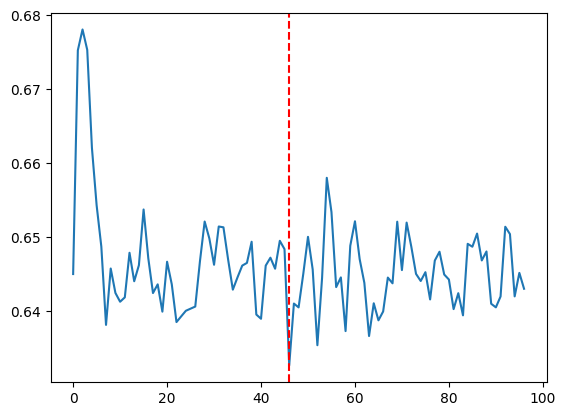


Entire code has runned and stopped running.


In [48]:
# Logistic Regression
flush()
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Loading & Cleaning ──────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/Asthma.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"LogReg runs on     : {str(device).upper()} (Cleaned)")
print(f"{'='*40}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_t, X_test_t, y_train_t = torch.tensor(X_train_res).to(device), torch.tensor(X_test_s).to(device), torch.tensor(y_train_res, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# ── 4. Model ─────────────────────────────────────────────────────────────────
class LogisticRegression(nn.Module):
    def __init__(self, dim, n_classes):
        super().__init__()
        self.linear = nn.Linear(dim, n_classes)
    def forward(self, x): return self.linear(x)

model = LogisticRegression(X_train_t.shape[1], n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

test_losses = []
best_loss, best_epoch, patience, counter, best_state = float('inf'), 0, 50, 0, None

for epoch in range(500):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad(); loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        te_l = criterion(model(X_test_t), torch.tensor(y_test, dtype=torch.long).to(device)).item()
    test_losses.append(te_l)

    if te_l < best_loss - 1e-5:
        best_loss, best_epoch, counter, best_state = te_l, epoch, 0, model.state_dict()
    else:
        counter += 1
    if counter >= patience: break

if best_state: model.load_state_dict(best_state)
emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_test_t), dim=1).cpu().numpy()
y_pred = np.argmax(probs, axis=1)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')

metrics_output = f"""
{'='*40}
    Logistic Regression (Cleaned D6) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision (wt)     : {pr:.4f}
Recall (wt)        : {rc:.4f}
F1 Score (wt)      : {f1:.4f}
Convergence Epoch  : {best_epoch + 1}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(test_losses, label="Test Loss"); plt.axvline(best_epoch, color="red", linestyle="--")
plt.show()
s6["LR"] = [
    acc,
    pr,
    rc,
    f1,
    best_epoch + 1,
    emissions,
    None,
    None,
    None,
    emissions
]
print("\nEntire code has runned and stopped running.")


         GPU Status
GPU Available      : Yes
GPU Name           : NVIDIA GeForce RTX 4060
GPU Memory (GB)    : 8.59
KNN runs on        : CUDA (Cleaned)

    KNN (Cleaned D6) – Final Metrics
Accuracy           : 0.9478
Precision (wt)     : 0.8983
Recall (wt)        : 0.9478
F1 Score (wt)      : 0.9224
Best k             : 7
CO2 Emissions      : 0.000003 kg CO2



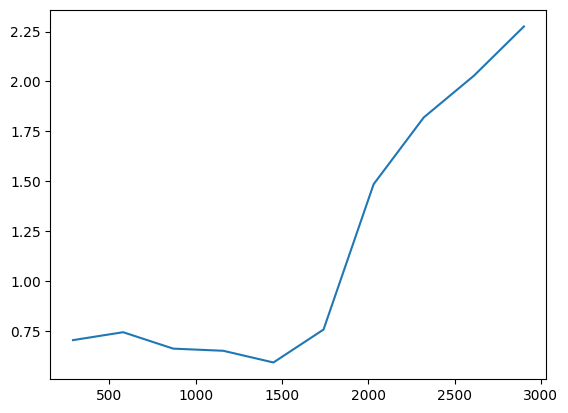


Entire code has runned and stopped running.


In [49]:
# Kth Nearest Neighbour
flush()
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ── 1. Advanced Data Loading & Cleaning ──────────────────────────────────────
url = 'https://raw.githubusercontent.com/mazidzomader/CSE427-Project-BRACU/refs/heads/main/Datasets/Asthma.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

# ── 2. Scaling & SMOTE ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_s, y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 3. GPU Status ─────────────────────────────────────────────────────────────
print(f"{'='*40}")
print(f"         GPU Status")
print(f"{'='*40}")
if torch.cuda.is_available():
    print(f"GPU Available      : Yes")
    print(f"GPU Name           : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f}")
else:
    print(f"GPU Available      : No — using CPU")
print(f"KNN runs on        : {str(device).upper()} (Cleaned)")
print(f"{'='*40}")


# ── 4. Pure PyTorch GPU KNN ──────────────────────────────────────────────────
def torch_knn_predict_proba(X_tr, y_tr, X_te, k, n_classes, batch_size=512):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_te, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=device)
    n_test = X_te_t.shape[0]
    proba = torch.zeros(n_test, n_classes, device=device)
    for start in range(0, n_test, batch_size):
        end = min(start + batch_size, n_test)
        dists = torch.cdist(X_te_t[start:end], X_tr_t, p=2)
        _, indices = torch.topk(dists, k, dim=1, largest=False)
        neighbor_labels = y_tr_t[indices]
        for c in range(n_classes):
            proba[start:end, c] = (neighbor_labels == c).float().mean(dim=1)
    return proba.cpu().numpy()

# ── 5. Training ──────────────────────────────────────────────────────────────
tracker = OfflineEmissionsTracker(country_iso_code="BGD", log_level="error")
tracker.start()

best_k = 7
knn_sizes = np.linspace(0.1, 1.0, 10)
te_losses = []

for s in knn_sizes:
    n = int(len(X_train_res) * s)
    X_p, y_p = X_train_res[:n], y_train_res[:n]
    p = torch_knn_predict_proba(X_p, y_p, X_test_s, best_k, n_classes)
    te_losses.append(log_loss(y_test, p))

emissions = tracker.stop()

# ── 6. Metrics & Output ──────────────────────────────────────────────────────
probs = torch_knn_predict_proba(X_train_s, y_train, X_test_s, best_k, n_classes)
y_pred = np.argmax(probs, axis=1)
acc, pr, rc, f1 = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted')

metrics_output = f"""
{'='*40}
    KNN (Cleaned D6) – Final Metrics
{'='*40}
Accuracy           : {acc:.4f}
Precision (wt)     : {pr:.4f}
Recall (wt)        : {rc:.4f}
F1 Score (wt)      : {f1:.4f}
Best k             : {best_k}
CO2 Emissions      : {emissions:.6f} kg CO2
{'='*40}
"""
print(metrics_output)
plt.figure(); plt.plot(knn_sizes * len(X_train_res), te_losses, label='Test Loss')
plt.show()
s6["KNN"] = [
    acc,
    pr,
    rc,
    f1,
    best_k,
    emissions,
    None,
    None,
    None,
    emissions
]
print("\nEntire code has runned and stopped running.")


In [50]:
for key, val in s6.items():
    print(f"{key}: {val}")

ADA: [0.8789144050104384, 0.9103993500434062, 0.8789144050104384, 0.8937159785684817, np.int64(32), 1.3012355842307148e-05, None, None, None, 1.3012355842307148e-05]
XGB: [0.9457202505219207, 0.8982363885710293, 0.9457202505219207, 0.9213669393496823, np.int64(21), 4.843946713346521e-06, None, None, None, 4.843946713346521e-06]
RF: [0.46346555323590816, 0.9112954078337386, 0.46346555323590816, 0.5894813968880946, 50, 5.01208826823998e-05, None, None, None, 5.01208826823998e-05]
MLP: [0.7828810020876826, 0.9075380709272421, 0.7828810020876826, 0.8366525634350552, 1, 3.4242092081828966e-06, None, None, None, 3.4242092081828966e-06]
LR: [0.6325678496868476, 0.9203276072558682, 0.6325678496868476, 0.7335813310022817, 47, 1.351334265486748e-05, None, None, None, 1.351334265486748e-05]
KNN: [0.9478079331941545, 0.8983398782257748, 0.9478079331941545, 0.9224111504183197, 7, 3.387249549385172e-06, None, None, None, 3.387249549385172e-06]



               MODEL COMPARISON TABLE (DATASET 6)
Model Accuracy Precision  Recall F1 Score  Convergence  CO2 (kg)
  ADA  87.891%   91.040% 87.891%  89.372%           32  0.000013
  XGB  94.572%   89.824% 94.572%  92.137%           21  0.000005
   RF  46.347%   91.130% 46.347%  58.948%           50  0.000050
  MLP  78.288%   90.754% 78.288%  83.665%            1  0.000003
   LR  63.257%   92.033% 63.257%  73.358%           47  0.000014
  KNN  94.781%   89.834% 94.781%  92.241%            7  0.000003

           CONVERGENCE EFFICIENCY SCORE (CES)
Model Metric Used    Score  CO2 (kg)       CES
  KNN    F1 Score 0.922411  0.000003 11.618225
  XGB    F1 Score 0.921367  0.000005 11.275491
  MLP    F1 Score 0.836653  0.000003 10.528974
  ADA    F1 Score 0.893716  0.000013 10.053969
   LR    F1 Score 0.733581  0.000014  8.224801
   RF    F1 Score 0.589481  0.000050  5.836528


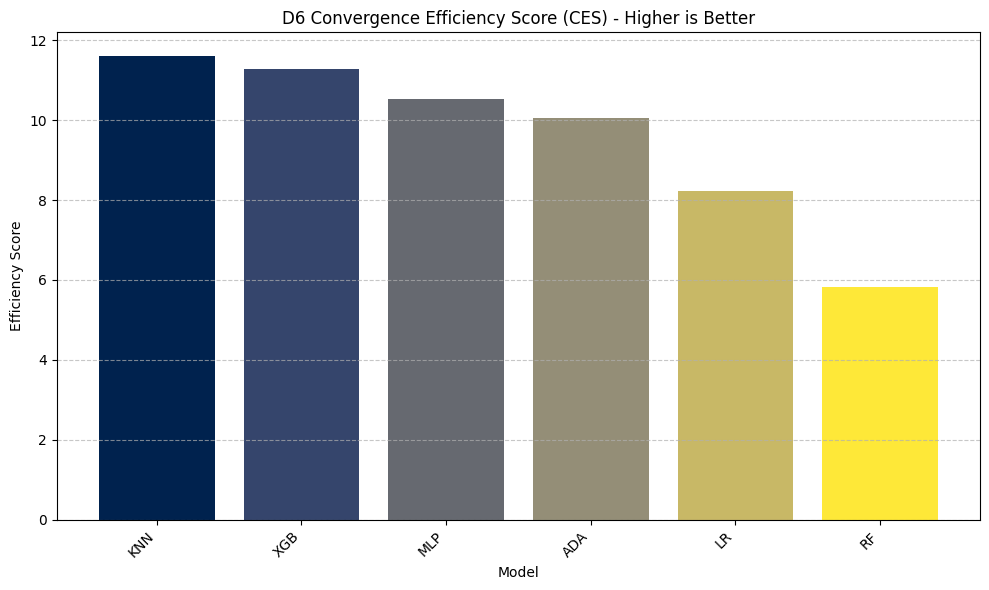


Aggregation process completed.


In [51]:
# Dataset Summary and CES score
flush()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# s6 already exists
# Format:
# [acc, pr, rc, f1, best_k, emissions, co2, ch4, n2o, emissions]

# ── Build Summary ────────────────────────────────────────────────────────────
summary_data = []

for model, values in s6.items():
    acc, pr, rc, f1, conv, emissions, x, y, z, co2 = values

    summary_data.append({
        "Model": model,
        "Accuracy": f"{acc*100:.3f}%",
        "Precision": f"{pr*100:.3f}%",
        "Recall": f"{rc*100:.3f}%",
        "F1 Score": f"{f1*100:.3f}%",
        "F1_raw": f1,
        "Convergence": int(conv),
        "CO2 (kg)": co2
    })

df_summary = pd.DataFrame(summary_data)

# ── CES Calculation ─────────────────────────────────────────────────────────
def compute_ces(score, co2):
    if co2 is None or co2 == 0 or np.isnan(co2):
        return 0.0
    return score * np.log1p(1 / (co2 + 1e-12))

ces_data = []

for item in summary_data:
    f1 = item["F1_raw"]
    co2 = item["CO2 (kg)"]

    ces = compute_ces(f1, co2) if f1 is not None else 0.0

    ces_data.append({
        "Model": item["Model"],
        "Metric Used": "F1 Score",
        "Score": f1,
        "CO2 (kg)": co2,
        "CES": ces
    })

df_ces = pd.DataFrame(ces_data)
df_ces_sorted = df_ces.sort_values(by="CES", ascending=False)

# ── Display Results ──────────────────────────────────────────────────────────
print("\n" + "="*80)
print("               MODEL COMPARISON TABLE (DATASET 6)")
print("="*80)
print(df_summary.drop(columns=["F1_raw"]).to_string(index=False))

print("\n" + "="*80)
print("           CONVERGENCE EFFICIENCY SCORE (CES)")
print("="*80)
print(df_ces_sorted.to_string(index=False))

# ── Visualization ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
colors = plt.cm.cividis(np.linspace(0, 1, len(df_ces_sorted)))
plt.bar(df_ces_sorted["Model"], df_ces_sorted["CES"], color=colors)

plt.xticks(rotation=45, ha="right")
plt.title("D6 Convergence Efficiency Score (CES) - Higher is Better")
plt.ylabel("Efficiency Score")
plt.xlabel("Model")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
ces_dict["D6"] = ces_data
print("\nAggregation process completed.")

# Overall Summary

In [52]:
def print_ces_dict(d):
    for dataset, models in d.items():
        print(f"\n{'='*55}")
        print(f"  Dataset: {dataset}")
        print(f"{'='*55}")
        print(f"  {'Model':<8} {'Score':>10} {'CO2 (kg)':>14} {'CES':>10}")
        print(f"  {'-'*47}")
        for m in models:
            print(f"  {m['Model']:<8} {m['Score']:>10.4f} {m.get('CO2 (kg)', m.get('CO2', 0)):>14.2e} {m['CES']:>10.4f}")
    print(f"\n{'='*55}\n")

print_ces_dict(ces_dict)


  Dataset: D1
  Model         Score       CO2 (kg)        CES
  -----------------------------------------------
  Ada          0.9600       1.17e-05    10.8999
  XGB          0.9600       3.76e-06    11.9908
  RF           0.9495       2.09e-04     8.0438
  MLP          0.9600       1.51e-05    10.6594
  LR           0.9600       3.79e-05     9.7742
  KNN          0.9600       3.00e-06    12.2090

  Dataset: D2
  Model         Score       CO2 (kg)        CES
  -----------------------------------------------
  ADA          0.8911       6.08e-06    10.7030
  XGB          0.8911       3.57e-06    11.1781
  RF           0.8878       2.06e-04     7.5334
  MLP          0.8804       4.96e-06    10.7523
  LR           0.9082       2.19e-05     9.7450
  KNN          0.9360       2.96e-06    11.9144

  Dataset: D3
  Model         Score       CO2 (kg)        CES
  -----------------------------------------------
  ADA          0.9032       9.14e-06    10.4798
  XGB          0.9091       1.08e-05 

# Stability Benchmark

In [53]:
import pandas as pd
import numpy as np

# ── STEP 1: Normalize model names (important) ────────────────────────────────
def normalize_name(name):
    return name.strip().upper()

# ── STEP 2: Collect CES values per model ─────────────────────────────────────
model_ces = {}

for dataset, records in ces_dict.items():
    for entry in records:
        model = normalize_name(entry["Model"])
        ces = float(entry["CES"])

        if model not in model_ces:
            model_ces[model] = []

        model_ces[model].append(ces)

# ── STEP 3: Compute statistics ───────────────────────────────────────────────
summary = []

for model, ces_values in model_ces.items():
    ces_array = np.array(ces_values)

    mean_ces = np.mean(ces_array)
    std_ces  = np.std(ces_array)

    # Stability = mean / std (avoid division by zero)
    stability = mean_ces / (std_ces + 1e-12)

    summary.append({
        "Model": model,
        "Mean CES": mean_ces,
        "Std CES": std_ces,
        "Stability": stability
    })

# ── STEP 4: Convert to DataFrame ─────────────────────────────────────────────
df_summary = pd.DataFrame(summary)

# ── STEP 5: Sort by stability ────────────────────────────────────────────────
df_sorted = df_summary.sort_values(by="Stability", ascending=False)

# ── STEP 6: Pretty print ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("              STABILITY ANALYSIS (CES)")
print("="*60)
print(df_sorted.to_string(index=False, float_format="%.4f"))
print("="*60)


              STABILITY ANALYSIS (CES)
Model  Mean CES  Std CES  Stability
  XGB   10.7529   1.0889     9.8746
  MLP    9.4684   1.2224     7.7457
  ADA    9.6795   1.2558     7.7077
  KNN   10.8020   1.4213     7.6003
   RF    6.9186   0.9902     6.9870
   LR    8.2320   1.8592     4.4278


# Win Count

In [54]:
import pandas as pd

# ── Normalize model names ───────────────────────────────────────────────
def normalize_name(name):
    return name.strip().upper()

# ── Step 0: Get ALL models ──────────────────────────────────────────────
all_models = set()

for records in ces_dict.values():
    for entry in records:
        all_models.add(normalize_name(entry["Model"]))

# ── Initialize win counter with 0 ───────────────────────────────────────
win_count = {model: 0 for model in all_models}

# ── Loop through each dataset ───────────────────────────────────────────
for dataset, records in ces_dict.items():

    best_ces = -float("inf")
    best_models = []

    # Find best CES (with tie handling)
    for entry in records:
        model = normalize_name(entry["Model"])
        ces = float(entry["CES"])

        if ces > best_ces:
            best_ces = ces
            best_models = [model]

        elif ces == best_ces:
            best_models.append(model)

    # ── Distribute wins ────────────────────────────────────────────────
    share = 1 / len(best_models)

    for model in best_models:
        win_count[model] += share

# ── Convert to DataFrame ────────────────────────────────────────────────
df_wins = pd.DataFrame([
    {"Model": model, "Win Count": count}
    for model, count in win_count.items()
])

# ── Sort descending ─────────────────────────────────────────────────────
df_wins = df_wins.sort_values(by="Win Count", ascending=False)

# ── Print result ────────────────────────────────────────────────────────
print("\n" + "="*50)
print("     MODEL WIN COUNT (ALL MODELS INCLUDED)")
print("="*50)
print(df_wins.to_string(index=False, float_format="%.2f"))
print("="*50)


     MODEL WIN COUNT (ALL MODELS INCLUDED)
Model  Win Count
  KNN       5.00
  XGB       1.00
   LR       0.00
   RF       0.00
  ADA       0.00
  MLP       0.00


# Final Leaderboard

In [57]:
import numpy as np
import pandas as pd

# ── Normalize model names ───────────────────────────────────────────────
def normalize_name(name):
    return name.strip().upper()

# ── STEP 1: Initialize win count ────────────────────────────────────────
win_count = {normalize_name(item["Model"]): 0 for item in summary}

# ── STEP 2: Compute win count (with ties) ───────────────────────────────
for dataset, records in ces_dict.items():
    best_ces = -float("inf")
    best_models = []

    for entry in records:
        model = normalize_name(entry["Model"])
        ces   = float(entry["CES"])

        if ces > best_ces:
            best_ces = ces
            best_models = [model]
        elif ces == best_ces:
            best_models.append(model)

    share = 1 / len(best_models)
    for model in best_models:
        win_count[model] += share

# ── STEP 3: Extract arrays for normalization ─────────────────────────────
mean_vals = np.array([item["Mean CES"]  for item in summary], dtype=float)
stab_vals = np.array([item["Stability"] for item in summary], dtype=float)
win_vals  = np.array([win_count[normalize_name(item["Model"])] for item in summary], dtype=float)

# ── MinMax normalization ─────────────────────────────────────────────────
def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

mean_norm = minmax(mean_vals)
stab_norm = minmax(stab_vals)
win_norm  = minmax(win_vals)

# ── STEP 4: Compute final score ─────────────────────────────────────────
results = []
for i, item in enumerate(summary):
    final_score = (
        0.6 * mean_norm[i] +
        0.3 * stab_norm[i] +
        0.1 * win_norm[i]
    )
    results.append({
        "Model":       item["Model"],
        "Mean CES":    item["Mean CES"],
        "Stability":   item["Stability"],
        "Win Count":   win_vals[i],
        "Final Score": final_score*10
    })

# ── STEP 5: Build & sort DataFrame ──────────────────────────────────────
df = pd.DataFrame(results).sort_values("Final Score", ascending=False).reset_index(drop=True)
df.index += 1  # Rank starts at 1

# ── STEP 6: Format columns ───────────────────────────────────────────────
df["Mean CES"]    = df["Mean CES"].map("{:.4f}".format)
df["Stability"]   = df["Stability"].map("{:.4f}".format)
df["Win Count"]   = df["Win Count"].map("{:.2f}".format)
df["Final Score"] = df["Final Score"].map("{:.4f}".format)
df.index.name = "Rank"

# ── STEP 7: Pretty print ────────────────────────────────────────────────
print("\n" + "═" * 58)
print("             FINAL MODEL RANKING")
print("═" * 58)
print(df.to_string())
print("═" * 58)
print("Weights → Mean CES: 60%  |  Stability: 30%  |  Wins: 10%")
print("Final Score is counted out of 10")
print("═" * 58)


══════════════════════════════════════════════════════════
             FINAL MODEL RANKING
══════════════════════════════════════════════════════════
     Model Mean CES Stability Win Count Final Score
Rank                                               
1      XGB  10.7529    9.8746      1.00      9.1242
2      KNN  10.8020    7.6003      5.00      8.7473
3      ADA   9.6795    7.7077      0.00      6.0723
4      MLP   9.4684    7.7457      0.00      5.7669
5       LR   8.2320    4.4278      0.00      2.0293
6       RF   6.9186    6.9870      0.00      1.4095
══════════════════════════════════════════════════════════
Weights → Mean CES: 60%  |  Stability: 30%  |  Wins: 10%
Final Score is counted out of 10
══════════════════════════════════════════════════════════
